# DysCalc ML Component Pre-Processing, Training, and Evaluation

Using FUNA-DB Dataset and C4.5 Decision Tree Algorithm

## Global Imports, Configs, and Setups

### Imports

In [ ]:
import os, warnings, random, json, sys
from pathlib import Path
import pandas as pd
import numpy as np
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from itertools import product
from typing import Dict, List, Optional
from joblib import Parallel, delayed

import scipy.stats as stats
from scipy.stats import gaussian_kde, pearsonr
from scipy.spatial.distance import jensenshannon

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import fbeta_score, f1_score, recall_score, precision_score, accuracy_score, roc_auc_score, mean_squared_error

from sdv.single_table import CopulaGANSynthesizer, CTGANSynthesizer
from sdv.metadata import SingleTableMetadata

sys.path.append(str(Path().resolve().parent))
from src.C45DecisionTree import C45DecisionTree

### Configs

In [ ]:
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.labelsize'] = 10

AT_RIST_COLOR = '#ED7D31'
TYPICAL_COLOR = '#5B9BD5'
REAL_COLOR = '#54A24B'
SYNTHETIC_COLOR = '#E45756'

EPSILON = 1e-9
SEED = 42
NUMBER_PROCESSING = ['NC', 'DM']
ARITHMETIC_FLUENCY = ['NS', 'ADD', 'SUB', 'CA']
FEATURE_COLUMNS = NUMBER_PROCESSING + ARITHMETIC_FLUENCY
DERIVED_FEATURES = ['NP', 'SN', 'AF', 'BC', 'AS', 'PF']

FUNA_DB_DOMAIN_MAPPING: Dict[str, str] = {
    "NC":  "Number Comparison",
    "DM":  "Digit-Dot Matching",
    "NP":  "Overall Processing Efficiency",
    "SN":  "Symbolic vs. Non-Symbolic Processing Difference",
    "NS":  "Number Series",
    "ADD": "Single-Digit Addition",
    "SUB": "Single-Digit Subtraction",
    "CA":  "Multi-Digit Addition and Subtraction",
    "AF":  "Overall Arithmetic Fluency",
    "BC":  "Basic vs. Complex Arithmetic Contrast",
    "AS":  "Addition vs. Subtraction Asymmetry",
    "PF":  "Processing-Fluency Integration",
}

### Paths

In [77]:
ROOT_DIR = Path().resolve().parent
DATASET_DIR = ROOT_DIR / "datasets"
RAW_DATASET_DIR = DATASET_DIR / "raw"
PROCESSED_DATASET_DIR = DATASET_DIR / "processed"
OUTPUTS_DIR = ROOT_DIR / "outputs"
FIGURES_OUTPUTS = OUTPUTS_DIR / "dataset_analysis_figures"
LOGS_OUTPUTS = OUTPUTS_DIR / "logs_and_metrics"
GRIDSEARCH_OUTPUTS = OUTPUTS_DIR / "grid_search"
GAN_FIGURES = OUTPUTS_DIR / "gan_figures"

os.makedirs(DATASET_DIR, exist_ok=True)
os.makedirs(RAW_DATASET_DIR, exist_ok=True)
os.makedirs(PROCESSED_DATASET_DIR, exist_ok=True)
os.makedirs(OUTPUTS_DIR, exist_ok=True)
os.makedirs(FIGURES_OUTPUTS, exist_ok=True)
os.makedirs(LOGS_OUTPUTS, exist_ok=True)
os.makedirs(GAN_FIGURES, exist_ok=True)

## 1.0 Label Construction, Data Preprocessing, and Feature Engineering


### 1.1 Dataset Labeling

This section covers the labeling of the dataset using standardized Räsänen Basic Arithmetic Test (RMAT) screening test and clinical threshold, EDA, and data cleaning. For labeling using RMAT scores, students with below the 35th percentile score are labeled as *1* (At-Risk) (Mononen et al., 2022) for supervised learning.

In [78]:
RAW_DATASET = RAW_DATASET_DIR / "FUNADB_rawdata_SUPPL.csv"
LABELED_DATASET = DATASET_DIR / "processed" / "FUNADB_labled.csv"
KEEP_COLUMNS = ["NC_t1", "DM_t1", "NS_t1", "ADD_t1", "SUB_t1", "CA_t1", "RMAT"]

# Read and Drop Unusable Columns
df_unl = pd.read_csv(RAW_DATASET, index_col=False)
df_unl = df_unl[KEEP_COLUMNS]
df_unl = df_unl.rename(columns=lambda c: c.removesuffix("_t1") if c != "RMAT" else c)   # remove the _t1 in the column names

# Label with 1 ("At-Risk") or 0 ("Typical") based on RMAT score
RMAT_scores = df_unl['RMAT'].to_numpy()

# Compute population mean and std for RMAT scores
RMAT_mean = np.mean(RMAT_scores)
RMAT_std = np.std(RMAT_scores)

# Normalize scores
RMAT_normalized = []
for score in RMAT_scores:
    RMAT_normalized.append((score - RMAT_mean) / RMAT_std)

# Labeling, with 35th percentile as threshold
RMAT_labels = []
threshold = np.percentile(RMAT_normalized, 35)
for normalized in RMAT_normalized:
    RMAT_labels.append(1 if normalized <= threshold else 0)

# Add the "Label" to the dataframe then drop RMAT since it will not be used 
df_unl['Label'] = np.array(RMAT_labels)
df_l = df_unl.drop(columns=['RMAT'])

df_l.to_csv(LABELED_DATASET, index=False)

df_l.head(10)

,NC,DM,NS,ADD,SUB,CA,Label
0,1248.000000,2903.384615,5,23,17,8,1
1,921.142857,2212.000000,21,48,22,29,0
2,902.720000,1943.846154,14,28,26,18,1
3,1334.297872,3707.268293,9,17,10,-99,1
4,1274.509804,2384.918919,16,34,37,16,0
5,1150.500000,2817.073171,12,33,24,14,0
6,637.795918,1583.076923,21,48,43,26,0
7,1565.098039,2482.097561,14,23,28,15,0
8,1793.480000,3539.000000,10,14,31,20,0
9,1251.058824,2636.780488,16,42,33,23,0


### 1.2 Initial Exploratory Dataset Analysis

#### Feature Reference Guide (FUNA-DB)
Based on Räsänen et al. (2021) and Hakkarainen et al. (2025).

| Column | Full Name | Factor | Score Type | Direction |
|--------|-----------|--------|------------|-----------|
| NC | Number Comparison | Number Processing | Efficiency index (RT ÷ accuracy) | **Higher = worse** (slower/less accurate) |
| DM | Digit-Dot Matching | Number Processing | Efficiency index (RT ÷ accuracy) | **Higher = worse** (slower/less accurate) |
| NS | Number Series | Arithmetic Fluency | # correct items (3 min) | Higher = better |
| ADD | Single-Digit Addition | Arithmetic Fluency | # correct items (2 min) | Higher = better |
| SUB | Single-Digit Subtraction | Arithmetic Fluency | # correct items (2 min) | Higher = better |
| CA | Multi-Digit Calculations | Arithmetic Fluency | # correct items (3 min) | Higher = better |

**Important notes for interpretation:**
- NC and DM are efficiency scores — a student with dyscalculia will score *higher* on these (slow + inaccurate)
- NS, ADD, SUB, CA are speed-accuracy counts — a student with dyscalculia will score *lower* on these
- This means NC/DM correlate *negatively* with ADD/SUB/CA — this is **expected and correct**, not a data error
- NC and DM are **not inverted** here because C4.5 Decision Tree is direction-agnostic — it will learn the correct split thresholds regardless
- The two-factor structure (Number Processing vs Arithmetic Fluency) is validated across 18,405 students (Hellstrand et al., 2024)
- Missing values for students or scores would be -99

##### 1.2.1 EDA Helper and Generator Functions

In [79]:
def add_class_specific_corr(g, df, features, class_col="Class"):
    """
    Adds class-specific Pearson r values to the lower triangle of a seaborn pairplot.
    """

    for i, y_var in enumerate(features):
        for j, x_var in enumerate(features):

            # Only annotate lower triangle
            if i > j:
                ax = g.axes[i, j]

                lines = []

                for class_name, group_df in df.groupby(class_col):
                    x = group_df[x_var]
                    y = group_df[y_var]

                    valid = x.notna() & y.notna()
                    x_valid = x[valid]
                    y_valid = y[valid]

                    if len(x_valid) > 2:
                        r, p = pearsonr(x_valid, y_valid)
                        lines.append(f"{class_name}: r = {r:.2f}")
                    else:
                        lines.append(f"{class_name}: r = NA")

                ax.annotate(
                    "\n".join(lines),
                    xy=(0.05, 0.95),
                    xycoords="axes fraction",
                    ha="left",
                    va="top",
                    fontsize=6.5,
                    fontweight="bold",
                    bbox=dict(
                        boxstyle="round,pad=0.25",
                        facecolor="white",
                        edgecolor="gray",
                        alpha=0.75
                    )
                )

def show_label_distribution_plot(df, df_type: str):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    counts = df['Label'].value_counts().sort_index()
    labels = ['Class 0 (Typical)', 'Class 1 (At-Risk)']
    colors = [TYPICAL_COLOR, AT_RIST_COLOR]

    axes[0].bar(labels, counts.values, color=colors, edgecolor='white', width=0.5)
    axes[0].set_ylabel('Count')
    axes[0].set_title('Count per Class')
    for i, v in enumerate(counts.values):
        axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold')

    axes[1].pie(counts.values, labels=labels, colors=colors, autopct='%1.1f%%',
                startangle=90, wedgeprops=dict(edgecolor='white'))
    axes[1].set_title('Class Proportions')

    plt.tight_layout()
    plt.savefig(FIGURES_OUTPUTS / f'label_distribution_{df_type}.png')
    plt.show()

def show_feature_distribution_plot(df, df_type: str, feature_columns: list, missing_values: list):
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    axes = axes.flatten()

    for i, col in enumerate(feature_columns):
        ax = axes[i]

        for label, color in zip([0, 1], [TYPICAL_COLOR, AT_RIST_COLOR]):
            data = df[df['Label'] == label][col]

            # Histogram
            ax.hist(
                data, bins=25, alpha=0.5, color=color,
                label=f'Class {label} ({["Typical","At-Risk"][label]})',
                edgecolor='white', density=True
            )

            # ---- KDE trend (EXCLUDE sentinel values) ----
            data_no_sentinel = data[~data.isin(missing_values)].dropna()

            if len(data_no_sentinel) > 1:
                kde = gaussian_kde(data_no_sentinel)
                x_vals = np.linspace(data_no_sentinel.min(), data_no_sentinel.max(), 200)
                y_vals = kde(x_vals)
                ax.plot(x_vals, y_vals, color=color, linewidth=2)

        # ---- Sentinel annotation + vertical line ----
        for idx, sentinel in enumerate(missing_values):
            n_sentinel = (df[col] == sentinel).sum()
            
            if n_sentinel > 0:
                ax.axvline(sentinel, linestyle='--', linewidth=1.5)
                
                # Shift the text box down slightly if there are multiple sentinel types
                y_pos = 0.92 - (idx * 0.15)
                
                ax.annotate(
                    f'{sentinel} sentinel\n(n={n_sentinel})',
                    xy=(0.02, y_pos),
                    xycoords='axes fraction',
                    fontsize=8,
                    bbox=dict(boxstyle='round,pad=0.2', alpha=0.8)
                )

        ax.set_title(col)
        ax.set_xlabel('Value')
        ax.set_ylabel('Density')  
        ax.legend(fontsize=8)

    plt.tight_layout()
    plt.savefig(FIGURES_OUTPUTS / f'feature_distribution_{df_type}.png')
    plt.show()

def show_feature_class_outliers(df, df_type: str, feature_columns: list):
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    axes = axes.flatten()

    for i, col in enumerate(feature_columns):
        ax = axes[i]
        data_to_plot = [df[df['Label'] == lbl][col].dropna() for lbl in [0, 1]]
        bp = ax.boxplot(data_to_plot, patch_artist=True, notch=False,
                        medianprops=dict(color='black', linewidth=2))
        for patch, color in zip(bp['boxes'], [TYPICAL_COLOR, AT_RIST_COLOR]):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        ax.set_xticklabels(['Class 0', 'Class 1'])
        ax.set_title(col)
        ax.set_ylabel('Value')

    plt.tight_layout()
    plt.savefig(FIGURES_OUTPUTS / f'boxplots_{df_type}.png')
    plt.show()

def show_correlation_matrix(df, df_type: str, number_processing: list, arithmetic_fluency: list):
    # Correlation
    corr_raw = df[number_processing + arithmetic_fluency].corr()

    fig, ax = plt.subplots(figsize=(9, 7))

    mask = np.triu(np.ones_like(corr_raw, dtype=bool))

    sns.heatmap(corr_raw, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
        center=0, linewidths=0.5, ax=ax, annot_kws={'size': 9})

    # --- Dynamic mapping ---
    col_index = {col: i for i, col in enumerate(corr_raw.columns)}

    # Number Processing
    np_idx = [col_index[c] for c in number_processing if c in col_index]
    if np_idx:
        np_min, np_max = min(np_idx), max(np_idx)
        ax.add_patch(plt.Rectangle(
            (np_min, np_min),
            np_max - np_min + 1,
            np_max - np_min + 1,
            fill=False,
            edgecolor='#2E75B6',
            lw=2.5
        ))
        ax.text(np_min + 0.3, np_min + 0.5, 'Number Processing',
                fontsize=8, color='#2E75B6', fontweight='bold')

    # Arithmetic Fluency
    af_idx = [col_index[c] for c in arithmetic_fluency if c in col_index]
    if af_idx:
        af_min, af_max = min(af_idx), max(af_idx)
        ax.add_patch(plt.Rectangle(
            (af_min, af_min),
            af_max - af_min + 1,
            af_max - af_min + 1,
            fill=False,
            edgecolor='#70AD47',
            lw=2.5
        ))
        ax.text(af_min + 0.3, af_min + 0.5, 'Arithmetic Fluency',
                fontsize=8, color='#70AD47', fontweight='bold')

    # # --- Stable annotation ---
    # ax.text(
    #     0.01, -0.18,
    #     f'{NUMBER_PROCESSING} are efficiency scores (RT ÷ accuracy): higher = worse performance.\n'
    #     f'Negative correlations with {arithmetic_fluency} are expected.',
    #     transform=ax.transAxes,
    #     fontsize=8,
    #     color='#C00000',
    #     bbox=dict(boxstyle='round,pad=0.3', fc='#fff0f0', ec='#C00000', alpha=0.8)
    # )

    plt.tight_layout()
    plt.savefig(FIGURES_OUTPUTS / f'correlation_matrix_{df_type}.png')
    plt.show()

def show_pairplot(df, df_type: str, feature_columns: list):
    pair_df = df.copy()
    pair_df["Class"] = pair_df["Label"].map({
        0: "Typical",
        1: "At-Risk"
    })

    g = sns.pairplot(
        pair_df,
        vars=feature_columns,
        hue="Class",
        palette={
            "Typical": TYPICAL_COLOR,
            "At-Risk": AT_RIST_COLOR
        },
        diag_kind=None,
        plot_kws={"alpha": 0.5, "s": 20}
    )

    # Add class-specific Pearson r values
    add_class_specific_corr(
        g=g,
        df=pair_df,
        features=feature_columns,
        class_col="Class"
    )

    # g.figure.text(
    #     0.9, 0.4,
    #     f"Score Interpretation:\n\n• {NUMBER_PROCESSING}\n  (higher = worse)\n\n• {ARITHMETIC_FLUENCY}\n  (higher = better)",
    #     ha="left",
    #     va="top",
    #     fontsize=9,
    #     bbox=dict(
    #         boxstyle="round,pad=0.5",
    #         facecolor="white",
    #         edgecolor="gray",
    #         alpha=0.8
    #     )
    # )

    plt.savefig(FIGURES_OUTPUTS / f'pairplot_{df_type}.png')
    plt.show()

#### 1.2.2 Initial Exploration of the Dataset

In this section, the raw labeled dataset (`FUNADB_labled.csv`) is loaded to establish a foundational understanding of the data prior to preprocessing. The objective is to conduct an initial Exploratory Data Analysis (EDA) by examining the structural schema, including data types and record counts. Summary statistics are generated to identify preliminary boundaries, and the prevalence of sentinel values (specifically `-99`, used to denote missing or incomplete data) is directly quantified. Establishing this baseline context is critical for designing the subsequent data cleaning, missing value imputation, and predictive modeling pipelines.

In [80]:
df_raw = pd.read_csv(PROCESSED_DATASET_DIR / "FUNADB_labled.csv")

print("=== Dataset Info ===")
print(df_raw.info())

print("\n=== Dataset Head ===")
print(df_raw.head())

print("\n=== Summary Statistics (raw) ===")
print(df_raw.describe().T.round(2))

print("\n=== Missing / Sentinel Values ===")
DEFAULT_MISSING_VALUES = [-99]
sentinel_mask = df_raw.isin(DEFAULT_MISSING_VALUES)
print(f"Cells equal to {DEFAULT_MISSING_VALUES}:", sentinel_mask.sum().sum())
print(sentinel_mask.sum()[sentinel_mask.sum() > 0])

print("\n=== Label Distribution ===")
print(df_raw['Label'].value_counts())

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 358 entries, 0 to 357
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   NC      358 non-null    float64
 1   DM      358 non-null    float64
 2   NS      358 non-null    int64  
 3   ADD     358 non-null    int64  
 4   SUB     358 non-null    int64  
 5   CA      358 non-null    int64  
 6   Label   358 non-null    int64  
dtypes: float64(2), int64(5)
memory usage: 19.7 KB
None

=== Dataset Head ===
            NC           DM  NS  ADD  SUB  CA  Label
0  1248.000000  2903.384615   5   23   17   8      1
1   921.142857  2212.000000  21   48   22  29      0
2   902.720000  1943.846154  14   28   26  18      1
3  1334.297872  3707.268293   9   17   10 -99      1
4  1274.509804  2384.918919  16   34   37  16      0

=== Summary Statistics (raw) ===
       count     mean     std   min      25%      50%      75%      max
NC     358.0   993.86  329.90 -99.0   75

#### 1.2.3 Label Distribution

This cell visualizes the distribution of the target variable to evaluate the class balance between the 'Typical' (Class 0) and 'At-Risk' (Class 1) observations. Given the clinical nature of this educational dataset, an inherent class imbalance is expected, with the 'At-Risk' cohort representing the minority distribution. Documenting this raw baseline is a necessary computational step; explicitly identifying the degree of imbalance informs whether compensatory methods will be required during model training to mitigate bias toward the majority class.

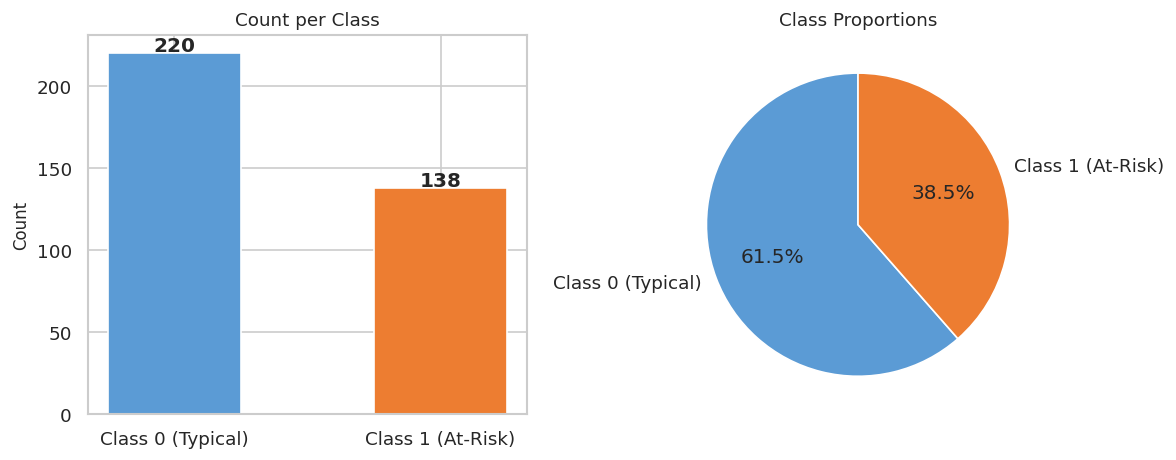

In [81]:
show_label_distribution_plot(df_raw, 'raw')

#### 1.2.4 Feature Distribution

To analyze the underlying distribution of the independent variables, a grid of overlapping histograms overlaid with Kernel Density Estimate (KDE) curves is generated, stratified by class. A specific technical consideration in this visualization involves the handling of the `[-99]` sentinel values: they are purposefully retained in the histograms to visually represent the scope of missing data, but are dynamically excluded from the KDE calculations to prevent significant distortion of the probability density curves. This approach ensures an accurate visual assessment of feature separability, class overlap, and the presence of distribution outliers prior to formal dataset normalization.

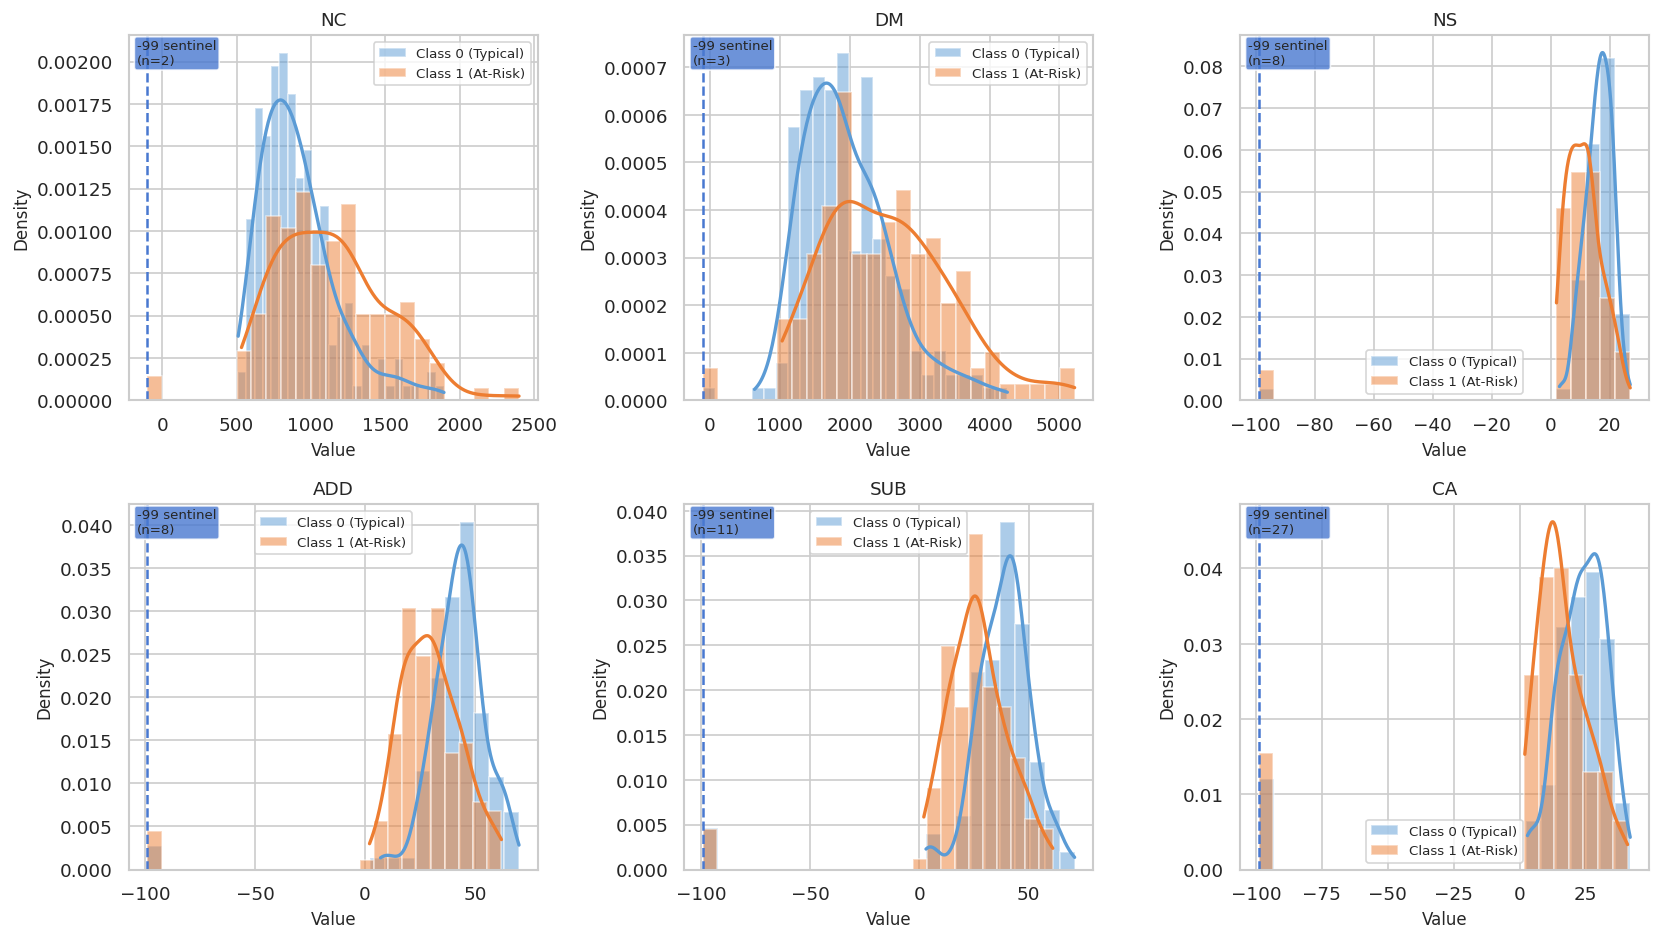

In [82]:
show_feature_distribution_plot(df_raw, 'raw', FEATURE_COLUMNS, DEFAULT_MISSING_VALUES)

#### 1.2.5 Feature x Class Outliers

This section utilizes boxplots to conduct a class-stratified analysis of feature dispersion and central tendencies. By partitioning the underlying data by the target label, we can visually assess the interquartile ranges (IQR) and reliably identify extreme outliers specific to each cohort. This stratified inspection is computationally crucial: because 'At-Risk' students intrinsically exhibit atypical scoring patterns, what might appear as a severe outlier on a global scale could actually represent a valid diagnostic signal within the minority class. Understanding these class-specific variances directly informs the localized, per-class IQR clipping strategy that will be implemented during the subsequent data cleaning phase.

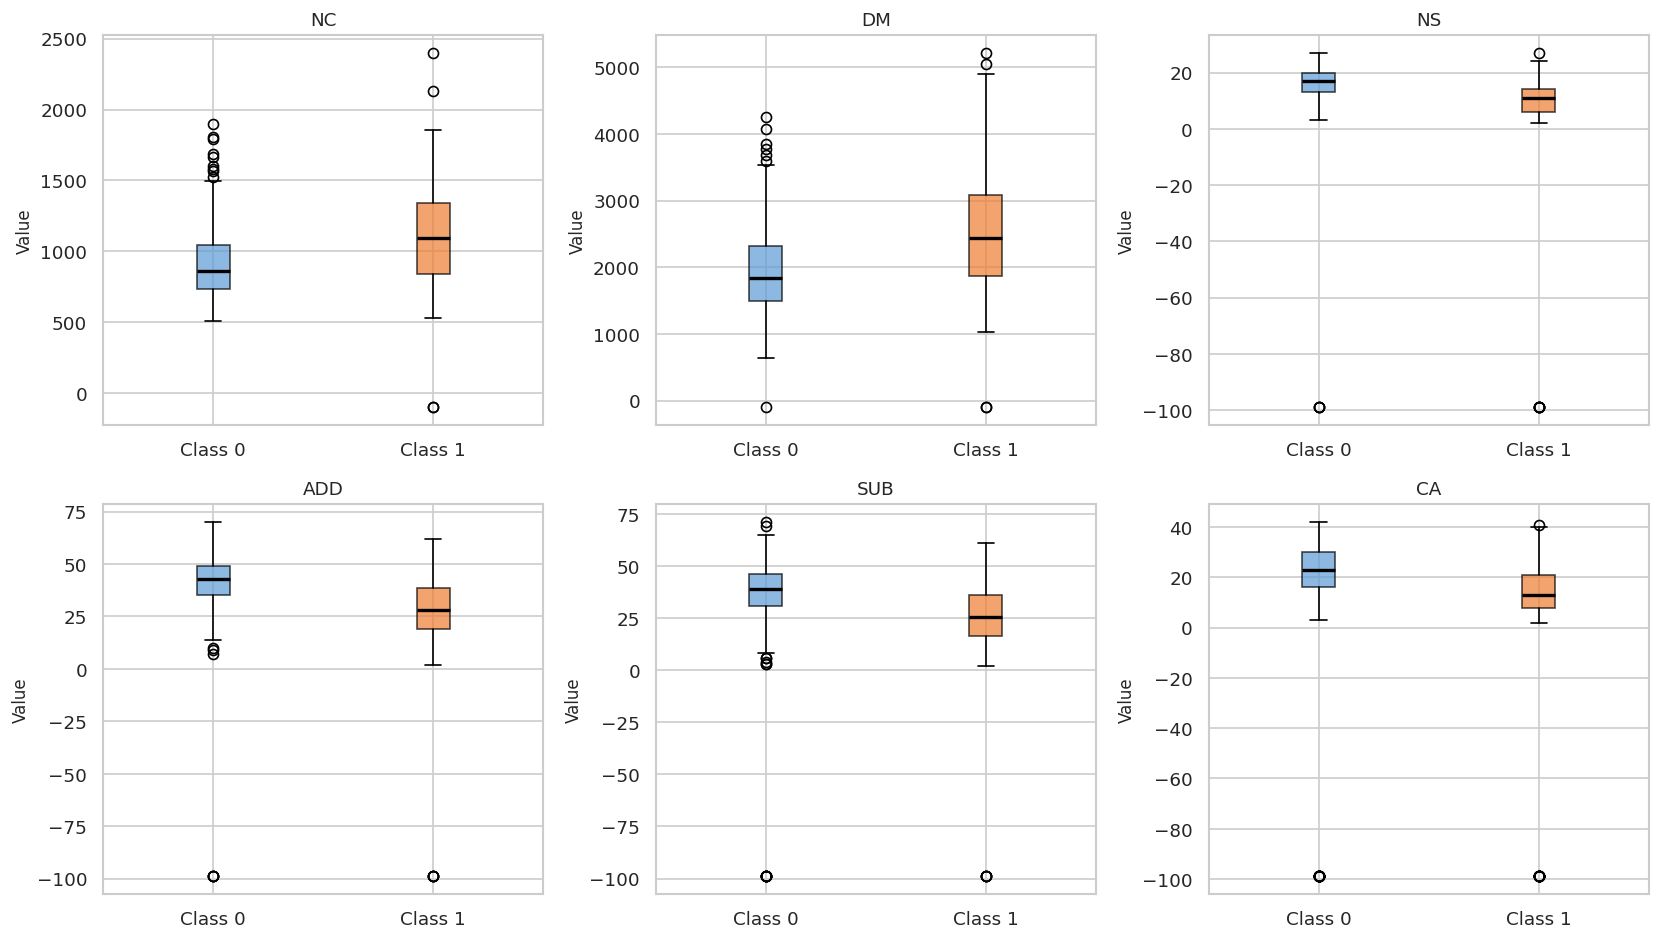

In [83]:
show_feature_class_outliers(df_raw, 'raw', FEATURE_COLUMNS)

#### 1.2.6 Correlation Matrix

In this section, a pairwise Pearson correlation matrix is generated to quantify the collinearity and linear relationships among the independent features. To contextualize these interactions within the dataset's domain, the matrix is visually partitioned to highlight two validated theoretical constructs: Number Processing (`NC`, `DM`) and Arithmetic Fluency (`NS`, `ADD`, `SUB`, `CA`). 

A critical technical observation during this stage of the EDA is the presence of strong negative correlations crossing between these two feature groups. While computationally this might initially suggest a data inversion error or scaling anomaly, it is absolutely structurally sound. The Number Processing variables act as efficiency indices (reaction time divided by accuracy, meaning a higher score indicates worse performance), whereas the Arithmetic Fluency variables are raw correct counts (where a higher score indicates better performance). Explicitly mapping and verifying this expected inverse relationship serves as a crucial sanity check, confirming the structural integrity of our diagnostic metrics before applying any predictive algorithms.

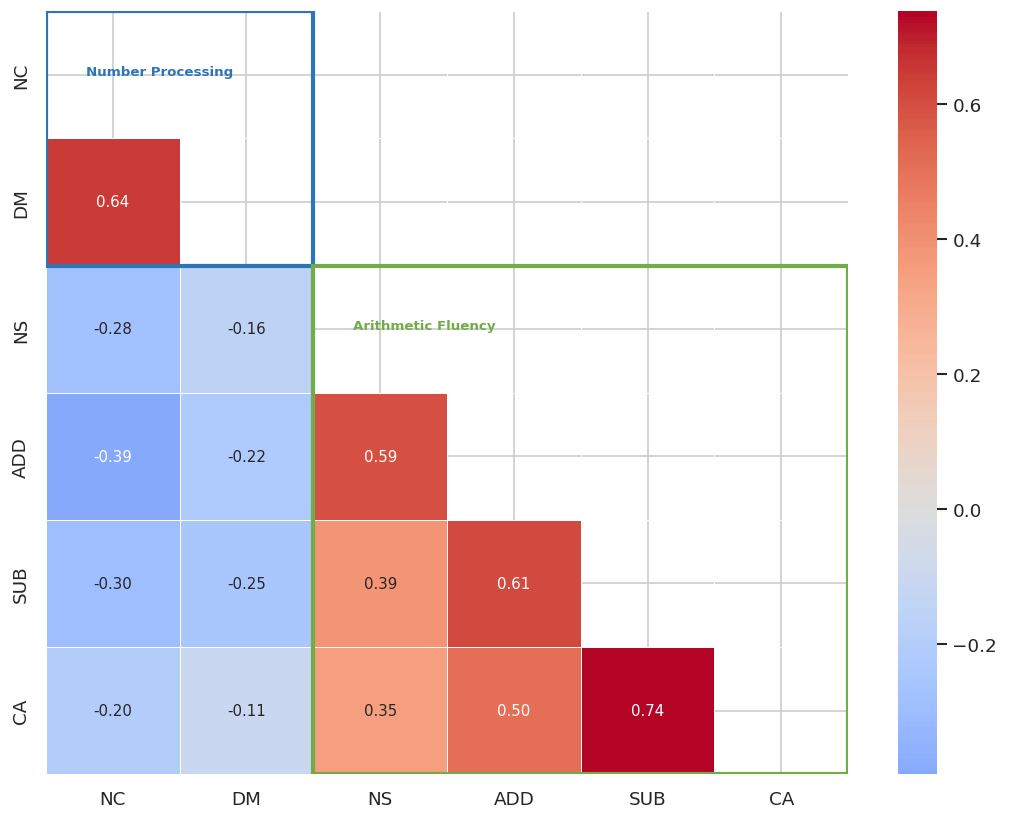

In [84]:
show_correlation_matrix(df_raw, 'raw', NUMBER_PROCESSING, ARITHMETIC_FLUENCY)

#### 1.2.7 Pairplot

To further investigate the multidimensional feature space prior to dataset normalization, this cell generates a pairwise scatter plot matrix overlaid with class-specific color mappings. This visualization provides a comprehensive view of both univariate distributions—via Kernel Density Estimates on the principal diagonal—and bivariate relationships across all independent variables. 

The variables are intentionally ordered to group the Number Processing metrics (`NC`, `DM`) alongside the Arithmetic Fluency metrics (`NS`, `ADD`, `SUB`, `CA`). By organizing the grid according to this theoretical two-factor structure, we can visually validate the clustering behaviors and inverse scaling relationships identified in the correlation matrix. From a machine learning perspective, examining these 2D projections is highly valuable; it helps identify localized regions of class separability, multivariate outliers, and non-linear feature interactions that decision tree algorithms, such as C4.5, are specifically optimized to exploit.

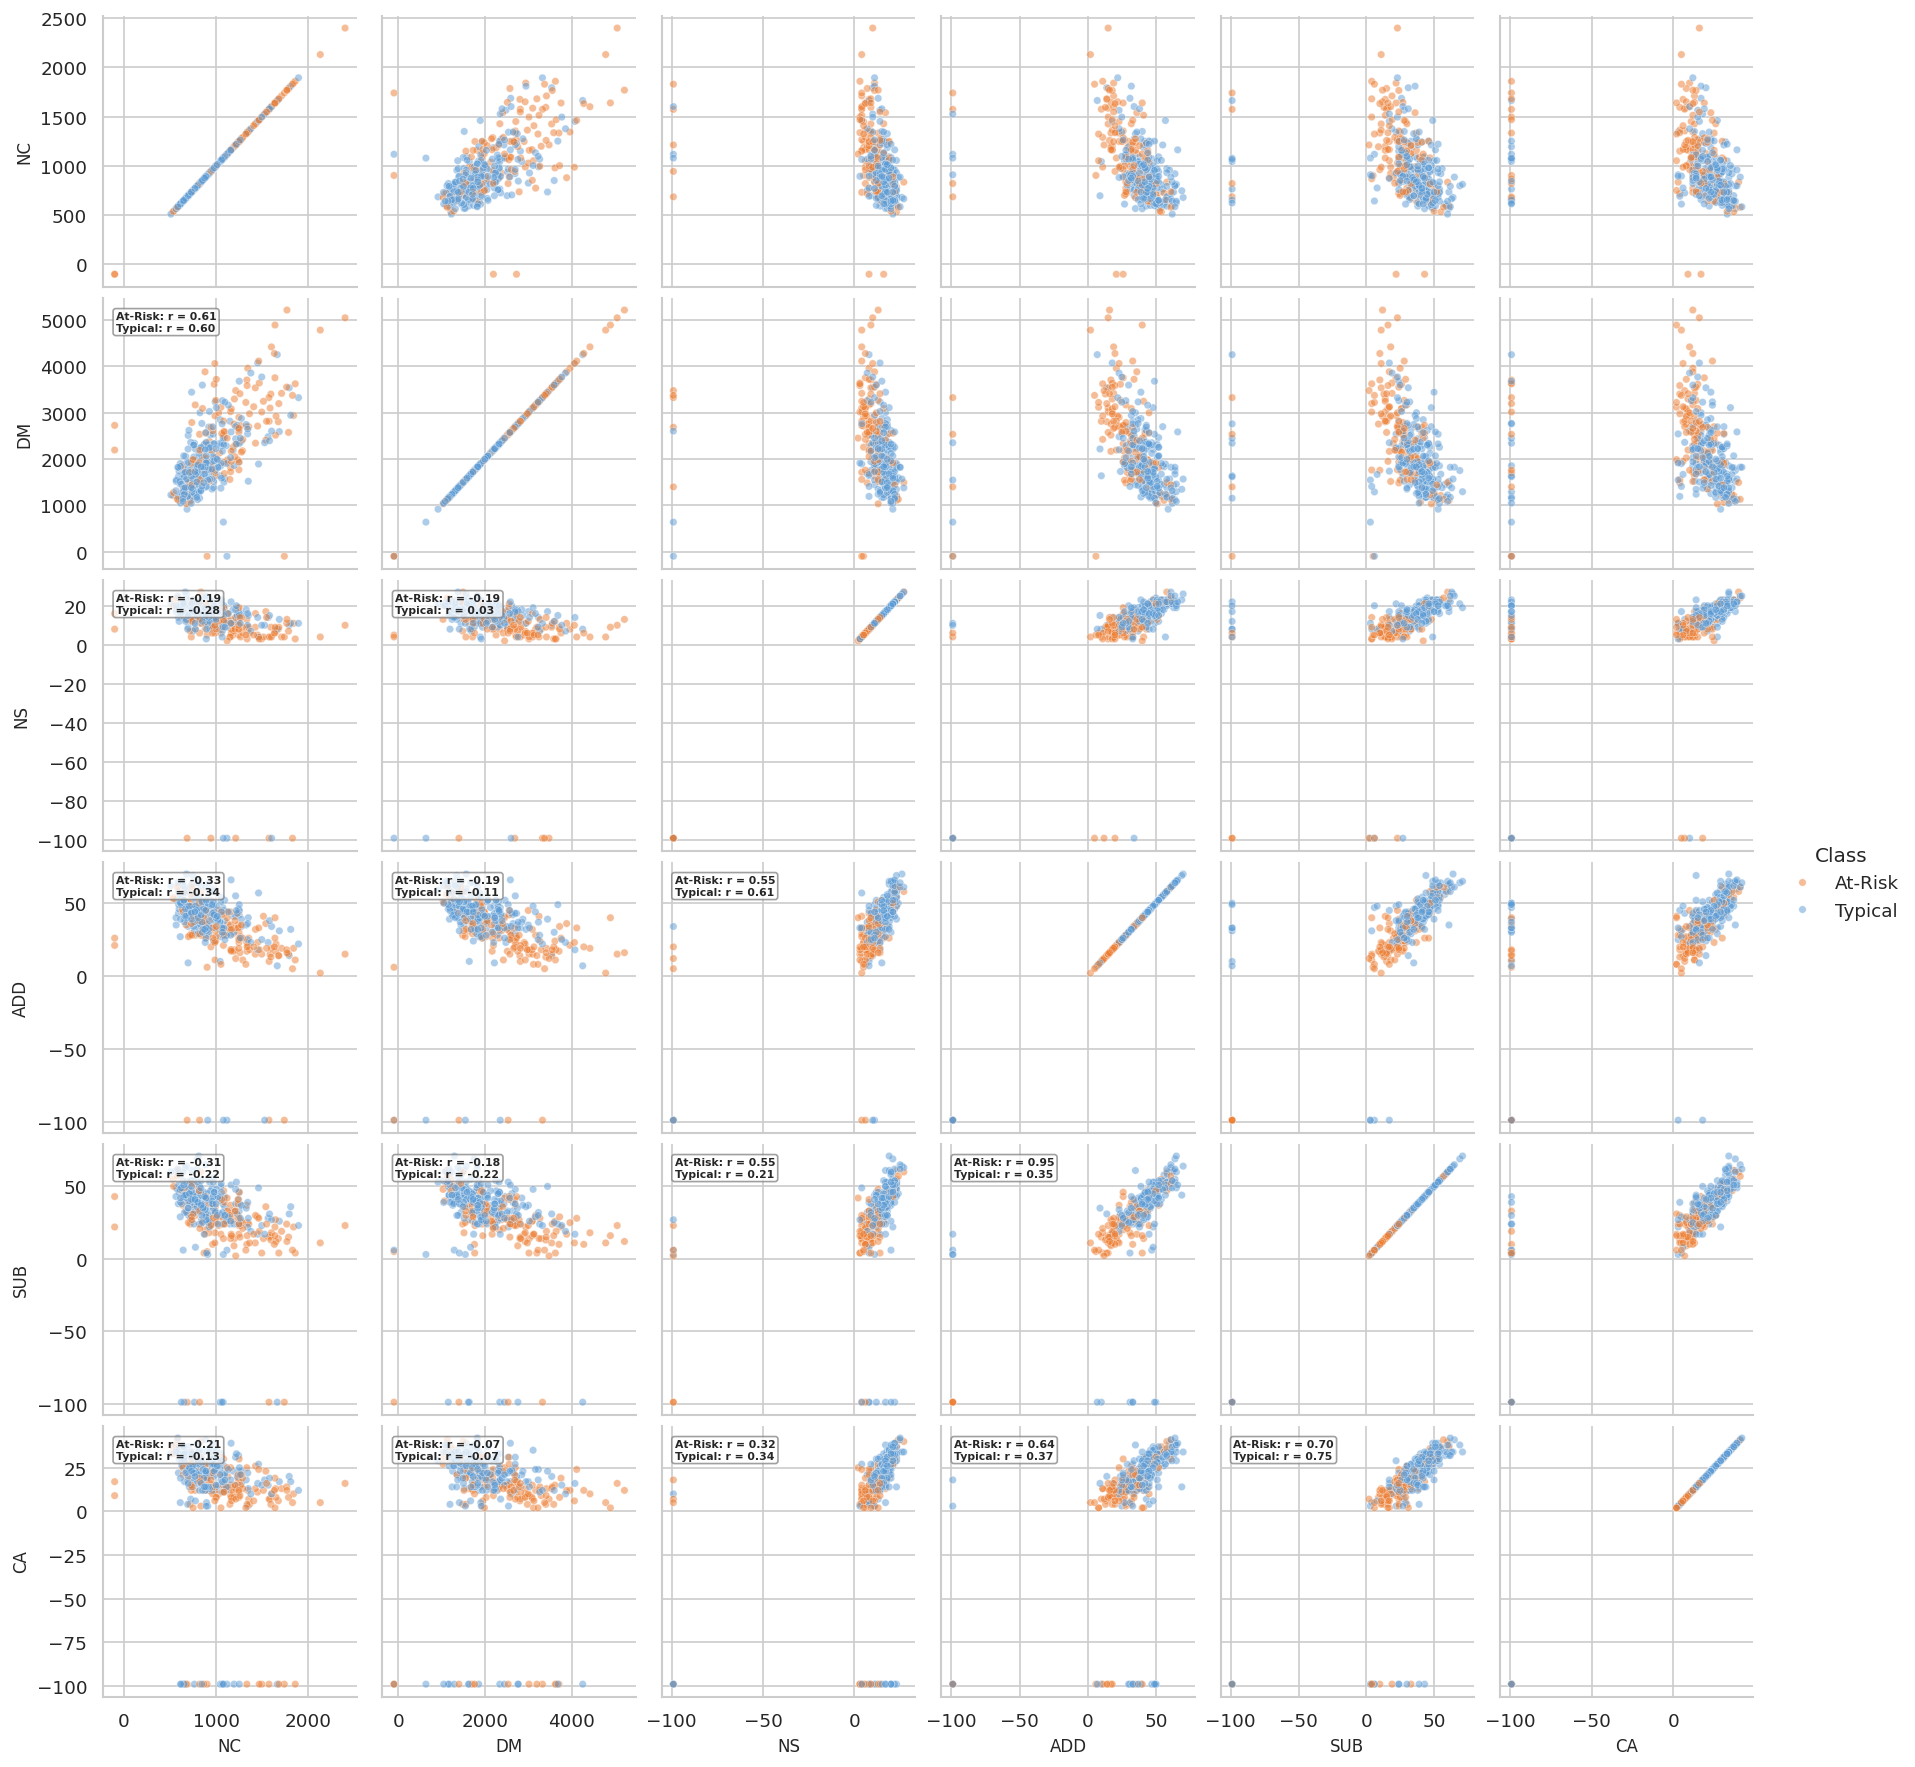

In [85]:
show_pairplot(df_raw, 'raw', FEATURE_COLUMNS)

### 1.3 Dataset Cleanup

#### 1.3.1 Missing Values Handling

##### 1.3.1.1 Replace Missing with Nan

In [86]:
df_clean = df_raw.copy()
df_clean = df_clean.replace(DEFAULT_MISSING_VALUES, np.nan)
print(f"Cells with values {DEFAULT_MISSING_VALUES} were replaced with nan")

Cells with values [-99] were replaced with nan


##### 1.3.1.2 Ensure Numerical Safety

In [87]:
for col in df_clean.columns:
    if col == 'Label':
        continue
    df_clean.loc[df_clean[col] < 0, col] = np.nan

print('NaN counts after sentinel/negative removal:')
print(df_clean[FEATURE_COLUMNS].isna().sum())

NaN counts after sentinel/negative removal:
NC      2
DM      3
NS      8
ADD     8
SUB    11
CA     27
dtype: int64


##### 1.3.1.3 Analyse Missingness by Class

Since missing values represent absent/incomplete students (not random), we first check whether missingness is disproportionate in the At-Risk class. If so, it is itself a diagnostic signal and must be preserved as indicator flags before imputing.

=== Missing counts per feature per class ===
             NC  DM  NS  ADD  SUB  CA
Typical (0)   0   1   3    4    7  15
At-Risk (1)   2   2   5    4    4  12

=== Missing rate (%) per feature per class ===
              NC   DM   NS  ADD  SUB   CA
Typical (0)  0.0  0.5  1.4  1.8  3.2  6.8
At-Risk (1)  1.4  1.4  3.6  2.9  2.9  8.7

Saving missing rates...
Done saving missing rates to outputs/logs_and_metrics/missing_rates.json.


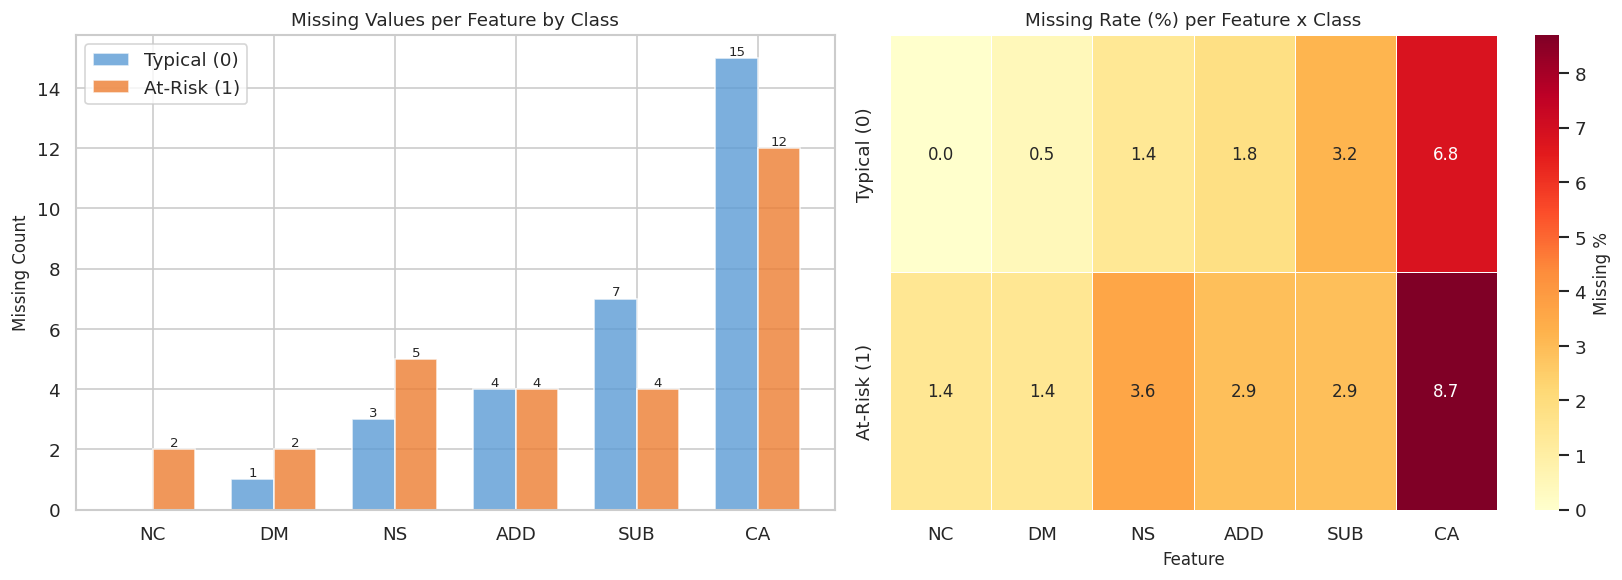


59 missing values found. Proceeding to create indicator flags.


In [88]:
print("=== Missing counts per feature per class ===")
missing_by_class = df_clean.groupby('Label')[FEATURE_COLUMNS].apply(lambda x: x.isna().sum())

# Display-friendly copy
missing_by_class_display = missing_by_class.copy()
missing_by_class_display.index = ['Typical (0)', 'At-Risk (1)']
print(missing_by_class_display)

print("\n=== Missing rate (%) per feature per class ===")
missing_rate = df_clean.groupby('Label')[FEATURE_COLUMNS].apply(
    lambda x: (x.isna().sum() / len(x) * 100).round(1)
)

# Display-friendly copy
missing_rate_display = missing_rate.copy()
missing_rate_display.index = ['Typical (0)', 'At-Risk (1)']
print(missing_rate_display)

# ---- Keep ORIGINAL numeric index for conversion ----
missing_rate_decimal = (missing_rate / 100).round(3)


# Safe conversion to nested dict
MISSING_RATES = {
    int(label): {
        k: float(v) for k, v in row.items() if pd.notna(v)
    }
    for label, row in missing_rate_decimal.iterrows()
}

print("\nSaving missing rates...")
MISSING_RATES_SAVEFILE = LOGS_OUTPUTS / "missing_rates.json"
with open(MISSING_RATES_SAVEFILE, "w") as f:
    json.dump(MISSING_RATES, f, indent=4)
print(F"Done saving missing rates to {MISSING_RATES_SAVEFILE.relative_to(ROOT_DIR)}.")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Missing count per feature, grouped by class
ax = axes[0]
miss_c0 = df_clean[df_clean['Label'] == 0][FEATURE_COLUMNS].isna().sum()
miss_c1 = df_clean[df_clean['Label'] == 1][FEATURE_COLUMNS].isna().sum()
x = np.arange(len(FEATURE_COLUMNS))
width = 0.35
ax.bar(x - width/2, miss_c0, width, label='Typical (0)', color=TYPICAL_COLOR, alpha=0.8)
ax.bar(x + width/2, miss_c1, width, label='At-Risk (1)',     color=AT_RIST_COLOR, alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(FEATURE_COLUMNS)
ax.set_ylabel('Missing Count')
ax.set_title('Missing Values per Feature by Class')
ax.legend()
for xi, (v0, v1) in enumerate(zip(miss_c0, miss_c1)):
    if v0 > 0: ax.text(xi - width/2, v0 + 0.1, str(v0), ha='center', fontsize=8)
    if v1 > 0: ax.text(xi + width/2, v1 + 0.1, str(v1), ha='center', fontsize=8)

# Chart 2: Missing rate heatmap
ax2 = axes[1]
rate_data = pd.DataFrame({
    'Typical (0)': (df_clean[df_clean['Label']==0][FEATURE_COLUMNS].isna().sum() / (df_clean['Label']==0).sum() * 100),
    'At-Risk (1)': (df_clean[df_clean['Label']==1][FEATURE_COLUMNS].isna().sum() / (df_clean['Label']==1).sum() * 100)
}).T
sns.heatmap(rate_data, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax2,
            linewidths=0.5, cbar_kws={'label': 'Missing %'}, annot_kws={'size': 10})
ax2.set_title('Missing Rate (%) per Feature x Class')
ax2.set_xlabel('Feature')

plt.tight_layout()
plt.show()

total_miss = df_clean[FEATURE_COLUMNS].isna().sum().sum()
if total_miss == 0:
    print("\nNo missing values found — missingness flags will be all-zero.")
else:
    print(f"\n{total_miss} missing values found. Proceeding to create indicator flags.")

##### 1.3.1.4 Create Missingness Indicator Flags

For each feature with any missing values, we add a binary `{feature}_incomplete` flag (1 = absent/did not finish, 0 = completed). These flags preserve the absence signal before it is overwritten by imputation.

  Created: NC_incomplete  (2 students flagged)
  Created: DM_incomplete  (3 students flagged)
  Created: NS_incomplete  (8 students flagged)
  Created: ADD_incomplete  (8 students flagged)
  Created: SUB_incomplete  (11 students flagged)
  Created: CA_incomplete  (27 students flagged)

Students with any incompleteness: 35
  Typical: 18
  At-Risk: 17

Flag columns added: ['NC_incomplete', 'DM_incomplete', 'NS_incomplete', 'ADD_incomplete', 'SUB_incomplete', 'CA_incomplete']


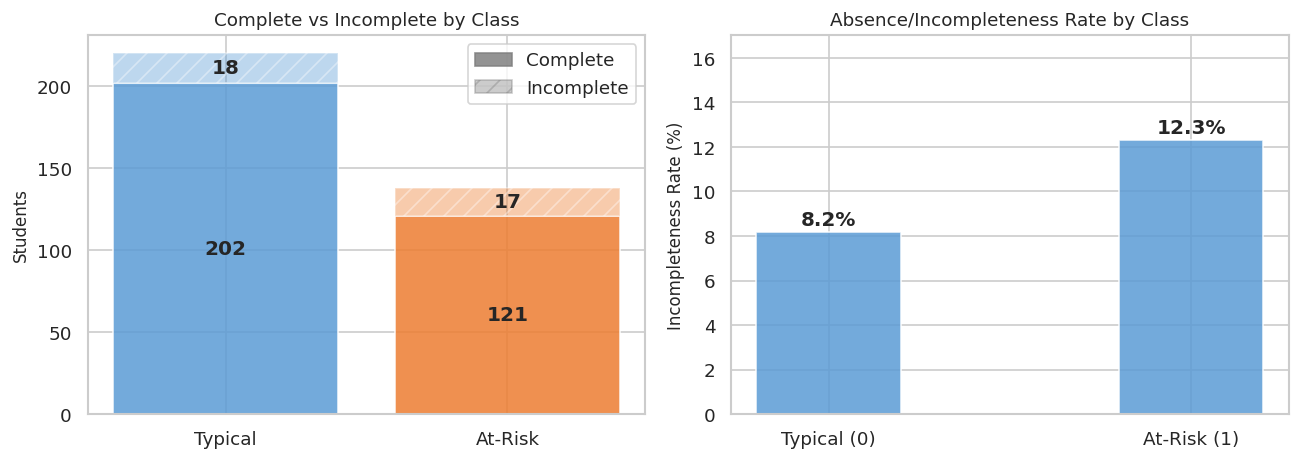

In [89]:
if total_miss > 0:
    flag_cols = []
    for col in FEATURE_COLUMNS:
        missing_mask = df_clean[col].isna()
        if missing_mask.sum() > 0:
            flag_name = f'{col}_incomplete'
            df_clean[flag_name] = missing_mask.astype(int)
            flag_cols.append(flag_name)
            print(f'  Created: {flag_name}  ({missing_mask.sum()} students flagged)')

    # Calculate students with any missing features dynamically
    any_missing_mask = df_clean[FEATURE_COLUMNS].isna().any(axis=1)

    print(f'\nStudents with any incompleteness: {any_missing_mask.sum()}')
    print(f'  Typical: {any_missing_mask[df_clean["Label"]==0].sum()}')
    print(f'  At-Risk: {any_missing_mask[df_clean["Label"]==1].sum()}')
    print(f'\nFlag columns added: {flag_cols}')

    if any_missing_mask.sum() > 0:
        fig, axes = plt.subplots(1, 2, figsize=(11, 4))
        
        # Stacked bar: incomplete vs complete per class
        ax = axes[0]
        for lbl, color, name in [(0,TYPICAL_COLOR,'Typical'),(1,AT_RIST_COLOR,'At-Risk')]:
            class_mask = df_clean['Label'] == lbl
            
            # Use our dynamically created mask instead of df['any_incomplete']
            n_inc  = any_missing_mask[class_mask].sum()
            n_comp = class_mask.sum() - n_inc
            
            ax.bar(name, n_comp, color=color, alpha=0.85)
            ax.bar(name, n_inc,  bottom=n_comp, color=color, alpha=0.4, hatch='//')
            
            # Label the complete count (centered in the bottom bar)
            if n_comp > 0:
                ax.text(name, n_comp / 2, str(n_comp), ha='center', va='center', fontweight='bold')
                
            # Label the incomplete count (centered in the top hatched bar)
            if n_inc > 0:
                ax.text(name, n_comp + (n_inc / 2), str(n_inc), ha='center', va='center', fontweight='bold')
            
        ax.set_ylabel('Students')
        ax.set_title('Complete vs Incomplete by Class')
        handles = [
            plt.Rectangle((0,0),1,1, color='grey', alpha=0.85, label='Complete'),
            plt.Rectangle((0,0),1,1, color='grey', alpha=0.4, hatch='//', label='Incomplete')
        ]
        ax.legend(handles=handles)

        # Incompleteness rate per class
        ax2 = axes[1]
        rates = [
            any_missing_mask[df_clean['Label']==0].mean() * 100,
            any_missing_mask[df_clean['Label']==1].mean() * 100
        ]
        bars = ax2.bar(['Typical (0)', 'At-Risk (1)'], rates,
                    color=[TYPICAL_COLOR,TYPICAL_COLOR], alpha=0.85, width=0.4)
        ax2.set_ylabel('Incompleteness Rate (%)')
        ax2.set_title('Absence/Incompleteness Rate by Class')
        ax2.set_ylim(0, max(rates)*1.3 + 1)
        for bar, rate in zip(bars, rates):
            ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                    f'{rate:.1f}%', ha='center', fontweight='bold')

        plt.tight_layout()
        plt.savefig(FIGURES_OUTPUTS / 'incomplete_per_class.png')
        plt.show()
    else:
        print('No missing values in dataset — incompleteness chart skipped.')

#### 1.3.3 Missing Values Cleanup

##### 1.3.3.1 Impute NaNs with Per-Class Median 

With the informative absence signals successfully preserved as binary flags, the raw dataset must now be numerically complete before subsequent modeling stages can proceed. Imputation is performed using the median rather than the mean to ensure robustness against the severe outliers identified during the univariate analysis. Crucially, this imputation is executed dynamically on a **per-class basis** (group-aware). 

Since 'At-Risk' students intrinsically exhibit fundamentally different scoring distributions and central tendencies compared to their 'Typical' peers, applying a global dataset median would artifactually force missing 'At-Risk' data points toward the typical baseline, destroying the diagnostic signal. By stratifying the imputation by the target label, we ensure that the imputed values accurately reflect the localized statistical reality of the student's respective cohort. In-Group. If an entire feature column for a specific class happens to be missing (NaN), a global fallback median is applied to prevent execution errors.

In [90]:
df_clean[FEATURE_COLUMNS] = df_clean.groupby('Label')[FEATURE_COLUMNS].transform(
    lambda x: x.fillna(x.median())
)
# Fallback: global median if an entire class column is NaN
df_clean = df_clean.fillna(df_clean.median(numeric_only=True))

##### 1.3.3.2 Per-Class IQR Clipping

Clipping is done within each class separately. At-Risk students may have genuinely different score ranges — clipping globally would corrupt that signal.

In [91]:
clip_bounds = {}
for col in FEATURE_COLUMNS:
    clip_bounds[col] = {}
    for label in df_clean['Label'].unique():
        mask = df_clean['Label'] == label
        Q1 = df_clean.loc[mask, col].quantile(0.25)
        Q3 = df_clean.loc[mask, col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        clip_bounds[col][label] = (lower, upper)
        df_clean.loc[mask, col] = df_clean.loc[mask, col].clip(lower, upper)

df_clean = df_clean.reset_index(drop=True)      # Sanity Check

print('Per-class clipping bounds applied:')
for col, bounds in clip_bounds.items():
    for label, (lo, hi) in bounds.items():
        name = 'Typical' if label == 0 else 'At-Risk'
        print(f'  {col} [{name}]: [{lo:.2f}, {hi:.2f}]')

Per-class clipping bounds applied:
  NC [At-Risk]: [162.37, 2050.36]
  NC [Typical]: [271.50, 1503.74]
  DM [At-Risk]: [68.71, 4902.44]
  DM [Typical]: [271.80, 3541.94]
  NS [At-Risk]: [-3.50, 24.50]
  NS [Typical]: [2.50, 30.50]
  ADD [At-Risk]: [-10.00, 68.00]
  ADD [Typical]: [16.50, 68.50]
  SUB [At-Risk]: [-11.50, 64.50]
  SUB [Typical]: [8.50, 68.50]
  CA [At-Risk]: [-5.88, 37.12]
  CA [Typical]: [1.88, 46.88]


### 1.4 After Cleaning Exploratory Dataset Analysis

#### 1.4.1 Dataset Exploration

In [92]:
print("=== Dataset Info ===")
print(df_clean.info())

print("\n=== Dataset Head ===")
print(df_clean.head())

print("\n=== Summary Statistics (raw) ===")
print(df_clean.describe().T.round(2))

print("\n=== Missing / Sentinel Values ===")
sentinel_mask = df_clean.isin(DEFAULT_MISSING_VALUES)
print(f"Cells equal to {DEFAULT_MISSING_VALUES}:", sentinel_mask.sum().sum())
print(sentinel_mask.sum()[sentinel_mask.sum() > 0])

print("\n=== Label Distribution ===")
print(df_clean['Label'].value_counts())

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 358 entries, 0 to 357
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   NC              358 non-null    float64
 1   DM              358 non-null    float64
 2   NS              358 non-null    float64
 3   ADD             358 non-null    float64
 4   SUB             358 non-null    float64
 5   CA              358 non-null    float64
 6   Label           358 non-null    int64  
 7   NC_incomplete   358 non-null    int64  
 8   DM_incomplete   358 non-null    int64  
 9   NS_incomplete   358 non-null    int64  
 10  ADD_incomplete  358 non-null    int64  
 11  SUB_incomplete  358 non-null    int64  
 12  CA_incomplete   358 non-null    int64  
dtypes: float64(6), int64(7)
memory usage: 36.5 KB
None

=== Dataset Head ===
            NC           DM    NS   ADD   SUB    CA  Label  NC_incomplete  \
0  1248.000000  2903.384615   5.0  23.0  17.

#### 1.4.2 Graphs

Feature Distribution


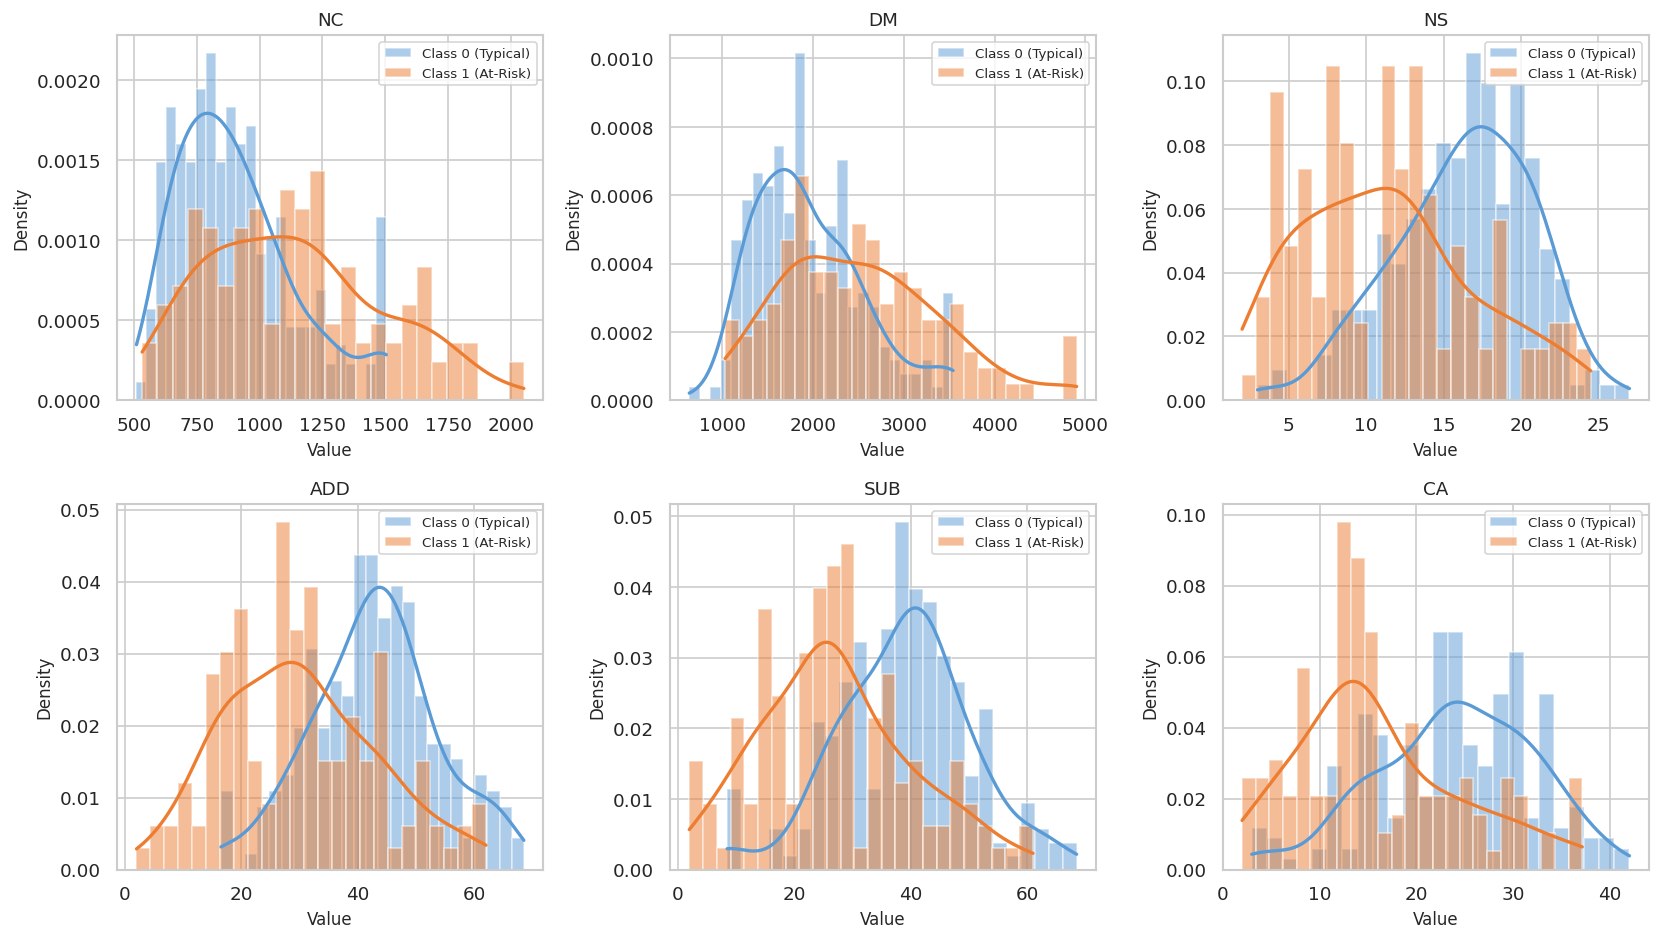

Feature Outliers


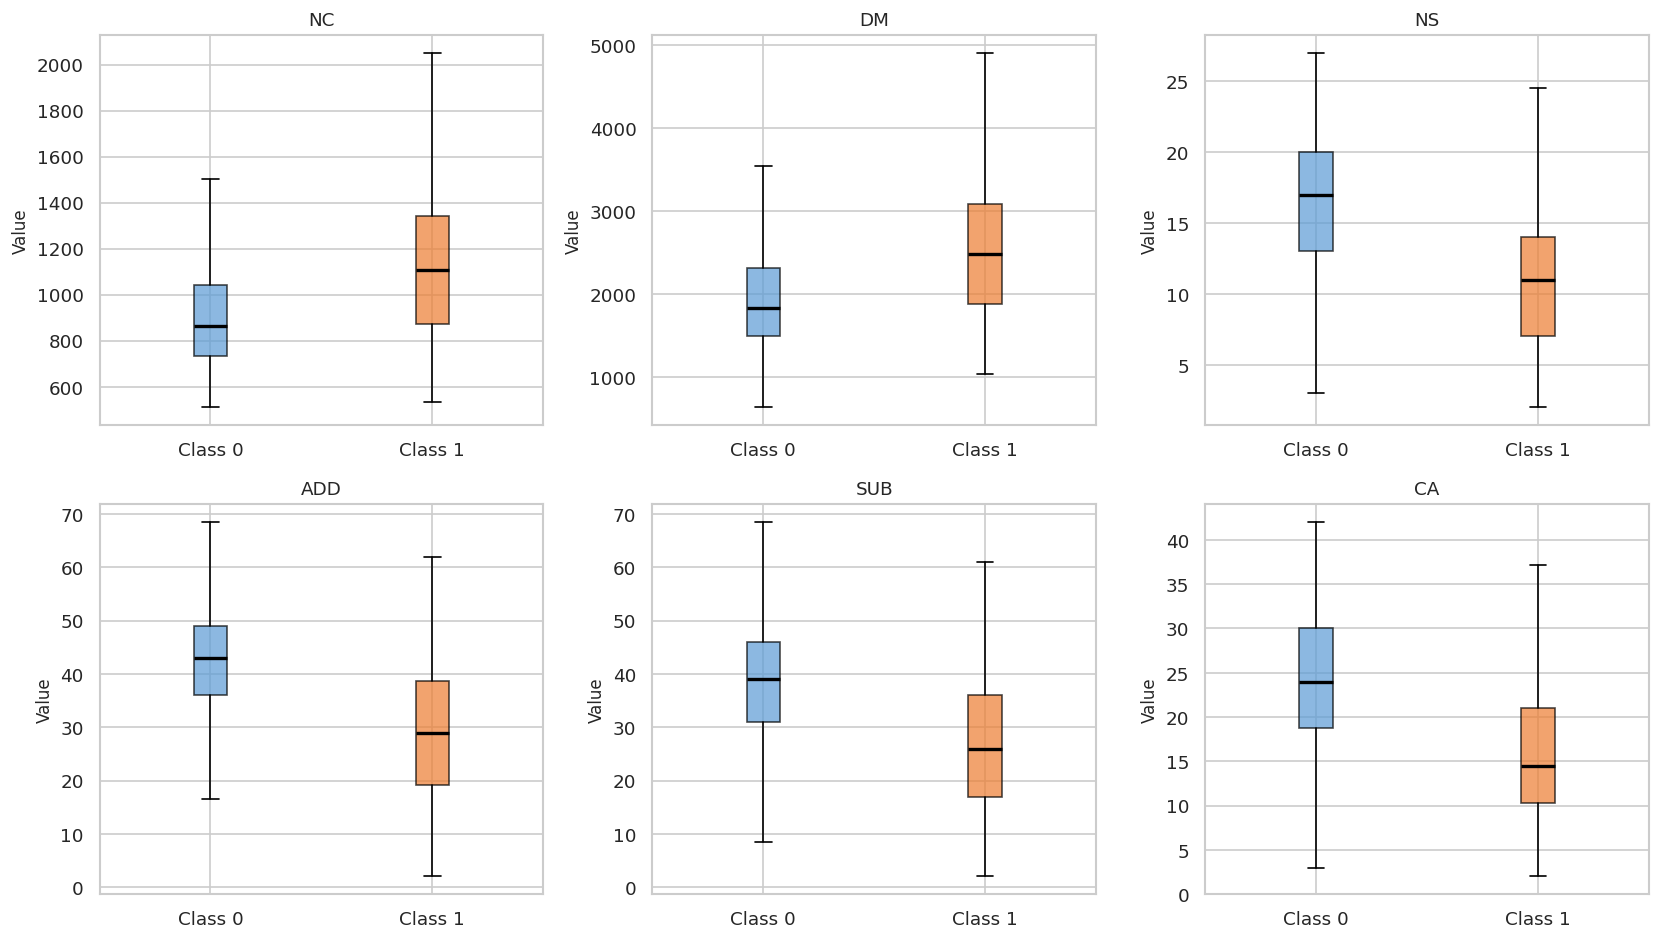

Correlation Matrix


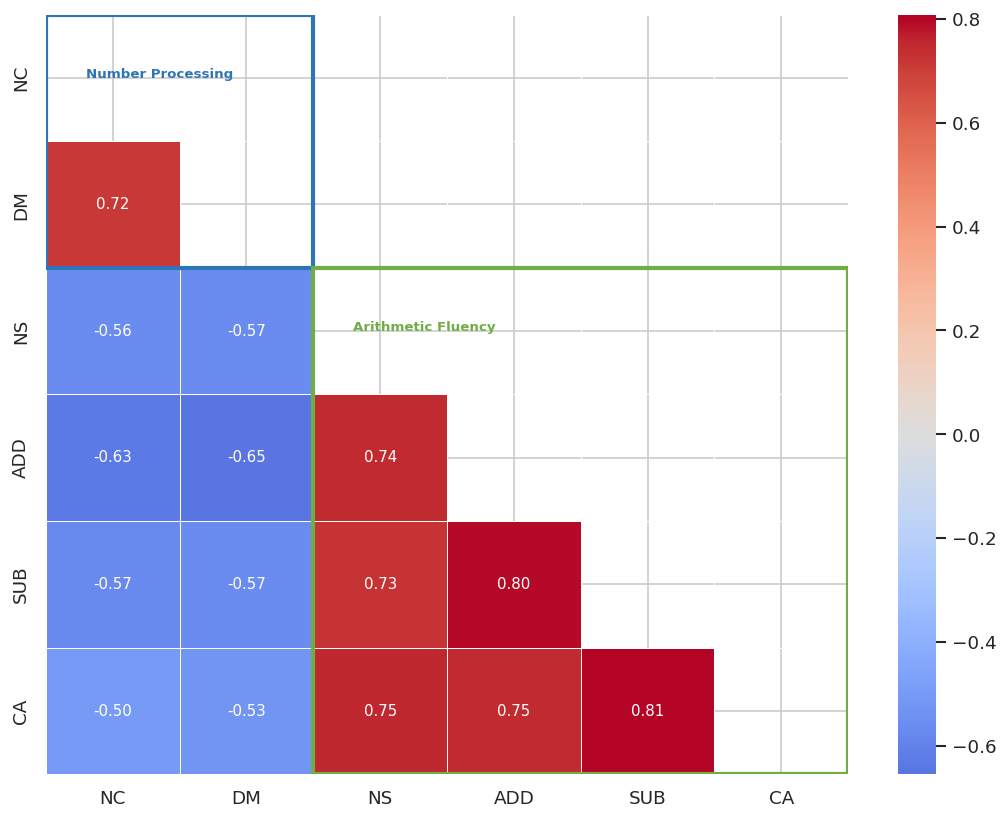

Pairplot


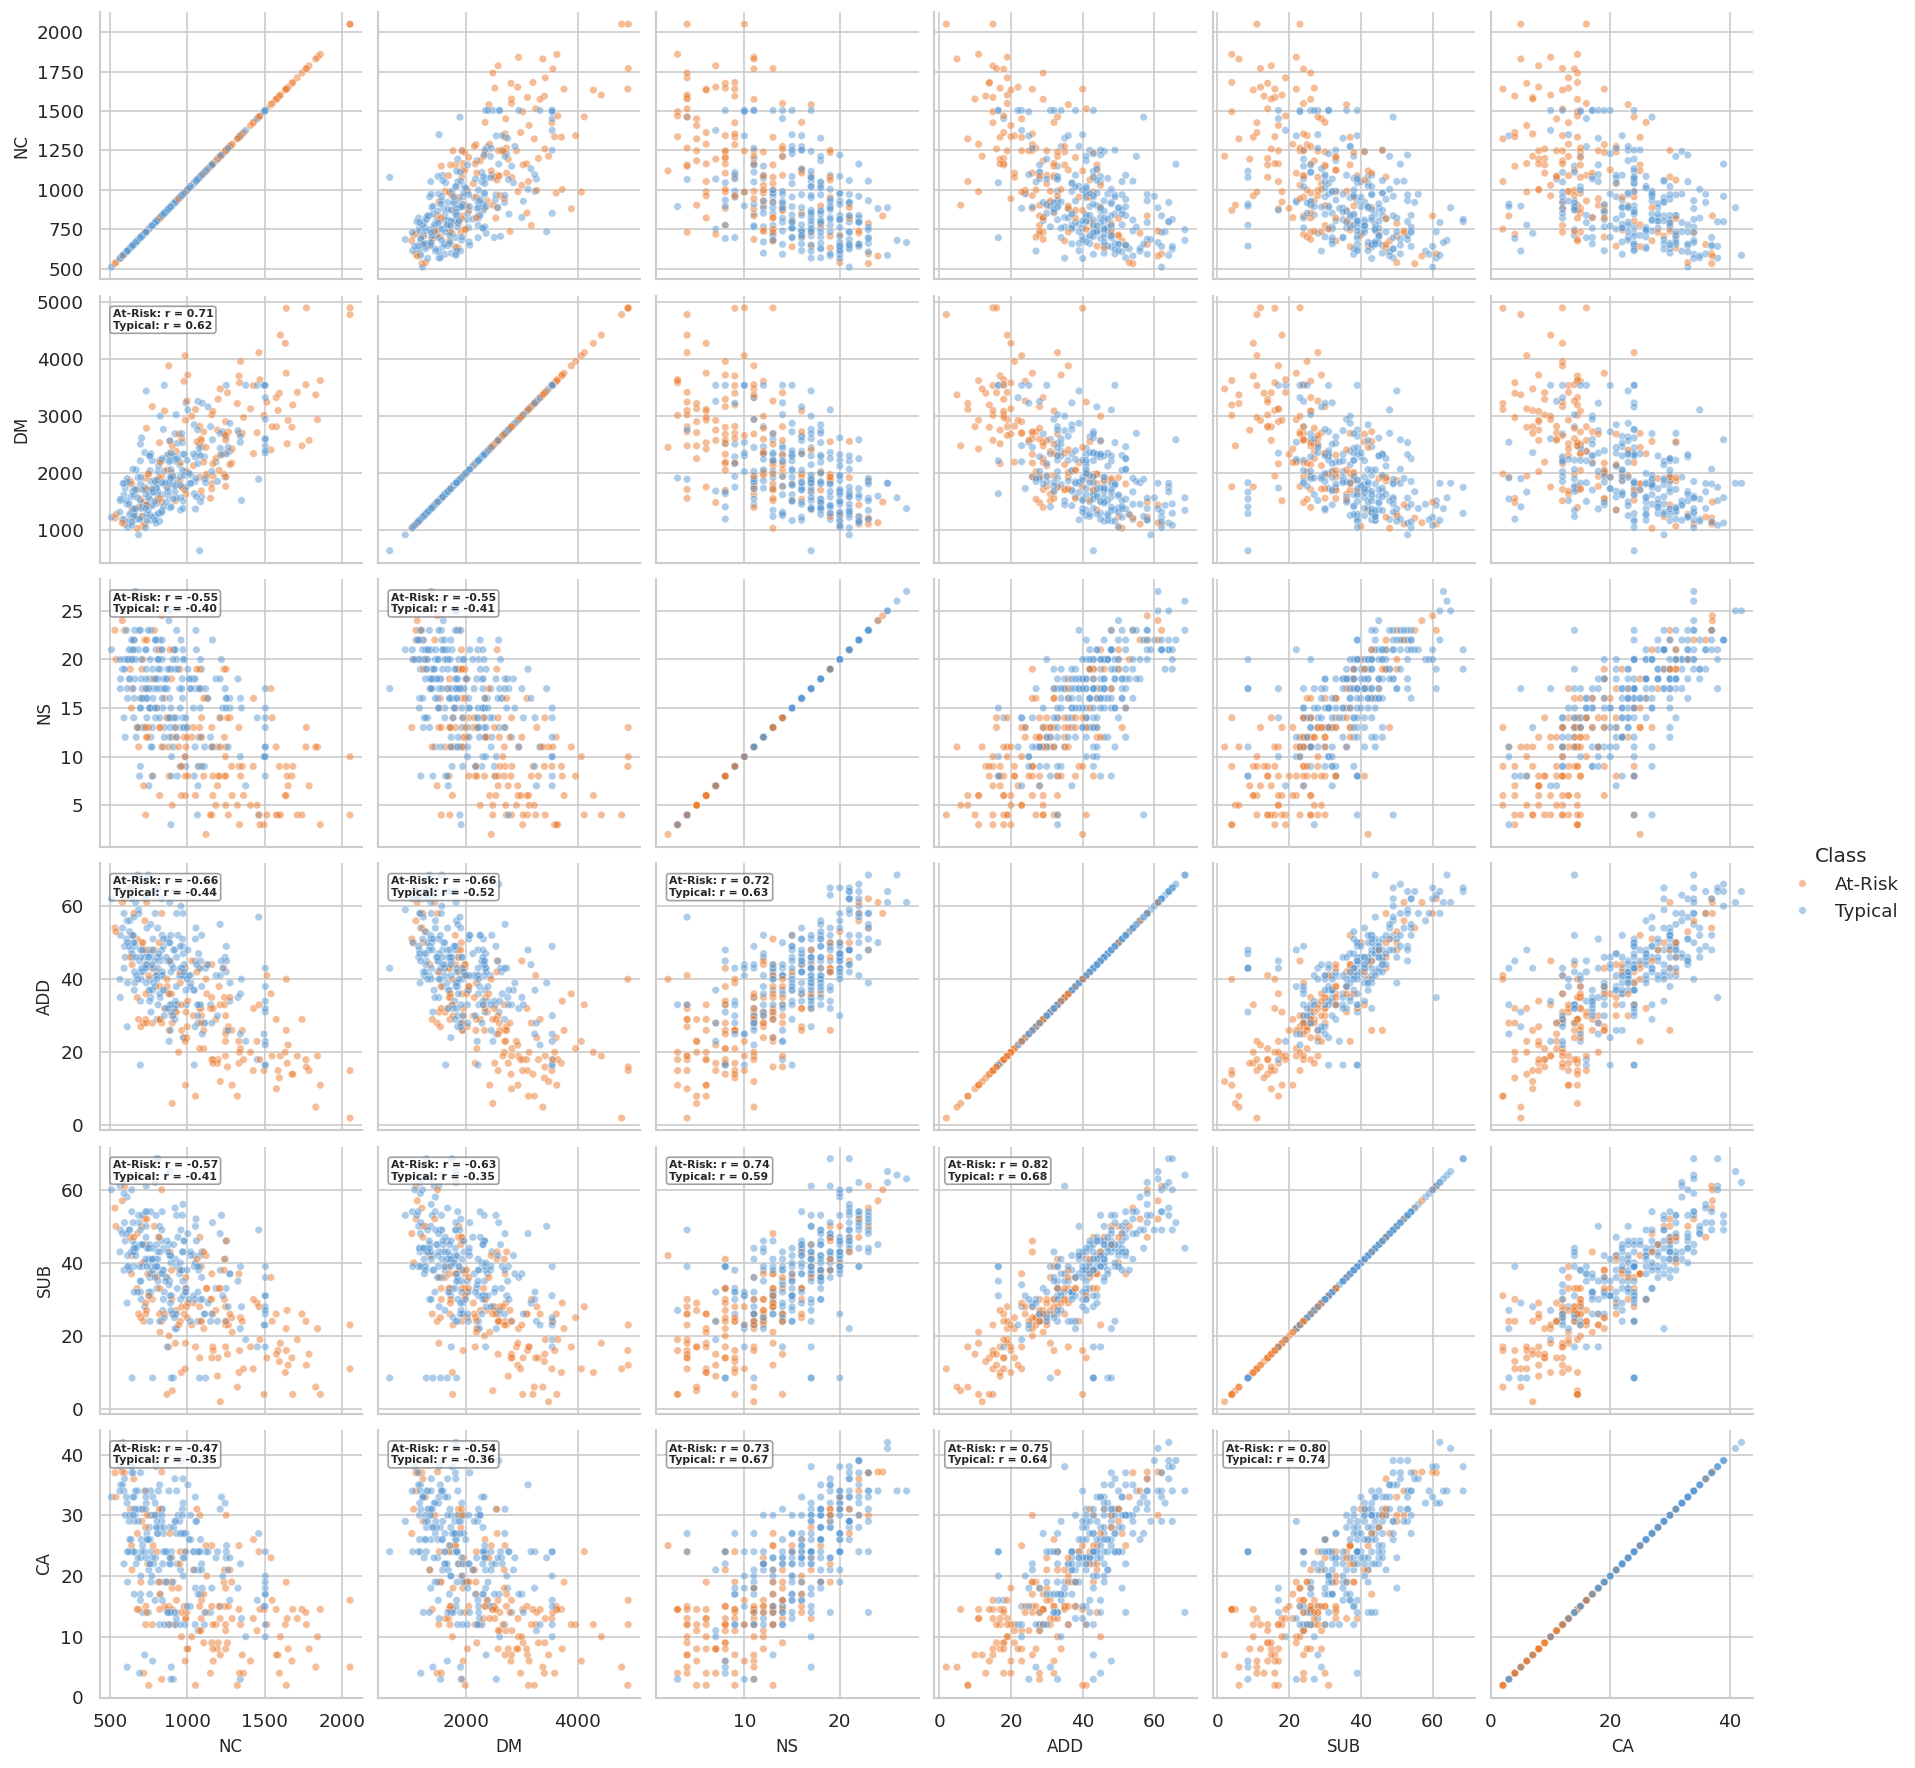

In [93]:
print("Feature Distribution")
show_feature_distribution_plot(df_clean, 'clean', FEATURE_COLUMNS, DEFAULT_MISSING_VALUES)

print("Feature Outliers")
show_feature_class_outliers(df_clean, 'clean', FEATURE_COLUMNS)

print("Correlation Matrix")
show_correlation_matrix(df_clean, 'clean', NUMBER_PROCESSING, ARITHMETIC_FLUENCY)

print("Pairplot")
show_pairplot(df_clean, 'clean', FEATURE_COLUMNS)

### 1.5 Before vs. After Comparison

#### 1.5.1 Numeric Comparison

In [94]:
rows = []
for col in FEATURE_COLUMNS:
    for label, dataset in [('RAW', df_raw), ('CLEAN', df_clean)]:
        s = dataset[col]
        rows.append({
            'Feature': col, 'Dataset': label,
            'Mean': s.mean(), 'Std': s.std(),
            'Min': s.min(), 'Max': s.max(),
            'NaN': s.isna().sum()
        })

comparison = pd.DataFrame(rows).set_index(['Feature', 'Dataset']).round(2)
comparison

Mean     Std     Min      Max  NaN
Feature Dataset                                       
NC      RAW       993.86  329.90  -99.00  2399.14    0
        CLEAN     994.96  305.99  510.82  2050.36    0
DM      RAW      2158.84  813.41  -99.00  5217.22    0
        CLEAN    2171.81  770.70  637.50  4902.44    0
NS      RAW        11.88   17.64  -99.00    27.00    0
        CLEAN      14.38    5.44    2.00    27.00    0
ADD     RAW        34.87   24.30  -99.00    70.00    0
        CLEAN      37.96   13.30    2.00    68.50    0
SUB     RAW        30.18   26.66  -99.00    71.00    0
        CLEAN      34.32   13.34    2.00    68.50    0
CA      RAW        12.00   33.01  -99.00    42.00    0
        CLEAN      20.94    9.12    2.00    42.00    0

In [95]:
df_clean.to_csv(PROCESSED_DATASET_DIR / 'cleaned_dataset.csv', index=False)

## 2.0 GAN-Based Synthetic Data Generation and Statistical Validation

These sections cover the use of CopulaGAN and CTGAN to synthetically augment the minority 'At-Risk' class within the strict confines of the training split, and the statistical validation of the resulting samples.

### 2.1 Synthetic Minority Oversampling — CopulaGAN + CTGAN


**Strategy:** GANs are trained strictly on the training minority class to prevent data leakage. Synthetic samples are injected **exclusively into the training split** — validation and test remain 100% real.

**Post-processing pipeline:**
1. Train CopulaGAN + CTGAN on raw features + BC (derived) so the model learns the ADD/SUB/CA joint structure.
2. Quantile-match each feature marginal on the full candidate pool.
3. KNN filter — retain the top 90th-percentile candidates closest to the real minority set.
4. Uniform sample to the required count (avoids centroid bias).
5. Hard assert: selected set must pass all distribution checks before proceeding.
6. Recompute all derived features deterministically from raw features.


#### 2.1.1 Setup and Missing Rates Import

To preserve the structural integrity of the "absent student" signals identified during the exploratory data analysis, empirical missing rates must be explicitly imported from our output artifacts. Generating synthetic records that strictly reflect the same missing data distributions as the real 'At-Risk' cohort is an essential methodological requirement for maintaining diagnostic validity in the subsequent model.

In [96]:
GAN_FEATURES = FEATURE_COLUMNS + ['BC']


# Load empirical missing rates from file (per label, per feature).
MISSING_RATES = {}
try:
    with open(MISSING_RATES_SAVEFILE, encoding='utf-8') as file:
        loaded_rates = json.load(file)

    # Normalize label keys to strings so downstream lookup is consistent.
    MISSING_RATES = {str(k): v for k, v in loaded_rates.items()}

    # Validate expected schema: labels -> FEATURE_COLUMNS -> numeric rates in [0, 1].
    for lbl in ['0', '1']:
        if lbl not in MISSING_RATES:
            raise ValueError(f"Missing label key '{lbl}' in {MISSING_RATES_SAVEFILE}")
        for f in FEATURE_COLUMNS:
            if f not in MISSING_RATES[lbl]:
                raise ValueError(f"Missing feature '{f}' under label '{lbl}' in missing_rates.json")
            MISSING_RATES[lbl][f] = float(np.clip(MISSING_RATES[lbl][f], 0.0, 1.0))

    print(f"{MISSING_RATES=}")
except FileNotFoundError:
    print(f"File not found: {MISSING_RATES_SAVEFILE}")
except json.JSONDecodeError:
    print(f"Invalid JSON format: {MISSING_RATES_SAVEFILE}")
except ValueError as err:
    print(f"Invalid missing-rate schema: {err}")

MISSING_RATES={'0': {'NC': 0.0, 'DM': 0.005, 'NS': 0.014, 'ADD': 0.018, 'SUB': 0.032, 'CA': 0.068}, '1': {'NC': 0.014, 'DM': 0.014, 'NS': 0.036, 'ADD': 0.029, 'SUB': 0.029, 'CA': 0.087}}


#### 2.1.2 Helper Functions

A suite of deterministic utility functions is defined to enforce reproducibility, perform exact feature derivations, inject empirical missingness rates, and rigorously validate the statistical distributions of the synthesized data against the real minority cohort.

##### 2.1.2.1 Set Seed Function

To guarantee exact reproducibility of stochastic processes—including GAN initialization, sampling, and KNN filtering—this function uniformly fixes the random seeds across the OS, Python, NumPy, and PyTorch environments.

In [97]:
def set_seed(seed):
    """Global seed for full reproducibility."""
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    try:
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(SEED)
        torch.use_deterministic_algorithms(True)
    except Exception:
        pass

print("set_seed helper function loaded.")

set_seed helper function loaded.


##### 2.1.2.2 Compute Derived Features

This function deterministically computes derived diagnostic metrics (e.g., Number Processing, Spatial Number, Arithmetic Facts) from the base clinical features according to the established equations. This ensures the foundational covariance structures are perfectly maintained.

In [98]:
def compute_derived(df: pd.DataFrame) -> pd.DataFrame:
    """Recompute all derived features from raw features deterministically."""
    df_der = df.copy()
    df_der['NP'] = (df_der['NC'] + df_der['DM']) / 2                           # Eq. 3.3
    df_der['SN'] = df_der['NC'] - df_der['DM']                                  # Eq. 3.4
    df_der['AF'] = (df_der['NS'] + df_der['ADD'] + df_der['SUB'] + df_der['CA']) / 4   # Eq. 3.5
    df_der['BC'] = (df_der['ADD'] + df_der['SUB']) / 2 - df_der['CA']              # Eq. 3.6
    df_der['AS'] = df_der['ADD'] - df_der['SUB']                                # Eq. 3.7
    df_der['PF'] = df_der['AF'] / (df_der['NP'] + EPSILON)                     # Eq. 3.8
    return df_der

print("compute_derived helper function loaded.")

compute_derived helper function loaded.


##### 2.1.2.3 Inject Missing Flags and Median Imputation

To preserve the critical "absent-student" diagnostic signal, this function simulates data sparsity in the synthetic records. It precisely mirrors the empirical missing-data distributions of the real 'At-Risk' cohort via pseudo-random binomial masking, subsequently applying median imputation to align with the preprocessing pipeline.

In [99]:
def inject_synthetic_missing(df: pd.DataFrame, missing_rates: dict,
                               features: list, df_min_ref: pd.DataFrame,
                               label_val: int = 1,
                               random_state: int = SEED) -> pd.DataFrame:
    """
    Simulate missing data in SYNTHETIC rows:
      1. Mark rows as missing per empirical rates.
      2. Impute with real minority-class median.
      3. Set <feature>_incomplete = 1.
    """
    print("\nGenerating synthetic incomplete flags...")
    rng = np.random.default_rng(random_state)
    df_der = df.copy()

    # Support both integer and string label keys (e.g., 1 and '1').
    rates = missing_rates.get(str(label_val), missing_rates.get(label_val, {}))

    feature_medians = {f: df_min_ref[f].median() for f in features}
    inc_cols = []
    for f in features:
        col = f + '_incomplete'
        inc_cols.append(col)
        df_der[col] = 0
        rate = float(np.clip(rates.get(f, 0.0), 0.0, 1.0))
        if rate <= 0.0:
            continue
        mask = rng.binomial(1, rate, size=len(df)).astype(bool)
        if mask.sum() == 0:
            continue
        df_der.loc[mask, f] = feature_medians[f]
        df_der.loc[mask, col] = 1
    print("Finished generating synthetic flags.")
    return df_der


print("inject_synthetic_missing helper function loaded.")

inject_synthetic_missing helper function loaded.


##### 2.1.2.4 Synthetic Data Distribution Checker

This module executes a rigorous statistical validation suite to ensure synthetic fidelity. It mandates that candidate synthetic features sequentially pass the Two-Sample Kolmogorov-Smirnov (KS) test, maintain a Jensen-Shannon Divergence (JSD) below threshold, and strictly bound deviations in mean, standard deviation, median, skewness, and kurtosis.

In [100]:
def distribution_check(
    df_syn_min: pd.DataFrame,
    df_train_min_full: pd.DataFrame,
    features: list,
    ks_pval: float = 0.05,
    T_mu: float = 0.10,
    T_sigma: float = 0.15,
    T_med: float = 0.1,
    T_skew: float = 0.75,
    T_kurt: float = 1.5,
    JSD_THRESHOLD: float = 0.10,
) -> tuple:
    """
    Statistical similarity check between real and synthetic minority-class data.
    Returns (all_pass: bool, results: pd.DataFrame).

    Checks per feature:
      KS test       — H0: same distribution; reject at α=0.05
      JSD           — Jensen-Shannon divergence over 20 bins < JSD_THRESHOLD
      Δμ, Δσ, Δmed  — normalised mean / std / median differences
      Δskew, Δkurt  — absolute skewness / excess-kurtosis differences
    """
    all_pass_global = True
    results = []

    hdr = f"{'Feature':<10} {f'KS (p>{ks_pval})':>22} {'JSD':>18} {'Δμ':>18} {'Δσ':>18} {'Δmed':>18} {'Δskew':>18} {'Δkurt':>18} {'ALL':>6}"
    print(hdr)
    print('-' * len(hdr))

    for f in features:
        real_f = df_train_min_full[f].values
        syn_f  = df_syn_min[f].values

        # KS test (Eq. 3.14)
        ks_stat, p_value = stats.ks_2samp(real_f, syn_f)
        ks_pass = p_value > ks_pval
        ks_str  = f"D={ks_stat:.4f} p={p_value:.4f} {'✓' if ks_pass else '✗'}"

        # Summary statistics
        mean_r, mean_s = np.mean(real_f), np.mean(syn_f)
        std_r,  std_s  = np.std(real_f, ddof=1), np.std(syn_f, ddof=1)
        med_r,  med_s  = np.median(real_f), np.median(syn_f)
        skew_r, skew_s = stats.skew(real_f, bias=True), stats.skew(syn_f, bias=True)
        kurt_r, kurt_s = stats.kurtosis(real_f, bias=True), stats.kurtosis(syn_f, bias=True)

        delta_mu   = abs(mean_s - mean_r) / (abs(mean_r) + EPSILON)
        delta_std  = abs(std_s  - std_r)  / (std_r       + EPSILON)
        delta_med  = abs(med_s  - med_r)  / (abs(med_r)  + EPSILON)
        delta_skew = abs(skew_s - skew_r)
        delta_kurt = abs(kurt_s - kurt_r)

        mu_pass   = delta_mu   < T_mu
        std_pass  = delta_std  < T_sigma
        med_pass  = delta_med  < T_med
        skew_pass = delta_skew < T_skew
        kurt_pass = delta_kurt < T_kurt

        # JSD
        bins         = np.histogram_bin_edges(np.concatenate([real_f, syn_f]), bins=20)
        p_real, _    = np.histogram(real_f, bins=bins, density=True)
        p_syn,  _    = np.histogram(syn_f,  bins=bins, density=True)
        jsd_val      = jensenshannon(p_real + EPSILON, p_syn + EPSILON) ** 2
        jsd_pass     = jsd_val < JSD_THRESHOLD

        stats_pass   = mu_pass and std_pass and med_pass and skew_pass and kurt_pass
        feature_pass = ks_pass and jsd_pass and stats_pass
        all_pass_global = all_pass_global and feature_pass

        jsd_s = f"{jsd_val:.4f}<{JSD_THRESHOLD} {'✓' if jsd_pass else '✗'}"
        mu_s  = f"{delta_mu:.4f}<{T_mu} {'✓' if mu_pass else '✗'}"
        sig_s = f"{delta_std:.4f}<{T_sigma} {'✓' if std_pass else '✗'}"
        med_s = f"{delta_med:.4f}<{T_med} {'✓' if med_pass else '✗'}"
        skw_s = f"{delta_skew:.4f}<{T_skew} {'✓' if skew_pass else '✗'}"
        krt_s = f"{delta_kurt:.4f}<{T_kurt} {'✓' if kurt_pass else '✗'}"
        print(f"{f:<10} {ks_str:>22} {jsd_s:>18} {mu_s:>18} {sig_s:>18} {med_s:>18} {skw_s:>18} {krt_s:>18} {'✓' if feature_pass else '✗':>6}")

        results.append(dict(
            feature=f, KS_stat=ks_stat, KS_p=p_value,
            JSD=jsd_val, delta_mu=delta_mu, delta_std=delta_std,
            delta_med=delta_med, delta_skew=delta_skew, delta_kurt=delta_kurt,
            ALL_pass=feature_pass,
        ))

    print('-' * len(hdr))
    print('Overall:', 'ALL FEATURES PASS ✓' if all_pass_global else 'Some features FAILED ✗')
    return all_pass_global, pd.DataFrame(results)


print("distribution_check helper function loaded.")


distribution_check helper function loaded.


### 2.2 Data Loading & Splitting

The dataset is partitioned into a strictly isolated 70/15/15 split (Train/Validation/Test) stratified by the target label. Synthetic generation targets strictly the training set to prevent data leakage. The `df_min_all` DataFrame isolates the real minority records specifically to supervise the GAN training process. 

In [101]:
df_GAN     = pd.read_csv(PROCESSED_DATASET_DIR / 'cleaned_dataset.csv')
df_raw = df_GAN[FEATURE_COLUMNS + ['Label']].copy()

# Keep the source split with its existing incomplete flags intact.
df_train, df_temp = train_test_split(df_GAN, test_size=0.30, stratify=df_GAN['Label'], random_state=SEED)
df_val,   df_test = train_test_split(df_temp, test_size=0.50, stratify=df_temp['Label'], random_state=SEED)

df_train_raw = df_train[FEATURE_COLUMNS + ['Label']].copy()
df_train_maj = df_train_raw[df_train_raw['Label'] == 0]
df_train_min = df_train_raw[df_train_raw['Label'] == 1]
n_synthetic_needed = len(df_train_maj) - len(df_train_min)

print('Data split (70 / 15 / 15):')
print(f'  Train      : {len(df_train):>4}  (maj={len(df_train_maj)}, min={len(df_train_min)})')
print(f'  Validation : {len(df_val):>4}')
print(f'  Test       : {len(df_test):>4}')
print(f'  Synthetic samples needed to balance train: {n_synthetic_needed}')

# Training minority set — STRICTLY isolated for GAN training
df_min_all = df_train_min[FEATURE_COLUMNS].copy()
df_min_all['BC'] = (df_min_all['ADD'] + df_min_all['SUB']) / 2 - df_min_all['CA']
df_min_ref = df_min_all.copy()   # reference used for all checks

print(f'\nMinority rows available for GAN training: {len(df_min_all)}')

metadata = SingleTableMetadata()
metadata.detect_from_dataframe(df_min_all)


Data split (70 / 15 / 15):
  Train      :  250  (maj=154, min=96)
  Validation :   54
  Test       :   54
  Synthetic samples needed to balance train: 58

Minority rows available for GAN training: 96


### 2.3 GAN Training and Candidate Selection

Two distinct architectures, `CopulaGANSynthesizer` and `CTGANSynthesizer`, are trained concurrently on the real minority data to capture the multi-dimensional joint distributions of the diagnostic metrics. An iterative hyperparameter search mechanism generates candidate pools from which the most statistically representative samples (via a KNN filter) are selected to perfectly balance the training classes.

#### 2.3.1 GAN Setup, Pipeline Function, and Configs

In [102]:
# Hyperparameter search grid.
# Each entry: (MULTIPLIER, epochs, batch_size, gen_lr, disc_lr)
GAN_SEARCH_GRID = [
    ( 7, 2000, 500, 2e-4, 2e-4),   # baseline
    (10, 2000, 500, 2e-4, 2e-4),   # bigger pool
    (10, 3000, 500, 2e-4, 2e-4),   # more epochs
    (10, 3000, 100, 2e-4, 2e-4),   # smaller batch
    (15, 3000, 100, 1e-4, 1e-4),   # lower LR
    (15, 5000, 100, 1e-4, 1e-4),   # high epochs
    (20, 5000, 100, 1e-4, 1e-4),   # max effort
    (30, 5000, 100, 1e-4, 1e-4),   # very high effort
    (50, 5000, 100, 1e-4, 1e-4),   # extreme effort
]

# Relaxed thresholds for the statistical measurements
# Due to small training dataset for the GAN training, we have relaxed the thresholds.
DIST_THRESHOLDS = dict(
    ks_pval = 0.05, T_mu=0.10, T_sigma=0.175, T_med=0.125,
    T_skew=0.75, T_kurt=1.5, JSD_THRESHOLD=0.13
)

# Fit scaler once on real minority data
scaler_global = StandardScaler().fit(df_min_all[GAN_FEATURES])

def run_gan_pipeline(config, seed=SEED, thresholds=None):
    """Train GANs, post-process, filter, and check distribution for one config."""
    if thresholds is None:
        thresholds = DIST_THRESHOLDS
    set_seed(seed)
    MULTIPLIER, epochs, batch_size, gen_lr, disc_lr = config

    n_generate = n_synthetic_needed * MULTIPLIER
    n_copula   = n_generate // 2
    n_ctgan    = n_generate - n_copula

    # Scale training data
    df_scaled = df_min_all.copy()
    df_scaled[GAN_FEATURES] = scaler_global.transform(df_scaled[GAN_FEATURES])

    common_kwargs = dict(
        metadata          = metadata,
        enforce_rounding  = False,
        embedding_dim     = 32,
        generator_dim     = (128, 128),
        discriminator_dim = (128, 128),
        epochs            = epochs,
        batch_size        = min(batch_size, 64),
        generator_lr      = gen_lr / 2,
        discriminator_lr  = disc_lr / 2,
        discriminator_steps = 2,
        pac               = 2,
        verbose           = True,
        enable_gpu        = False,
    )

    copula_synth = CopulaGANSynthesizer(**common_kwargs)
    copula_synth.fit(df_scaled)
    df_copula = copula_synth.sample(num_rows=n_copula)
    df_copula['source'] = 'copula'

    ctgan_synth = CTGANSynthesizer(**common_kwargs)
    ctgan_synth.fit(df_scaled)
    df_ctgan = ctgan_synth.sample(num_rows=n_ctgan)
    df_ctgan['source'] = 'ctgan'

    df_syn_raw = pd.concat([df_copula, df_ctgan], ignore_index=True)
    # ── Inverse scale back ──
    df_syn_raw[GAN_FEATURES] = scaler_global.inverse_transform(df_syn_raw[GAN_FEATURES])

    # ── Clip to observed real range (no redistribution) ──
    df_syn_pp = df_syn_raw[GAN_FEATURES + ['source']].copy()
    for f in GAN_FEATURES:
        lo = df_min_all[f].min()
        hi = df_min_all[f].max()
        df_syn_pp[f] = df_syn_pp[f].clip(lo, hi)

    # ── Round and cast integer features back to int64 ──
    # Must happen before distribution check so checks run on the same
    # dtype that will actually be saved — KS/JSD on floats vs integers
    # of the same values can produce different results.
    INT_FEATURES = ['NS', 'ADD', 'SUB', 'CA']
    for f in INT_FEATURES:
        if f in df_syn_pp.columns:
            df_syn_pp[f] = df_syn_pp[f].round().astype('int64')

    # KNN filter — keep top-90th-percentile candidates
    sc      = StandardScaler().fit(df_min_ref[GAN_FEATURES])
    real_sc = sc.transform(df_min_ref[GAN_FEATURES])
    syn_sc  = sc.transform(df_syn_pp[GAN_FEATURES])
    dists, _ = NearestNeighbors(n_neighbors=5).fit(real_sc).kneighbors(syn_sc)
    df_syn_pp['_knn'] = dists.mean(axis=1)
    thr = np.percentile(df_syn_pp['_knn'], 90)
    df_eligible = df_syn_pp[df_syn_pp['_knn'] <= thr].copy()

    df_selected = (
        df_eligible
        .sample(n=min(n_synthetic_needed, len(df_eligible)), random_state=seed)
        .drop(columns=['_knn', 'source', 'BC'])
        .reset_index(drop=True)
    )

    passed, df_stats = distribution_check(
        df_syn_min        = df_selected,
        df_train_min_full = df_min_ref,
        features          = FEATURE_COLUMNS,
        **thresholds,
    )
    return passed, df_selected, df_syn_pp, df_stats

print('GAN pipeline function defined.')


GAN pipeline function defined.


#### 2.3.2 GAN Hyperparameter Search

Auto-selects the best passing config
For every config that passes, a similarity score is computed as the sum of all normalised metric values (lower = closer to real data). The passing config with the lowest score is kept as df_selected.

In [103]:
search_results  = []
best_score      = np.inf
df_selected     = None
df_syn_pp       = None
df_dist_results = None
best_config     = None

for attempt, config in enumerate(GAN_SEARCH_GRID, 1):
    MULTIPLIER, epochs, batch_size, gen_lr, disc_lr = config
    print(f'\n[{attempt}/{len(GAN_SEARCH_GRID)}] MULTIPLIER={MULTIPLIER}, epochs={epochs}, '
          f'batch={batch_size}, lr=({gen_lr:.0e},{disc_lr:.0e})')
    print('-' * 70)

    passed, df_sel_tmp, df_pp_tmp, df_stats_tmp = run_gan_pipeline(
        config, seed=SEED, thresholds=DIST_THRESHOLDS
    )

    if passed:
        # Score = sum of all normalised metric values (lower is better)
        score = df_stats_tmp[
            ['delta_mu', 'delta_std', 'delta_med', 'delta_skew', 'delta_kurt', 'JSD']
        ].sum().sum()

        search_results.append((config, True, score))
        print(f'\n  → ✓ PASS  (score={score:.4f})')

        if score < best_score:
            best_score      = score
            df_selected     = df_sel_tmp
            df_syn_pp       = df_pp_tmp
            df_dist_results = df_stats_tmp
            best_config     = config
    else:
        search_results.append((config, False, np.inf))
        print(f'\n  → ✗ FAIL')

print('\n' + '=' * 70)
print('Search complete. Summary:')
print('=' * 70)
for cfg, ok, sc in search_results:
    mult, ep, bs, glr, dlr = cfg
    score_str = f'score={sc:.4f}' if ok else '       —      '
    marker    = ' ← best' if cfg == best_config else ''
    print(f'  MULT={mult:>2} ep={ep:>4} bs={bs:>3} lr=({glr:.0e},{dlr:.0e})  →  '
          f'{"✓ PASS" if ok else "✗ FAIL"}  {score_str}{marker}')

assert df_selected is not None, (
    'All configs failed — do not patch the data. Extend the grid or investigate GAN quality.'
)

df_selected['Label'] = 1
print(f'\n✓ Best config  : {best_config}')
print(f'  Best score   : {best_score:.4f}')
print(f'  Selected rows: {df_selected.shape[0]}')


[1/9] MULTIPLIER=7, epochs=2000, batch=500, lr=(2e-04,2e-04)
----------------------------------------------------------------------


Gen. (-00.96) | Discrim. (+00.08): 100%|██████████| 2000/2000 [00:56<00:00, 35.47it/s]
Gen. (-00.04) | Discrim. (+00.00): 100%|██████████| 2000/2000 [00:57<00:00, 35.08it/s]


Feature               KS (p>0.05)                JSD                 Δμ                 Δσ               Δmed              Δskew              Δkurt    ALL
----------------------------------------------------------------------------------------------------------------------------------------------------------
NC            D=0.1149 p=0.6741 ✓      0.0718<0.13 ✓       0.0401<0.1 ✓     0.0828<0.175 ✓     0.0098<0.125 ✓      0.0770<0.75 ✓       0.0011<1.5 ✓      ✓
DM            D=0.0826 p=0.9425 ✓      0.0549<0.13 ✓       0.0103<0.1 ✓     0.0986<0.175 ✓     0.0400<0.125 ✓      0.4374<0.75 ✓       1.0074<1.5 ✓      ✓
NS            D=0.1731 p=0.1985 ✓      0.0873<0.13 ✓       0.0606<0.1 ✓     0.2678<0.175 ✗     0.1364<0.125 ✗      0.1560<0.75 ✓       0.3751<1.5 ✓      ✗
ADD           D=0.1024 p=0.7957 ✓      0.0987<0.13 ✓       0.0175<0.1 ✓     0.0912<0.175 ✓     0.0508<0.125 ✓      0.1082<0.75 ✓       0.2641<1.5 ✓      ✓
SUB           D=0.1476 p=0.3642 ✓      0.0817<0.13 ✓       0.0888<0.1 

Gen. (-00.96) | Discrim. (+00.08): 100%|██████████| 2000/2000 [00:55<00:00, 35.80it/s]
Gen. (-00.04) | Discrim. (+00.00): 100%|██████████| 2000/2000 [00:55<00:00, 35.79it/s]


Feature               KS (p>0.05)                JSD                 Δμ                 Δσ               Δmed              Δskew              Δkurt    ALL
----------------------------------------------------------------------------------------------------------------------------------------------------------
NC            D=0.1020 p=0.7997 ✓      0.0373<0.13 ✓       0.0141<0.1 ✓     0.0822<0.175 ✓     0.0081<0.125 ✓      0.0005<0.75 ✓       0.1212<1.5 ✓      ✓
DM            D=0.1437 p=0.3976 ✓      0.0939<0.13 ✓       0.0458<0.1 ✓     0.0859<0.175 ✓     0.0120<0.125 ✓      0.2878<0.75 ✓       0.5971<1.5 ✓      ✓
NS            D=0.1807 p=0.1629 ✓      0.1096<0.13 ✓       0.0417<0.1 ✓     0.2522<0.175 ✗     0.1364<0.125 ✗      0.1108<0.75 ✓       0.4928<1.5 ✓      ✗
ADD           D=0.0873 p=0.9171 ✓      0.0806<0.13 ✓       0.0197<0.1 ✓     0.1322<0.175 ✓     0.0508<0.125 ✓      0.0286<0.75 ✓       0.4106<1.5 ✓      ✓
SUB           D=0.2152 p=0.0584 ✓      0.0876<0.13 ✓       0.1154<0.1 

...

Feature               KS (p>0.05)                JSD                 Δμ                 Δσ               Δmed              Δskew              Δkurt    ALL
----------------------------------------------------------------------------------------------------------------------------------------------------------
NC            D=0.0927 p=0.8777 ✓      0.0546<0.13 ✓       0.0456<0.1 ✓     0.0035<0.175 ✓     0.0751<0.125 ✓      0.0494<0.75 ✓       0.0181<1.5 ✓      ✓
DM            D=0.1207 p=0.6119 ✓      0.0410<0.13 ✓       0.0050<0.1 ✓     0.1508<0.175 ✓     0.0810<0.125 ✓      0.0960<0.75 ✓       0.3972<1.5 ✓      ✓
NS            D=0.1124 p=0.6981 ✓      0.0808<0.13 ✓       0.0573<0.1 ✓     0.1496<0.175 ✓     0.0000<0.125 ✓      0.0524<0.75 ✓       0.3979<1.5 ✓      ✓
ADD           D=0.1185 p=0.6375 ✓      0.0413<0.13 ✓       0.0524<0.1 ✓     0.0712<0.175 ✓     0.1186<0.125 ✓      0.2977<0.75 ✓       0.3496<1.5 ✓      ✓
SUB           D=0.1354 p=0.4711 ✓      0.0455<0.13 ✓       0.0612<0.1 

Gen. (-01.00) | Discrim. (-00.15): 100%|██████████| 5000/5000 [02:20<00:00, 35.71it/s]
Gen. (+00.27) | Discrim. (-00.13): 100%|██████████| 5000/5000 [02:21<00:00, 35.24it/s]


Feature               KS (p>0.05)                JSD                 Δμ                 Δσ               Δmed              Δskew              Δkurt    ALL
----------------------------------------------------------------------------------------------------------------------------------------------------------
NC            D=0.1261 p=0.5607 ✓      0.0438<0.13 ✓       0.0437<0.1 ✓     0.0042<0.175 ✓     0.0124<0.125 ✓      0.0788<0.75 ✓       0.1107<1.5 ✓      ✓
DM            D=0.0995 p=0.8209 ✓      0.0872<0.13 ✓       0.0211<0.1 ✓     0.0341<0.175 ✓     0.0226<0.125 ✓      0.2396<0.75 ✓       0.8929<1.5 ✓      ✓
NS            D=0.1731 p=0.1985 ✓      0.1116<0.13 ✓       0.0461<0.1 ✓     0.0029<0.175 ✓     0.0909<0.125 ✓      0.3834<0.75 ✓       0.2307<1.5 ✓      ✓
ADD           D=0.1300 p=0.5207 ✓      0.0745<0.13 ✓       0.0851<0.1 ✓     0.0662<0.175 ✓     0.0508<0.125 ✓      0.2756<0.75 ✓       0.4289<1.5 ✓      ✓
SUB           D=0.1009 p=0.8107 ✓      0.1144<0.13 ✓       0.0299<0.1 

Gen. (-01.00) | Discrim. (-00.15): 100%|██████████| 5000/5000 [02:20<00:00, 35.62it/s]
Gen. (+00.27) | Discrim. (-00.13): 100%|██████████| 5000/5000 [02:19<00:00, 35.80it/s]


Feature               KS (p>0.05)                JSD                 Δμ                 Δσ               Δmed              Δskew              Δkurt    ALL
----------------------------------------------------------------------------------------------------------------------------------------------------------
NC            D=0.1131 p=0.6892 ✓      0.0613<0.13 ✓       0.0312<0.1 ✓     0.0027<0.175 ✓     0.0396<0.125 ✓      0.2040<0.75 ✓       0.5519<1.5 ✓      ✓
DM            D=0.2227 p=0.0456 ✗      0.0930<0.13 ✓       0.0847<0.1 ✓     0.0823<0.175 ✓     0.1369<0.125 ✗      0.5910<0.75 ✓       1.2731<1.5 ✓      ✗
NS            D=0.1774 p=0.1778 ✓      0.0785<0.13 ✓       0.0937<0.1 ✓     0.0359<0.175 ✓     0.1364<0.125 ✗      0.4286<0.75 ✓       0.1904<1.5 ✓      ✗
ADD           D=0.0858 p=0.9244 ✓      0.0472<0.13 ✓       0.0474<0.1 ✓     0.0175<0.175 ✓     0.0000<0.125 ✓      0.1375<0.75 ✓       0.0823<1.5 ✓      ✓
SUB           D=0.0945 p=0.8656 ✓      0.0564<0.13 ✓       0.0049<0.1 

### 2.4 Derived Features & Missing Flags

Having obtained a statistically sound, raw synthetic dataset, this section reconstructs the expanded feature space. Derived features are computed deterministically, and missingness flags are strategically injected to match the empirical profile of real subjects with Dyscalculia.

In [104]:
# Recompute all derived features deterministically from raw features
df_selected_full = compute_derived(df_selected)

# Inject missing flags into synthetic rows
df_selected_full = inject_synthetic_missing(
    df            = df_selected_full,
    missing_rates = MISSING_RATES,
    features      = FEATURE_COLUMNS,
    df_min_ref    = df_min_ref,
    label_val     = 1,
    random_state  = SEED,
)

df_selected_full['is_synthetic'] = 1

inc_cols = [f + '_incomplete' for f in FEATURE_COLUMNS]
print('Derived features recomputed and missing flags injected.')
any_missing_mask = df_selected_full[inc_cols].sum(axis=1) > 0
print(f'  Rows with incomplete data : {any_missing_mask.sum()}')
print(f'  Final columns ({len(df_selected_full.columns)}): {list(df_selected_full.columns)}')
display(df_selected_full.head())



Generating synthetic incomplete flags...
Finished generating synthetic flags.
Derived features recomputed and missing flags injected.
  Rows with incomplete data : 9
  Final columns (20): ['NC', 'DM', 'NS', 'ADD', 'SUB', 'CA', 'Label', 'NP', 'SN', 'AF', 'BC', 'AS', 'PF', 'NC_incomplete', 'DM_incomplete', 'NS_incomplete', 'ADD_incomplete', 'SUB_incomplete', 'CA_incomplete', 'is_synthetic']


,NC,DM,NS,ADD,SUB,CA,Label,NP,SN,AF,BC,AS,PF,NC_incomplete,DM_incomplete,NS_incomplete,ADD_incomplete,SUB_incomplete,CA_incomplete,is_synthetic
0,625.968084,1618.752219,8,18.0,21,17.0,1,1122.360151,-992.784136,16.00,2.5,-3,0.014256,0,0,0,0,0,0,1
1,955.253615,2584.233508,7,23.0,45,14.0,1,1769.743561,-1628.979893,22.25,20.0,-22,0.012572,0,0,0,0,0,0,1
2,740.417418,4099.737425,11,44.0,12,14.5,1,2420.077421,-3359.320007,18.50,21.0,32,0.007644,0,0,0,0,0,1,1
3,898.646870,1224.079219,20,29.5,22,30.0,1,1061.363045,-325.432350,25.25,-4.5,7,0.023790,0,0,0,1,0,0,1
4,941.438497,2188.389806,7,21.0,26,12.0,1,1564.914152,-1246.951309,16.50,11.5,-5,0.010544,0,0,0,0,0,0,1


### 2.5 Assemble Balanced Training Set

The structurally validated and post-processed synthetic minority records are concatenated with the original, unadulterated training dataset. The outcome is a perfectly balanced, leakage-free training environment properly equipped for subsequent classification models.

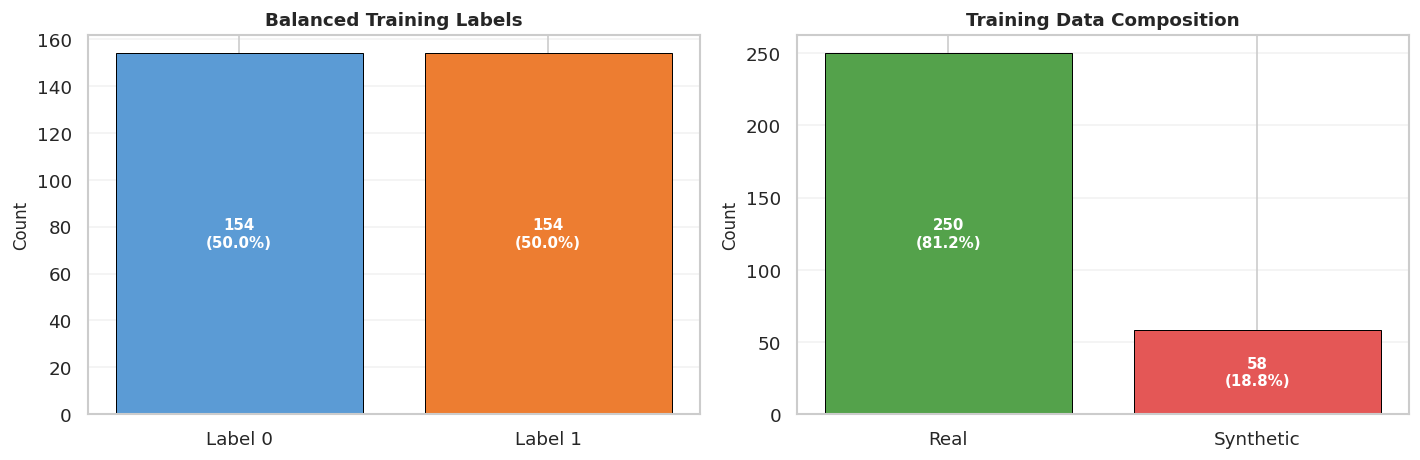

Balanced training set:
  Total      : 308
  Label = 0  : 154
  Label = 1  : 154
  Synthetic  : 58


,NC,DM,NS,ADD,SUB,CA,Label,NC_incomplete,DM_incomplete,NS_incomplete,ADD_incomplete,SUB_incomplete,CA_incomplete,NP,SN,AF,BC,AS,PF,is_synthetic
0,821.736842,2534.250000,6.0,29.0,26.0,14.5,1,0,0,0,1,1,1,1677.993421,-1712.513158,18.875,13.0,3.0,0.011249,0
1,1503.741422,2945.500000,11.0,32.0,36.0,17.0,0,0,0,0,0,0,0,2224.620711,-1441.758578,24.000,17.0,-4.0,0.010788,0
2,1195.480000,1855.170732,11.0,30.0,24.0,24.0,0,0,0,0,0,0,1,1525.325366,-659.690732,22.250,3.0,6.0,0.014587,0
3,859.591837,1832.775000,17.0,32.0,35.0,24.0,0,0,0,0,0,0,0,1346.183418,-973.183163,27.000,9.5,-3.0,0.020057,0
4,1229.583333,2728.342105,15.0,43.0,31.0,20.0,0,0,0,0,0,0,0,1978.962719,-1498.758772,27.250,17.0,12.0,0.013770,0


In [105]:
df_train_full = compute_derived(df_train)
df_train_full['is_synthetic'] = 0

# Concatenate real and synthetic training rows into one balanced training set.
df_train_balanced = pd.concat([df_train_full, df_selected_full], ignore_index=True)
counts = df_train_balanced['Label'].value_counts().sort_index()
source_counts = df_train_balanced['is_synthetic'].value_counts().sort_index()
total_rows = len(df_train_balanced)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Label balance (0 vs 1)
label_vals = [counts.get(0, 0), counts.get(1, 0)]
label_bars = axes[0].bar(['Label 0', 'Label 1'], label_vals,
                         color=[TYPICAL_COLOR, AT_RIST_COLOR], edgecolor='black', linewidth=0.6)
axes[0].set_title('Balanced Training Labels', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].grid(axis='y', alpha=0.25)

# Real vs Synthetic composition
source_vals = [source_counts.get(0, 0), source_counts.get(1, 0)]
source_bars = axes[1].bar(['Real', 'Synthetic'], source_vals,
                          color=[REAL_COLOR, SYNTHETIC_COLOR], edgecolor='black', linewidth=0.6)
axes[1].set_title('Training Data Composition', fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].grid(axis='y', alpha=0.25)

# Annotate bars with count + percentage in the middle
for ax, values, bars in [
    (axes[0], label_vals, label_bars),
    (axes[1], source_vals, source_bars),
]:
    for value, bar in zip(values, bars):
        pct = (value / total_rows * 100) if total_rows else 0
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() / 2,
            f'{value}\n({pct:.1f}%)',
            ha='center',
            va='center',
            fontsize=9,
            fontweight='bold',
            color='white',
        )

plt.tight_layout()
plt.savefig(FIGURES_OUTPUTS / "training_label_distribution.png")
plt.show()

print('Balanced training set:')
print(f'  Total      : {len(df_train_balanced)}')
print(f'  Label = 0  : {counts.get(0, 0)}')
print(f'  Label = 1  : {counts.get(1, 0)}')
print(f'  Synthetic  : {source_counts.get(1, 0)}')

display(df_train_balanced.head())

### 2.6 Synthetic vs Training Comparison

To empirically verify the quality and structural integrity of the synthetic minority class against the real minority distribution, a suite of four diagnostic visual analyses are performed: 
1. **Overlaid histograms** — marginal distribution match per raw feature
2. **Q-Q plots** — quantile-level alignment per raw feature
3. **Correlation heatmaps** — feature relationship preservation
4. **Distribution check summary heatmap** — all metrics at a glance

#### 2.6.1 Overlaid Histograms

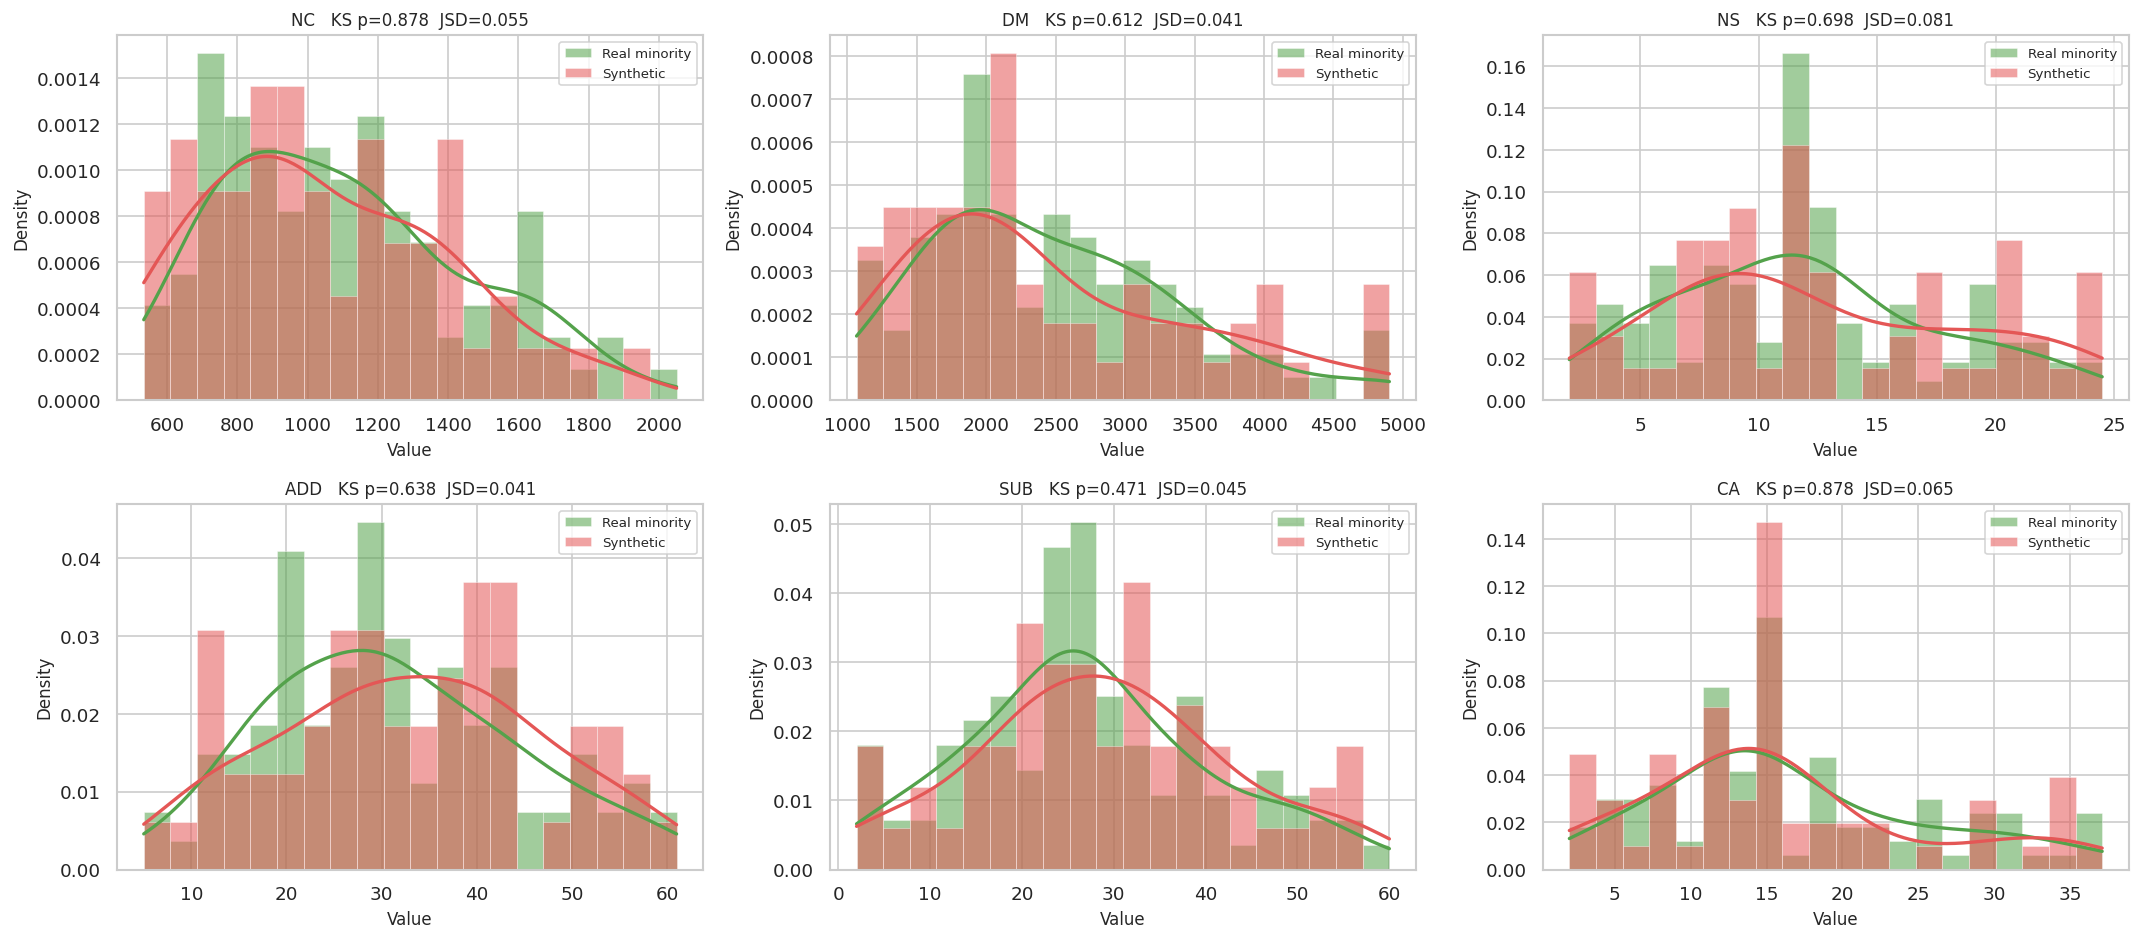

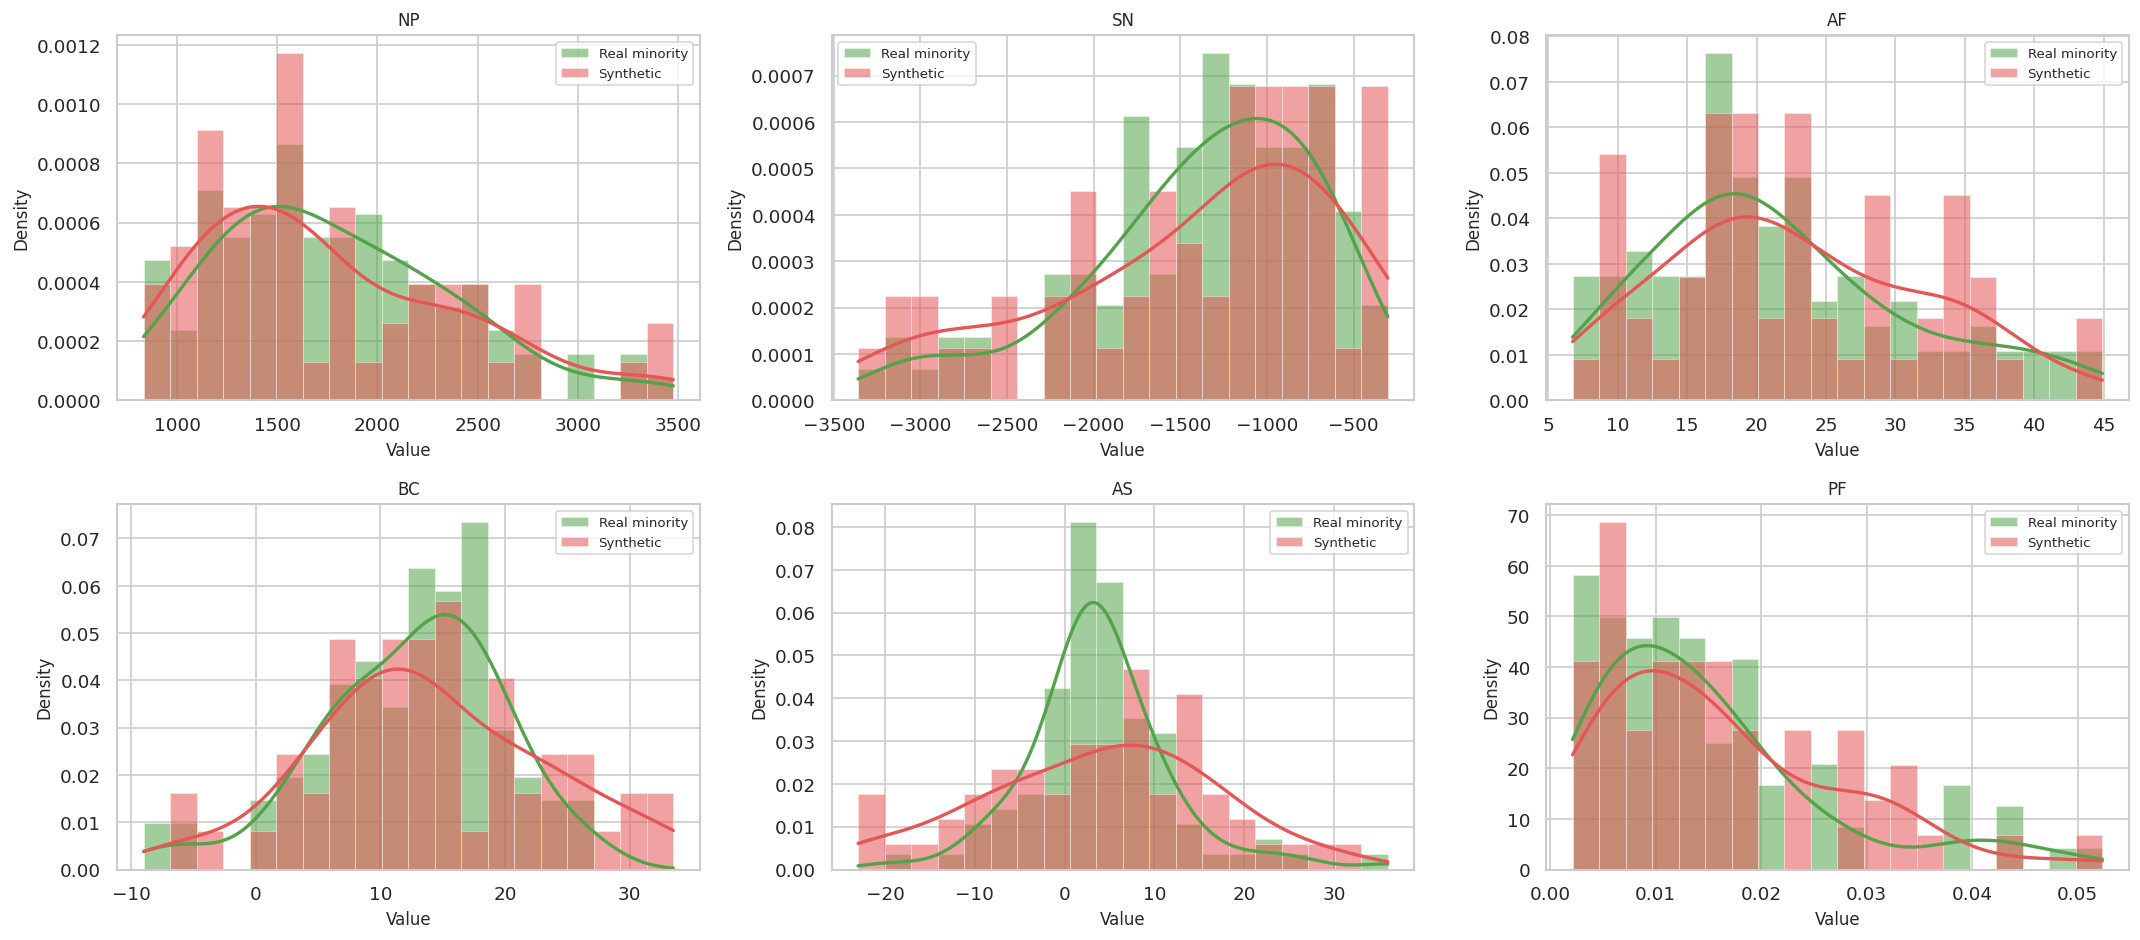

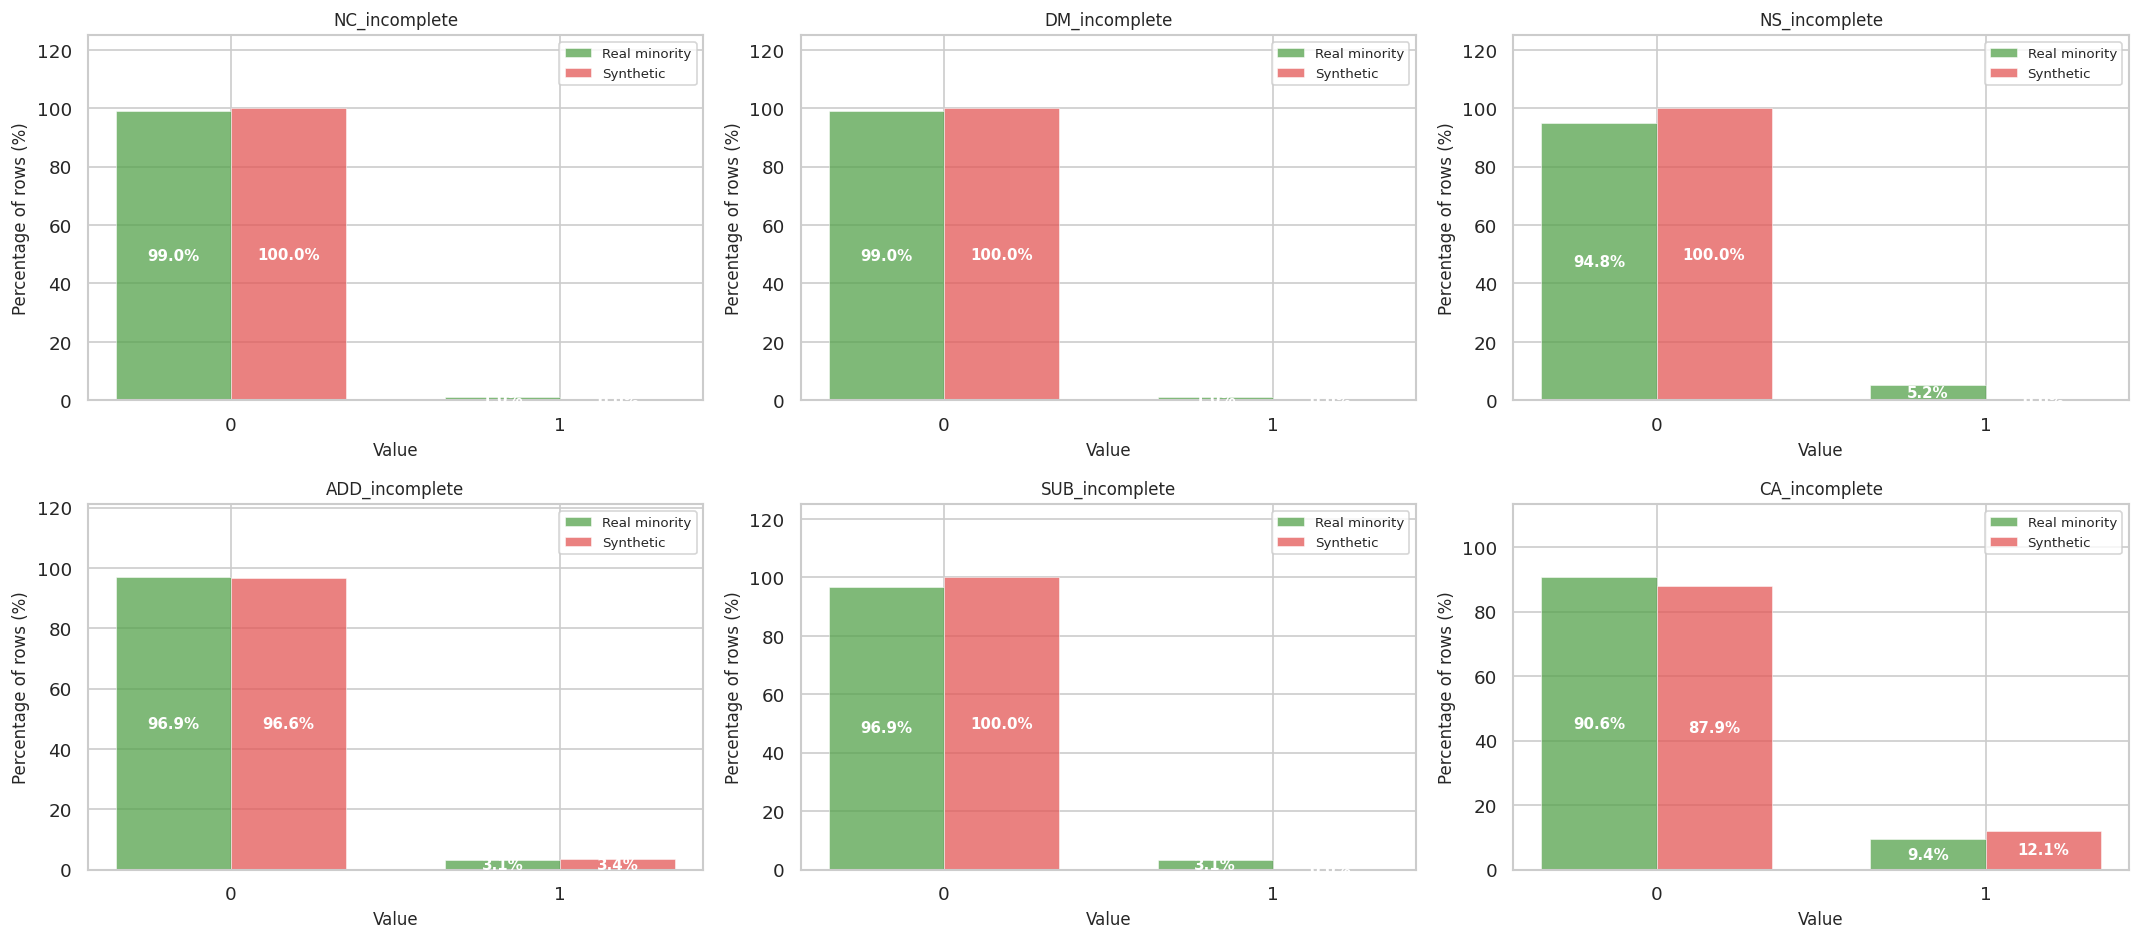

In [106]:
FEATURE_GROUPS = {
    'Raw Features': FEATURE_COLUMNS,
    'Derived Features': DERIVED_FEATURES,
    'Incomplete Flags': [f + '_incomplete' for f in FEATURE_COLUMNS],
}
df_train_vis = df_train_full[df_train_full['Label'] == 1]

for group_name, feature_list in FEATURE_GROUPS.items():
    ncols = 3
    nrows = int(np.ceil(len(feature_list) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows))
    axes = np.array(axes).ravel()

    for i, f in enumerate(feature_list):
        ax = axes[i]
        real_vals = df_train_vis[f]
        syn_vals  = df_selected_full[f]

        if f.endswith('_incomplete'):
            categories = np.array([0, 1])
            real_pct = [((real_vals == value).mean() * 100) for value in categories]
            syn_pct  = [((syn_vals == value).mean() * 100) for value in categories]
            x = np.arange(len(categories))
            width = 0.35

            real_bars = ax.bar(x - width / 2, real_pct, width,
                               color=REAL_COLOR, alpha=0.75,
                               label='Real minority', edgecolor='white', linewidth=0.4)
            syn_bars = ax.bar(x + width / 2, syn_pct, width,
                              color=SYNTHETIC_COLOR, alpha=0.75,
                              label='Synthetic', edgecolor='white', linewidth=0.4)

            ax.set_xticks(x)
            ax.set_xticklabels(['0', '1'])
            ax.set_ylabel('Percentage of rows (%)')
            ax.set_ylim(0, max(real_pct + syn_pct) * 1.25 if (real_pct + syn_pct) else 1)

            for bars in (real_bars, syn_bars):
                for bar in bars:
                    h = bar.get_height()
                    ax.text(bar.get_x() + bar.get_width() / 2, h / 2,
                            f'{h:.1f}%', ha='center', va='center',
                            fontsize=9, fontweight='bold', color='white')
        else:
            bins = np.histogram_bin_edges(np.concatenate([real_vals, syn_vals]), bins=20)

            ax.hist(real_vals, bins=bins, alpha=0.55, color=REAL_COLOR,
                    label='Real minority', density=True, edgecolor='white', linewidth=0.4)
            ax.hist(syn_vals,  bins=bins, alpha=0.55, color=SYNTHETIC_COLOR,
                    label='Synthetic',    density=True, edgecolor='white', linewidth=0.4)

            # KDE curves for non-degenerate distributions
            if len(np.unique(real_vals)) > 1 and len(np.unique(syn_vals)) > 1:
                xgrid = np.linspace(bins[0], bins[-1], 200)
                ax.plot(xgrid, gaussian_kde(real_vals)(xgrid), color=REAL_COLOR, lw=2)
                ax.plot(xgrid, gaussian_kde(syn_vals)(xgrid),  color=SYNTHETIC_COLOR,    lw=2)

            ax.set_ylabel('Density')

        # Keep KS/JSD annotation only for raw features
        if df_dist_results is not None and f in FEATURE_COLUMNS:
            row = df_dist_results[df_dist_results['feature'] == f].iloc[0]
            ax.set_title(f"{f}   KS p={row['KS_p']:.3f}  JSD={row['JSD']:.3f}", fontsize=10)
        else:
            ax.set_title(f, fontsize=10)

        ax.set_xlabel('Value')
        ax.legend(fontsize=8)

    for j in range(len(feature_list), len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.savefig(GAN_FIGURES / f'{group_name}_syn_real_histograms.png')
    plt.show()


#### 2.6.2 Q-Q Plots

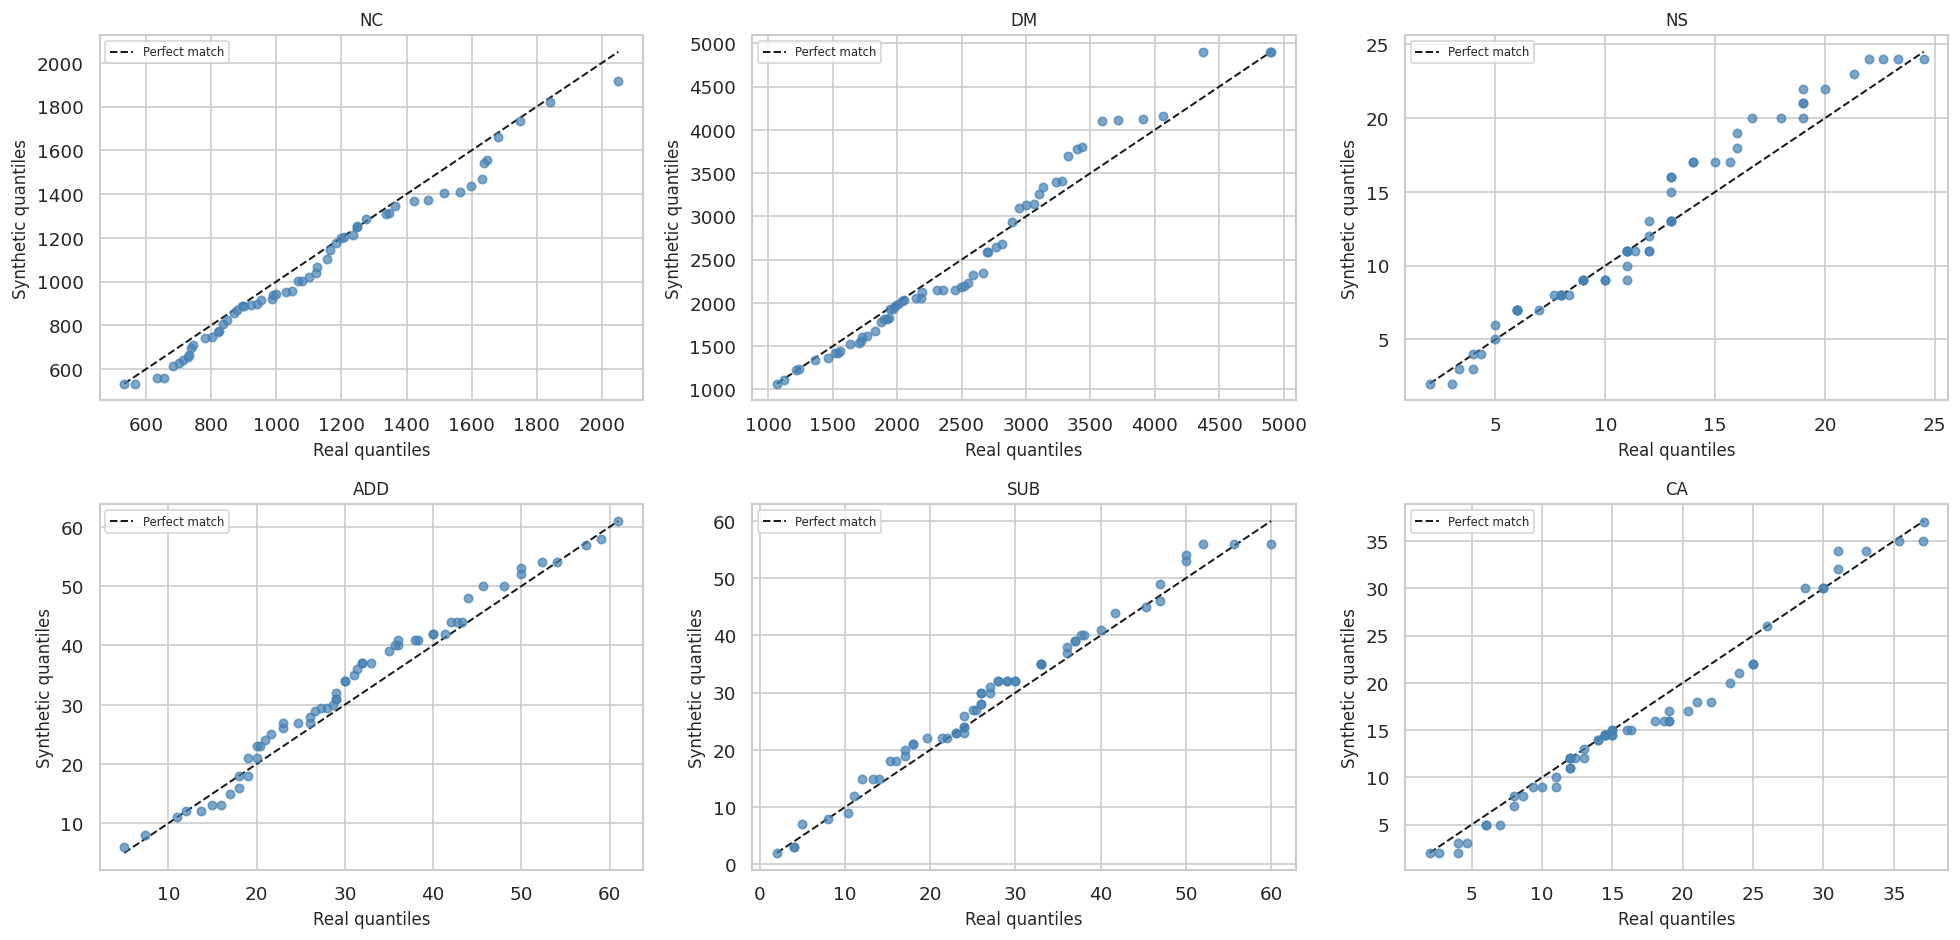

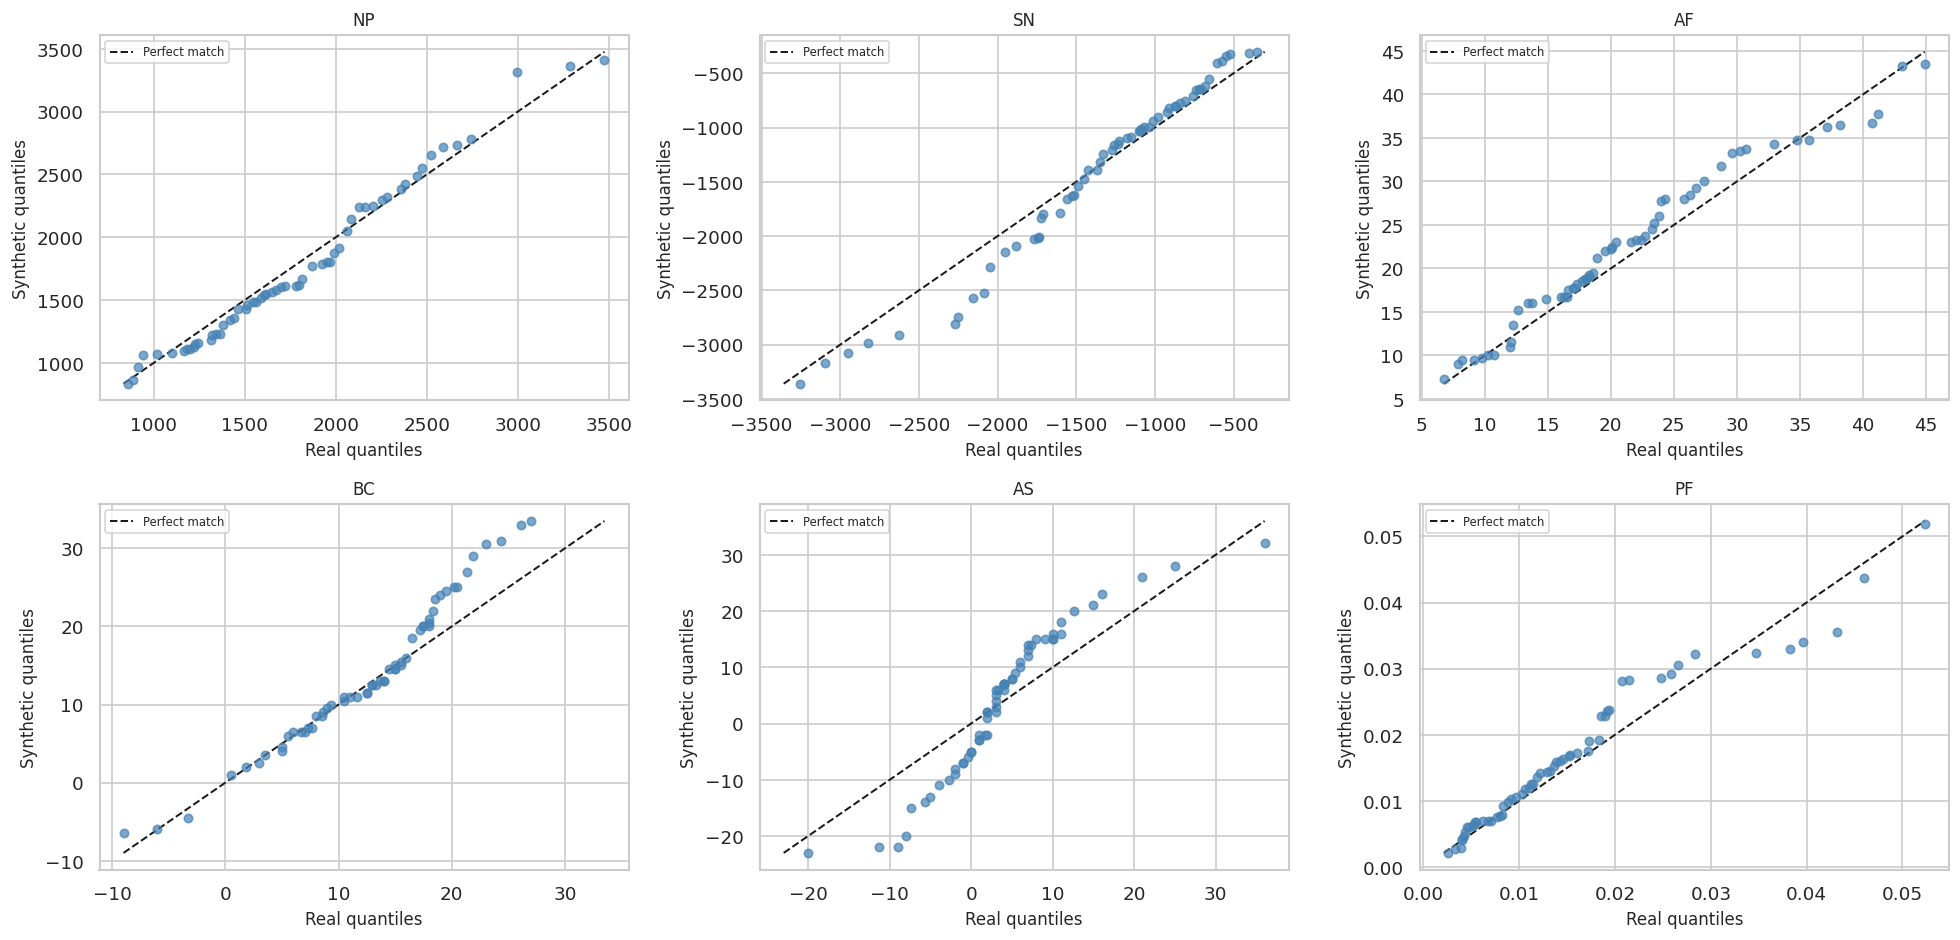

In [107]:
QQ_FEATURE_GROUPS = {
    'Raw Features': FEATURE_COLUMNS,
    'Derived Features': DERIVED_FEATURES
}
df_train_vis = df_train_full[df_train_full['Label'] == 1]

for group_name, feature_list in QQ_FEATURE_GROUPS.items():
    ncols = 3
    nrows = int(np.ceil(len(feature_list) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 4 * nrows))
    axes = np.array(axes).ravel()

    for i, f in enumerate(feature_list):
        ax = axes[i]
        real_sorted = np.sort(df_train_vis[f].values)
        syn_sorted  = np.sort(df_selected_full[f].values)

        # Interpolate to common quantile grid
        quantiles = np.linspace(0, 1, min(len(real_sorted), len(syn_sorted)))
        real_q = np.quantile(real_sorted, quantiles)
        syn_q  = np.quantile(syn_sorted,  quantiles)

        ax.scatter(real_q, syn_q, color='steelblue', alpha=0.7, s=25, zorder=3)

        # Perfect-match reference line
        lo = min(real_q.min(), syn_q.min())
        hi = max(real_q.max(), syn_q.max())
        ax.plot([lo, hi], [lo, hi], 'k--', lw=1.2, label='Perfect match')

        ax.set_title(f, fontsize=10)
        ax.set_xlabel('Real quantiles')
        ax.set_ylabel('Synthetic quantiles')
        ax.legend(fontsize=7)

    for j in range(len(feature_list), len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.savefig(GAN_FIGURES / f'{group_name}_syn_real_qq_plots.png')
    plt.show()


#### 2.6.3 Correlation Matrix Heatmaps

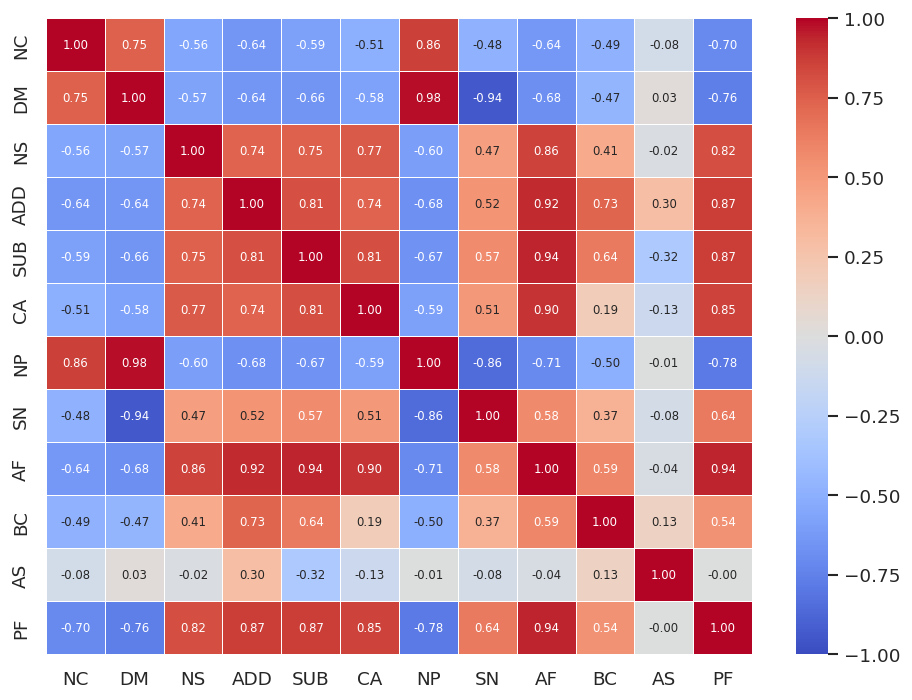

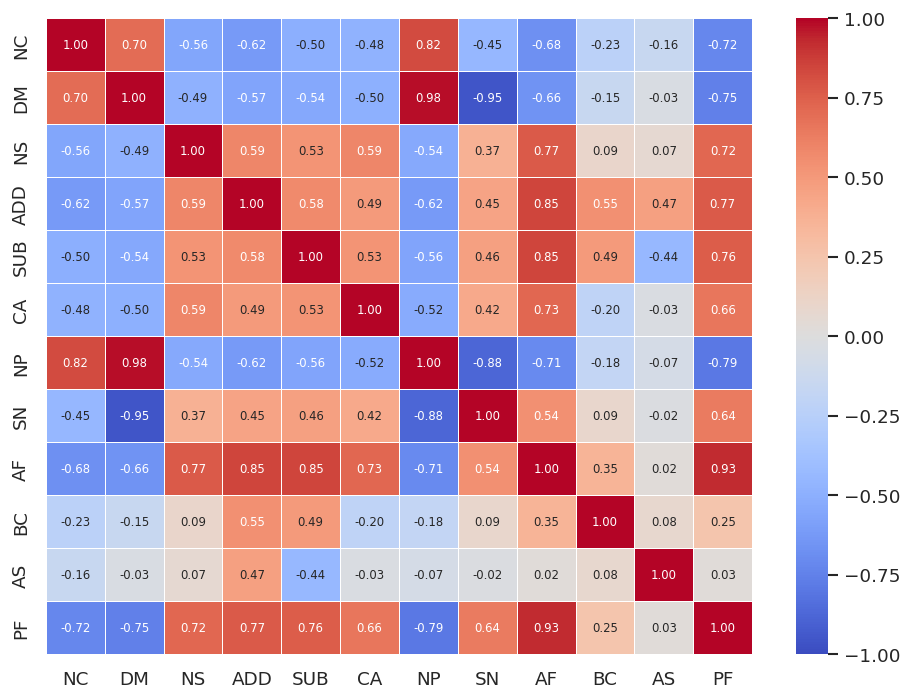

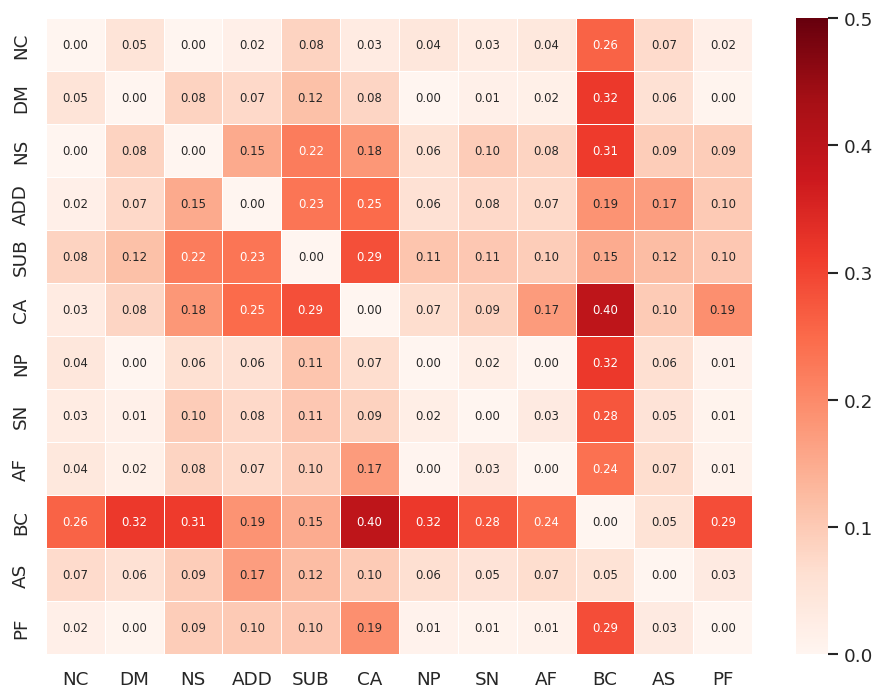

In [112]:
ALL_FEATURES = FEATURE_COLUMNS + DERIVED_FEATURES

corr_real = df_train_full[df_train_full['Label'] == 1][ALL_FEATURES].corr()
corr_syn  = df_selected_full[ALL_FEATURES].corr()
corr_diff = (corr_syn - corr_real).abs()

# Common heatmap settings for correlation matrices
kw = dict(
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    linewidths=0.3,
    annot_kws={'size': 7}
)

# ---- 1. Real Minority Correlation Matrix ----
plt.figure(figsize=(8, 6))
sns.heatmap(corr_real, **kw)
plt.tight_layout()
plt.savefig(GAN_FIGURES / 'real_minority_correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()


# ---- 2. Synthetic Correlation Matrix ----
plt.figure(figsize=(8, 6))
sns.heatmap(corr_syn, **kw)
plt.tight_layout()
plt.savefig(GAN_FIGURES / 'synthetic_correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()


# ---- 3. Absolute Difference Correlation Matrix ----
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_diff,
    annot=True,
    fmt='.2f',
    cmap='Reds',
    vmin=0,
    vmax=0.5,
    linewidths=0.3,
    annot_kws={'size': 7}
)
plt.tight_layout()
plt.savefig(GAN_FIGURES / 'correlation_difference_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

#### 2.6.4 Distribution Check Summary

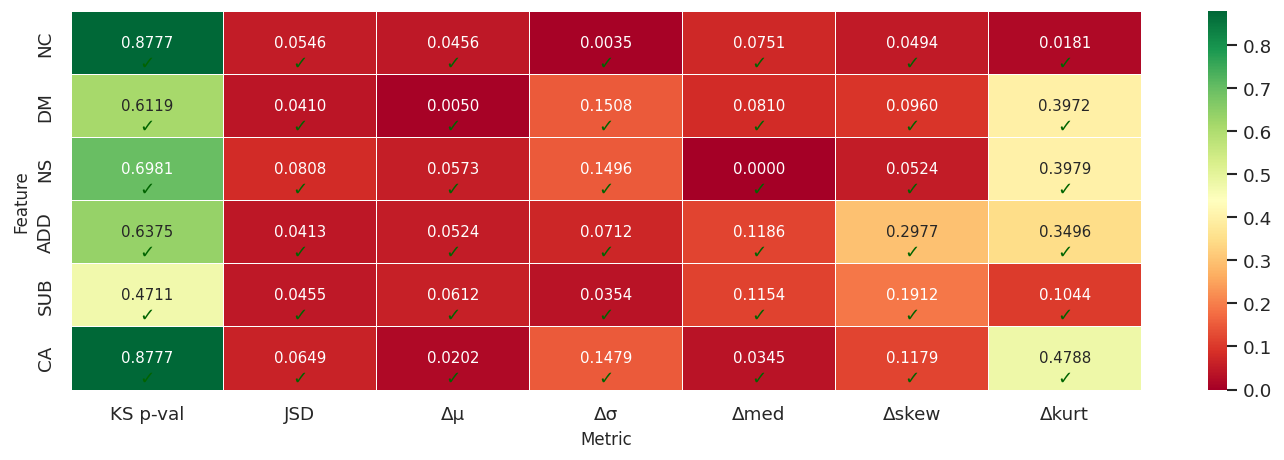

In [109]:
if df_dist_results is not None:
    metrics   = ['KS_p', 'JSD', 'delta_mu', 'delta_std', 'delta_med', 'delta_skew', 'delta_kurt']
    thresholds = {
        'KS_p'      : (DIST_THRESHOLDS['ks_pval'], True),
        'JSD'       : (DIST_THRESHOLDS['JSD_THRESHOLD'], False),
        'delta_mu'  : (DIST_THRESHOLDS['T_mu'],   False),
        'delta_std' : (DIST_THRESHOLDS['T_sigma'], False),
        'delta_med' : (DIST_THRESHOLDS['T_med'],   False),
        'delta_skew': (DIST_THRESHOLDS['T_skew'],  False),
        'delta_kurt': (DIST_THRESHOLDS['T_kurt'],  False),
    }
    labels = ['KS p-val', 'JSD', 'Δμ', 'Δσ', 'Δmed', 'Δskew', 'Δkurt']

    heat_val  = df_dist_results.set_index('feature')[metrics]

    # Build pass/fail mask
    pass_mask = pd.DataFrame(index=heat_val.index, columns=metrics)
    for m, (thr, higher) in thresholds.items():
        if higher:
            pass_mask[m] = heat_val[m] > thr
        else:
            pass_mask[m] = heat_val[m] < thr

    fig, ax = plt.subplots(figsize=(12, 4))
    heat_display = heat_val.copy()
    heat_display.columns = labels

    sns.heatmap(
        heat_display.astype(float),
        ax=ax, annot=True, fmt='.4f',
        cmap='RdYlGn', linewidths=0.5, linecolor='white',
        annot_kws={'size': 9},
    )

    # Overlay ✓/✗ on each cell
    for row_i, feat in enumerate(heat_val.index):
        for col_j, m in enumerate(metrics):
            ok = pass_mask.loc[feat, m]
            ax.text(col_j + 0.5, row_i + 0.82, '✓' if ok else '✗',
                    ha='center', va='center', fontsize=11,
                    color='darkgreen' if ok else 'darkred', fontweight='bold')

    ax.set_xlabel('Metric')
    ax.set_ylabel('Feature')

    plt.tight_layout()
    plt.savefig(GAN_FIGURES / 'syn_real_distribution_check.png')
    plt.show()

### 2.7 Save GAN Data

The finalised splits—now featuring a selectively balanced training set alongside untouched, purely real validation and test sets—are exported to persistent storage. This ensures a clean, auditable hand-off to the predictive modeling pipeline.

In [111]:
df_val_full  = compute_derived(df_val)
df_test_full = compute_derived(df_test)

DATASETS_FILENAMES = {
    'train': PROCESSED_DATASET_DIR / 'train.csv',
    's_train': PROCESSED_DATASET_DIR / 's_train.csv',
    'val': PROCESSED_DATASET_DIR / 'val.csv',
    'test': PROCESSED_DATASET_DIR / 'test.csv'
}

# Real Train Data only (both labels 0 and 1)
df_train_full.drop(columns=["is_synthetic"]).to_csv(DATASETS_FILENAMES['train'], index=False)

# Synthetic Train Data (label 1 only)
df_selected_full.drop(columns=["is_synthetic"]).to_csv(DATASETS_FILENAMES['s_train'], index=False)

# Validation and Test Data
df_val_full.to_csv(DATASETS_FILENAMES['val'],   index=False)
df_test_full.to_csv(DATASETS_FILENAMES['test'], index=False)

print(f'Files saved to {PROCESSED_DATASET_DIR.relative_to(ROOT_DIR)}:')
print(f'  {DATASETS_FILENAMES['train'].relative_to(ROOT_DIR)}    — {len(df_train_full)} rows (real only, labels 0 and 1)')
print(f'  {DATASETS_FILENAMES['s_train'].relative_to(ROOT_DIR)}  — {len(df_selected_full[df_selected_full["Label"] == 1])} rows (synthetic only, label 1)')
print(f'  {DATASETS_FILENAMES['val'].relative_to(ROOT_DIR)}      — {len(df_val_full)} rows (real only)')
print(f'  {DATASETS_FILENAMES['test'].relative_to(ROOT_DIR)}     — {len(df_test_full)} rows (real only)')


Files saved to datasets/processed:
  datasets/processed/train.csv    — 250 rows (real only, labels 0 and 1)
  datasets/processed/s_train.csv  — 58 rows (synthetic only, label 1)
  datasets/processed/val.csv      — 54 rows (real only)
  datasets/processed/test.csv     — 54 rows (real only)


## 3.0 Model Training and Evaluation

These sections compare the TRTR (Train-Real-Test-Real) and TRSTR (Train-Real-Synthetic-Test-Real) methodologies.

### 3.1 TRSTR vs TRTR Evaluation Pipeline

**Strategy:** This notebook compares a model trained on Real-only data (TRTR) versus Real + Synthetic data (TRSTR).

**Pipeline:**
1. Hyperparameter tuning
2. Cross-validation comparisons
3. Outlier fold investigation
4. Final test set evaluation
5. Feature importance analysis
6. Deployment CSV export


#### 3.1.1 Configs

In [ ]:
# Features that signal missing/incomplete data.
# The tree may still split on these (they carry real signal),
# but we exclude them from diagnostic z-score severity so that
# "timed out" is never conflated with "performed poorly".
INCOMPLETE_FLAGS = {
    "NC_incomplete", "DM_incomplete", "NS_incomplete",
    "ADD_incomplete", "SUB_incomplete", "CA_incomplete"
}

FUNA_DB_RAW_FEATURES: List[str] = FEATURE_COLUMNS + list(INCOMPLETE_FLAGS)
FUNA_DB_DIAGNOSTIC_FEATURES: List[str] = FUNA_DB_RAW_FEATURES + DERIVED_FEATURES

PARAM_GRID = {
    # CF in [0.10, 0.50]; sampled because confidence factor is continuous.
    'conf_fact':        np.round(np.arange(0.10, 0.51, 0.05), 2).tolist(),
    # n_min in {x | x in N, 10 <= x <= 50}
    'min_samples_leaf': list(range(10, 51)),
    # d_max in {x | x in N, 5 <= x <= 15}
    'max_depth':        list(range(5, 16)),
}

THRESHOLDS = np.arange(0.35, 0.76, 0.05).round(2)

N_JOBS = min(os.cpu_count() or 1, 12)
JOBLIB_BACKEND = 'loky'
GRID_SEARCH_OUTPUT_DIR = ROOT_DIR / 'outputs' / 'grid_search'
GRID_SEARCH_EXPORT_COLS = [
    'fbeta', 'recall', 'precision', 'f1', 'accuracy', 'auc', 'rmse',
    *PARAM_GRID.keys(), 'tree_depth', 'tree_leaves'
]
VALIDATION_SELECTION_METRIC_COLS = ['fbeta', 'recall', 'precision', 'f1', 'accuracy']
BEST_SELECTION_SORT_COLS = [
    *VALIDATION_SELECTION_METRIC_COLS,
]
TIE_RESOLUTION_SORT_COLS = [
    'cv_mean_fbeta', 'cv_mean_recall', 'cv_mean_precision', 'cv_mean_f1', 'cv_mean_accuracy',
    *PARAM_GRID.keys(), 'tree_depth', 'tree_leaves'
]

#### 3.1.2 Helper Functions

In [ ]:
def split_xy(df: pd.DataFrame, label_col: str = 'Label'):
    X = df[FUNA_DB_DIAGNOSTIC_FEATURES]
    y = df[label_col]
    return X, y

def get_preds(tree, X: pd.DataFrame) -> List[int]:
    return [int(pred) for pred in tree.predict(X)]

def get_probs(tree, X: pd.DataFrame) -> np.ndarray:
    """Predict probability of the At-Risk class from reached leaf distributions."""
    return tree.predict_proba(X, positive_class=1)

def probs_to_preds(probs: List[float], threshold: float) -> List[int]:
    return [1 if p >= threshold else 0 for p in probs]

def safe_roc_auc(y_true, probs) -> float:
    y_numeric = np.asarray(y_true).astype(int)
    if len(np.unique(y_numeric)) < 2:
        return np.nan
    return roc_auc_score(y_numeric, probs)

def compute_metrics(y_true, preds, probs=None) -> dict:
    y_numeric = np.asarray(y_true).astype(int)
    metrics = {
        'f1':        f1_score(y_numeric, preds, zero_division=0),
        'fbeta':     fbeta_score(y_numeric, preds, beta=2, zero_division=0),
        'recall':    recall_score(y_numeric, preds, zero_division=0),
        'precision': precision_score(y_numeric, preds, zero_division=0),
        'accuracy':  accuracy_score(y_numeric, preds),
    }
    if probs is not None:
        metrics['auc'] = safe_roc_auc(y_numeric, probs)
        metrics['rmse'] = np.sqrt(mean_squared_error(y_numeric, probs))
    return metrics

def run_cv(X_train: pd.DataFrame, y_train: pd.Series, label: str,
           best_params: dict,
           n_real: Optional[int] = None, threshold: Optional[float] = None) -> tuple[dict, list[dict]]:

    n_splits = 5
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    cv_f1, cv_fbeta, cv_recall, cv_precision, cv_accuracy = [], [], [], [], []
    cv_auc, cv_rmse = [], []
    fold_records = []

    if n_real is not None:
        X_real  = X_train.iloc[:n_real].reset_index(drop=True)
        y_real  = y_train.iloc[:n_real].reset_index(drop=True)
        X_synth = X_train.iloc[n_real:].reset_index(drop=True)
        y_synth = y_train.iloc[n_real:].reset_index(drop=True)
    else:
        X_real, y_real = X_train.reset_index(drop=True), y_train.reset_index(drop=True)
        X_synth, y_synth = X_train.iloc[:0], y_train.iloc[:0]

    print(f'\nStarting 5-Fold Cross-Validation [{label}]...')
    if n_real is not None:
        print(f'  (folding over {len(X_real)} real samples; '
              f'{len(X_synth)} synthetic rows pinned to every train fold)')

    for fold, (train_index, val_index) in enumerate(skf.split(X_real, y_real), 1):

        X_val_fold = X_real.iloc[val_index]
        y_val_fold = y_real.iloc[val_index]

        X_trn_fold = pd.concat([X_real.iloc[train_index], X_synth], ignore_index=True)
        y_trn_fold = pd.concat([y_real.iloc[train_index], y_synth], ignore_index=True)

        tree = C45DecisionTree(**best_params, feature_domain_mapping=FUNA_DB_DOMAIN_MAPPING)
        tree.fit(X_trn_fold, y_trn_fold,
                 raw_features=FUNA_DB_RAW_FEATURES)

        if threshold is not None:
            probs_val = get_probs(tree, X_val_fold)
            preds     = probs_to_preds(probs_val, threshold)
            m         = compute_metrics(y_val_fold, preds, probs_val)
        else:
            preds = get_preds(tree, X_val_fold)
            probs = get_probs(tree, X_val_fold)
            m     = compute_metrics(y_val_fold, preds, probs)

        cv_f1.append(m['f1'])
        cv_fbeta.append(m['fbeta'])
        cv_recall.append(m['recall'])
        cv_precision.append(m['precision'])
        cv_accuracy.append(m['accuracy'])
        cv_auc.append(m['auc'])
        cv_rmse.append(m['rmse'])

        fold_records.append({
            'fold': fold,
            'recall': m['recall'],
            'fbeta': m['fbeta'],
            'auc': m['auc'],
            'rmse': m['rmse'],
            'tree_depth': tree.get_depth(),
            'tree_leaves': tree.get_leaves_num(),
            'n_train':       len(X_trn_fold),
            'class_0_train': int((y_trn_fold == 0).sum()),
            'class_1_train': int((y_trn_fold == 1).sum()),
            'n_val':         len(X_val_fold),
            'class_0_val':   int((y_val_fold == 0).sum()),
            'class_1_val':   int((y_val_fold == 1).sum()),
        })

        print(f'  Fold {fold}: F1={m["f1"]:.4f}, F2={m["fbeta"]:.4f}, Recall={m["recall"]:.4f}, AUC={m["auc"]:.4f}, RMSE={m["rmse"]:.4f}')

    aggregated = {
        'mean_f1': np.mean(cv_f1), 'std_f1': np.std(cv_f1),
        'mean_fbeta': np.mean(cv_fbeta), 'std_fbeta': np.std(cv_fbeta),
        'mean_recall': np.mean(cv_recall), 'std_recall': np.std(cv_recall),
        'mean_precision': np.mean(cv_precision), 'std_precision': np.std(cv_precision),
        'mean_accuracy': np.mean(cv_accuracy), 'std_accuracy': np.std(cv_accuracy),
        'mean_auc': np.nanmean(cv_auc), 'std_auc': np.nanstd(cv_auc),
        'mean_rmse': np.mean(cv_rmse), 'std_rmse': np.std(cv_rmse),
    }

    return aggregated, fold_records

def print_cv_results(label: str, metrics: dict, threshold: Optional[float] = None):
    print(f'\n=== Cross-Validation Performance [{label}] (5-Fold) ===')
    print(f'  Recall:    {metrics["mean_recall"]:.4f} +/- {metrics["std_recall"]:.4f}')
    print(f'  Precision: {metrics["mean_precision"]:.4f} +/- {metrics["std_precision"]:.4f}')
    print(f'  F1-Score:  {metrics["mean_f1"]:.4f} +/- {metrics["std_f1"]:.4f}')
    print(f'  F2-Score:  {metrics["mean_fbeta"]:.4f} +/- {metrics["std_fbeta"]:.4f}')
    print(f'  Accuracy:  {metrics["mean_accuracy"]:.4f} +/- {metrics["std_accuracy"]:.4f}')
    print(f'  AUC-ROC:   {metrics["mean_auc"]:.4f} +/- {metrics["std_auc"]:.4f}')
    print(f'  RMSE:      {metrics["mean_rmse"]:.4f} +/- {metrics["std_rmse"]:.4f}')
    if threshold is not None:
        print(f'\n  Note: Metrics evaluated at threshold = {threshold}')

def print_variance_inspection(label: str, fold_records: list[dict]):
    df = pd.DataFrame(fold_records)
    mean_recall = df['recall'].mean()
    std_recall  = df['recall'].std()

    print(f'\n--- Fold Variance Inspection [{label}] ---')
    print(f'{"Fold":>5} {"N_train":>8} {"C0_tr":>6} {"C1_tr":>6} '
          f'{"N_val":>6} {"C0_val":>7} {"C1_val":>7} '
          f'{"Depth":>6} {"Leaves":>7} {"Recall":>8} {"F2":>8} {"Flag"}')
    print('-' * 95)

    for _, row in df.iterrows():
        flag = (
            ' HIGH' if row['recall'] > mean_recall + std_recall else
            ' LOW' if row['recall'] < mean_recall - std_recall else
            ''
        )
        print(f'{int(row["fold"]):>5} {int(row["n_train"]):>8} {int(row["class_0_train"]):>6} '
              f'{int(row["class_1_train"]):>6} {int(row["n_val"]):>6} '
              f'{int(row["class_0_val"]):>7} {int(row["class_1_val"]):>7} '
              f'{int(row["tree_depth"]):>6} {int(row["tree_leaves"]):>7} '
              f'{row["recall"]:>8.4f} {row["fbeta"]:>8.4f}{flag}')

    print(f'\n  Recall range : {df["recall"].min():.4f} - {df["recall"].max():.4f}')
    print(f'  Recall mean  : {mean_recall:.4f} +/- {std_recall:.4f}')

    corr_c1    = df['class_1_train'].corr(df['recall'])
    corr_depth = df['tree_depth'].corr(df['recall'])
    print(f'\n  Correlation: class_1_train vs recall = {corr_c1:+.3f}')
    print(f'  Correlation: tree_depth     vs recall = {corr_depth:+.3f}')
    if abs(corr_c1) > 0.6:
        print('  Strong correlation with positive-class count in training fold.')
        print('    Synthetic data may not be uniformly covering all subgroups.')

def iter_param_grid(param_grid: dict):
    keys = list(param_grid.keys())
    for values in product(*(param_grid[k] for k in keys)):
        yield dict(zip(keys, values))


### 3.2 Load Datasets and Prepare Training Sets

In [ ]:
print('Loading 70/15/15 Datasets...')

r_train = pd.read_csv(PROCESSED_DATASET_DIR / "train.csv")
s_train = pd.read_csv(PROCESSED_DATASET_DIR / "s_train.csv")
val_df  = pd.read_csv(PROCESSED_DATASET_DIR / "val.csv")
test_df = pd.read_csv(PROCESSED_DATASET_DIR / "test.csv")

train_trtr = r_train.copy()                                     # TRTR: real only
train_tstr = pd.concat([r_train, s_train], ignore_index=True)  # TSTR: real + synthetic

print(f'TRTR Train shape (Real 70%):         {train_trtr.shape}')
print(f'TSTR Train shape (Real + Synth):     {train_tstr.shape}')
print(f'Validation shape (Real 15%):         {val_df.shape}')
print(f'Test shape (Real 15%):               {test_df.shape}')

print(f'\nSynthetic data class distribution:')
print(s_train['Label'].value_counts().rename({0: 'Typical (0)', 1: 'At-Risk (1)'}).to_string())

X_train_trtr, y_train_trtr = split_xy(train_trtr)
X_train_tstr, y_train_tstr = split_xy(train_tstr)
X_val,  y_val  = split_xy(val_df)
X_test, y_test = split_xy(test_df)

### 3.3 Hyperparameter and Threshold Search

This section runs both evaluation paths in one place:
1. **No-threshold path**: selects hyperparameters using the tree's native class predictions.
2. **Thresholded path**: selects hyperparameters and a validation threshold using raw At-Risk probabilities.

Both paths are retained so that cross-validation and final test results can be compared directly.


#### 3.3.1 Search Helpers

In [ ]:
def _evaluate_candidate(candidate_no, params, X_train, y_train, X_val, y_val, thresholded: bool = False):
    tree = C45DecisionTree(**params, feature_domain_mapping=FUNA_DB_DOMAIN_MAPPING)
    tree.fit(X_train, y_train, raw_features=FUNA_DB_RAW_FEATURES)

    val_probs = get_probs(tree, X_val)
    tree_depth = tree.get_depth()
    tree_leaves = tree.get_leaves_num()

    if thresholded:
        candidate_records = []
        for threshold in THRESHOLDS:
            preds = probs_to_preds(val_probs, threshold)
            metrics = compute_metrics(y_val, preds, val_probs)
            candidate_records.append({
                **params,
                'candidate_no': candidate_no,
                'threshold': threshold,
                'f1': metrics['f1'],
                'fbeta': metrics['fbeta'],
                'recall': metrics['recall'],
                'precision': metrics['precision'],
                'accuracy': metrics['accuracy'],
                'auc': metrics['auc'],
                'rmse': metrics['rmse'],
                'tree_depth': tree_depth,
                'tree_leaves': tree_leaves,
            })
        return candidate_records

    preds = get_preds(tree, X_val)
    metrics = compute_metrics(y_val, preds, val_probs)
    return {
        **params,
        'candidate_no': candidate_no,
        'f1': metrics['f1'],
        'fbeta': metrics['fbeta'],
        'recall': metrics['recall'],
        'precision': metrics['precision'],
        'accuracy': metrics['accuracy'],
        'auc': metrics['auc'],
        'rmse': metrics['rmse'],
        'tree_depth': tree_depth,
        'tree_leaves': tree_leaves,
    }

def _as_python_scalar(value):
    return value.item() if hasattr(value, 'item') else value

def _grid_search_export_cols(thresholded: bool):
    threshold_col = ['threshold'] if thresholded else []
    return [
        'fbeta', 'recall', 'precision', 'f1', 'accuracy', 'auc', 'rmse',
        *threshold_col, *PARAM_GRID.keys(), 'tree_depth', 'tree_leaves'
    ]

def save_grid_search_results(search_df, label: str, thresholded: bool):
    GRID_SEARCH_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    suffix = 'thresholded' if thresholded else 'no_threshold'
    output_path = GRID_SEARCH_OUTPUT_DIR / f'{label.lower()}_{suffix}_grid_search_results.csv'
    search_df[_grid_search_export_cols(thresholded)].to_csv(output_path, index=False)
    print(f'[{label} | {suffix}] Saved full grid search results ({len(search_df)} rows): {output_path}')
    return output_path

def _params_from_row(row):
    params = {k: _as_python_scalar(row[k]) for k in PARAM_GRID.keys()}
    params['min_samples_leaf'] = int(params['min_samples_leaf'])
    params['max_depth'] = int(params['max_depth'])
    return params

def _validation_best_ties(search_df, thresholded: bool):
    top_row = search_df.iloc[0]
    tied_mask = np.logical_and.reduce([
        np.isclose(search_df[col], top_row[col])
        for col in VALIDATION_SELECTION_METRIC_COLS
    ])

    threshold_cols = ['threshold'] if thresholded else []
    tied_cols = [
        *VALIDATION_SELECTION_METRIC_COLS,
        *threshold_cols,
        *PARAM_GRID.keys(),
        'tree_depth',
        'tree_leaves'
    ]
    subset_cols = [*threshold_cols, *PARAM_GRID.keys(), 'tree_depth', 'tree_leaves']
    return search_df.loc[tied_mask, tied_cols].drop_duplicates(
        subset=subset_cols
    ).reset_index(drop=True)

def _evaluate_tied_candidate(row, X_train, y_train, label, thresholded: bool, n_real=None):
    params = _params_from_row(row)
    threshold = float(row['threshold']) if thresholded else None

    cv_metrics, _ = run_cv(
        X_train, y_train, label, params,
        n_real=n_real,
        threshold=threshold
    )

    record = {
        **{f'val_{col}': float(row[col]) for col in VALIDATION_SELECTION_METRIC_COLS},
        **{f'cv_{key}': float(value) for key, value in cv_metrics.items()},
        **params,
        'tree_depth': int(row['tree_depth']),
        'tree_leaves': int(row['tree_leaves']),
    }
    if thresholded:
        record['threshold'] = threshold
    return record

def resolve_validation_ties_with_cv(search_df, X_train, y_train, label, thresholded: bool, n_real=None):
    suffix = 'thresholded' if thresholded else 'no_threshold'
    tied_df = _validation_best_ties(search_df, thresholded)
    print(f'\n[{label} | {suffix}] Validation-best tied candidates: {len(tied_df)}')

    tie_records = []
    for candidate_no, (_, row) in enumerate(tied_df.iterrows(), 1):
        threshold_text = f'threshold={float(row["threshold"]):.2f}, ' if thresholded else ''
        print(f'\n[{label} | {suffix}] Tie candidate {candidate_no}/{len(tied_df)}: '
              f'{threshold_text}params={_params_from_row(row)}')
        tie_records.append(_evaluate_tied_candidate(
            row, X_train, y_train, label, thresholded=thresholded, n_real=n_real
        ))

    sort_cols = [
        'cv_mean_fbeta', 'cv_mean_recall', 'cv_mean_precision', 'cv_mean_f1', 'cv_mean_accuracy',
        *(['threshold'] if thresholded else []),
        *PARAM_GRID.keys(), 'tree_depth', 'tree_leaves'
    ]
    tie_results_df = pd.DataFrame(tie_records).sort_values(
        by=sort_cols,
        ascending=False,
    )

    GRID_SEARCH_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    output_path = GRID_SEARCH_OUTPUT_DIR / f'{label.lower()}_{suffix}_validation_tie_cv_results.csv'
    tie_results_df.to_csv(output_path, index=False)
    print(f'[{label} | {suffix}] Saved validation-tie CV results ({len(tie_results_df)} rows): {output_path}')

    best_row = tie_results_df.iloc[0]
    best_params = _params_from_row(best_row)
    best_threshold = float(best_row['threshold']) if thresholded else None

    print(f'\n[{label} | {suffix}] Selected after validation-tie CV resolution:')
    print(f'  Params: {best_params}')
    if thresholded:
        print(f'  Threshold: {best_threshold:.2f}')
    print(f'  CV F2={best_row["cv_mean_fbeta"]:.4f}, '
          f'CV Recall={best_row["cv_mean_recall"]:.4f}, '
          f'CV Precision={best_row["cv_mean_precision"]:.4f}')

    if thresholded:
        return best_params, best_threshold, tie_results_df
    return best_params, tie_results_df

def tune_params(X_train, y_train, X_val, y_val, label: str, thresholded: bool = False):
    suffix = 'thresholded' if thresholded else 'no_threshold'
    candidates = list(enumerate(iter_param_grid(PARAM_GRID), 1))
    n_candidates = len(candidates)

    print(f'\n[{label} | {suffix}] Parallel search: {n_candidates} param combos')
    if thresholded:
        print(f'[{label} | {suffix}] Threshold grid: {THRESHOLDS.tolist()}')

    search_records = Parallel(
        n_jobs=N_JOBS,
        backend=JOBLIB_BACKEND,
        prefer='processes',
        verbose=10,
        batch_size=1,
        pre_dispatch='2*n_jobs',
    )(
        delayed(_evaluate_candidate)(candidate_no, params, X_train, y_train, X_val, y_val, thresholded)
        for candidate_no, params in candidates
    )

    if thresholded:
        search_records = [row for candidate_rows in search_records for row in candidate_rows]

    if not search_records:
        raise RuntimeError(f'[{label} | {suffix}] No search records were generated.')

    search_df = pd.DataFrame(search_records).sort_values(
        by=BEST_SELECTION_SORT_COLS,
        ascending=False,
    )

    save_grid_search_results(search_df, label, thresholded=thresholded)

    best_row = search_df.iloc[0]
    best_params = _params_from_row(best_row)
    best_threshold = float(best_row['threshold']) if thresholded else None

    best_metrics = {
        'f1': float(best_row['f1']),
        'fbeta': float(best_row['fbeta']),
        'recall': float(best_row['recall']),
        'precision': float(best_row['precision']),
        'accuracy': float(best_row['accuracy']),
    }

    print(f'\n[{label} | {suffix}] Top validation candidates:')
    print(search_df[_grid_search_export_cols(thresholded)].head(10).to_string(index=False))

    print(f'\n[{label} | {suffix}] Selected validation setting:')
    print(f'  Params: {best_params}')
    if thresholded:
        print(f'  Threshold: {best_threshold:.2f}')
    print(f'  F2={best_metrics["fbeta"]:.4f}, '
          f'Recall={best_metrics["recall"]:.4f}, '
          f'Precision={best_metrics["precision"]:.4f}')

    if thresholded:
        return best_params, best_threshold, search_df
    return best_params, search_df


#### 3.3.2 Main Search

In [ ]:
print('\n' + '=' * 60)
print('PHASE 1: Hyperparameter Search — No Threshold and Thresholded')
print('=' * 60)

print('\nSearch grid:')
for param_name, values in PARAM_GRID.items():
    print(f'  {param_name}: {values}')
print(f'  thresholds: {THRESHOLDS.tolist()}')
print(f'  parallel jobs: {N_JOBS} ({JOBLIB_BACKEND})')

# ---- A. No-threshold validation search ----
BEST_PARAMS_TRTR_NT, SEARCH_RESULTS_TRTR_NT = tune_params(
    X_train_trtr, y_train_trtr, X_val, y_val, 'TRTR', thresholded=False
)
BEST_PARAMS_TSTR_NT, SEARCH_RESULTS_TSTR_NT = tune_params(
    X_train_tstr, y_train_tstr, X_val, y_val, 'TSTR', thresholded=False
)

BEST_PARAMS_TRTR_NT, TIE_RESULTS_TRTR_NT = resolve_validation_ties_with_cv(
    SEARCH_RESULTS_TRTR_NT, X_train_trtr, y_train_trtr, 'TRTR', thresholded=False
)
BEST_PARAMS_TSTR_NT, TIE_RESULTS_TSTR_NT = resolve_validation_ties_with_cv(
    SEARCH_RESULTS_TSTR_NT, X_train_tstr, y_train_tstr, 'TSTR', thresholded=False,
    n_real=len(r_train)
)

# ---- B. Thresholded validation search ----
BEST_PARAMS_TRTR_TH, BEST_THRESHOLD_TRTR, SEARCH_RESULTS_TRTR_TH = tune_params(
    X_train_trtr, y_train_trtr, X_val, y_val, 'TRTR', thresholded=True
)
BEST_PARAMS_TSTR_TH, BEST_THRESHOLD_TSTR, SEARCH_RESULTS_TSTR_TH = tune_params(
    X_train_tstr, y_train_tstr, X_val, y_val, 'TSTR', thresholded=True
)

BEST_PARAMS_TRTR_TH, BEST_THRESHOLD_TRTR, TIE_RESULTS_TRTR_TH = resolve_validation_ties_with_cv(
    SEARCH_RESULTS_TRTR_TH, X_train_trtr, y_train_trtr, 'TRTR', thresholded=True
)
BEST_PARAMS_TSTR_TH, BEST_THRESHOLD_TSTR, TIE_RESULTS_TSTR_TH = resolve_validation_ties_with_cv(
    SEARCH_RESULTS_TSTR_TH, X_train_tstr, y_train_tstr, 'TSTR', thresholded=True,
    n_real=len(r_train)
)

# Backward-compatible aliases used by later cells / deployment code.
BEST_PARAMS_TRTR = BEST_PARAMS_TRTR_TH
BEST_PARAMS_TSTR = BEST_PARAMS_TSTR_TH


### 3.4 TRTR vs TRSTR Cross-Validation

TSTR folds only over real samples; synthetic rows are pinned to every training fold

In [ ]:
print('\n' + '=' * 60)
print('PHASE 2: TRTR vs TSTR Cross-Validation — No Threshold and Thresholded')
print('=' * 60)

# ---- A. No-threshold CV ----
cv_metrics_trtr_nt, fold_records_trtr_nt = run_cv(
    X_train_trtr, y_train_trtr, 'TRTR | no_threshold', BEST_PARAMS_TRTR_NT
)
cv_metrics_tstr_nt, fold_records_tstr_nt = run_cv(
    X_train_tstr, y_train_tstr, 'TSTR | no_threshold', BEST_PARAMS_TSTR_NT,
    n_real=len(r_train)
)

print_cv_results('TRTR | no_threshold', cv_metrics_trtr_nt)
print_cv_results('TSTR | no_threshold', cv_metrics_tstr_nt)

# ---- B. Thresholded CV ----
cv_metrics_trtr_th, fold_records_trtr_th = run_cv(
    X_train_trtr, y_train_trtr, 'TRTR | thresholded', BEST_PARAMS_TRTR_TH,
    threshold=BEST_THRESHOLD_TRTR
)
cv_metrics_tstr_th, fold_records_tstr_th = run_cv(
    X_train_tstr, y_train_tstr, 'TSTR | thresholded', BEST_PARAMS_TSTR_TH,
    n_real=len(r_train),
    threshold=BEST_THRESHOLD_TSTR
)

print_cv_results('TRTR | thresholded', cv_metrics_trtr_th, BEST_THRESHOLD_TRTR)
print_cv_results('TSTR | thresholded', cv_metrics_tstr_th, BEST_THRESHOLD_TSTR)

# Backward-compatible aliases: use thresholded results as the selected deployment path.
cv_metrics_trtr, fold_records_trtr = cv_metrics_trtr_th, fold_records_trtr_th
cv_metrics_tstr, fold_records_tstr = cv_metrics_tstr_th, fold_records_tstr_th


#### 3.4.1 Side-by-side CV Summary

In [ ]:
print('\n' + '=' * 60)
print('PHASE 3: CV Summary Comparison — No Threshold and Thresholded')
print('=' * 60)

metrics_labels = [
    ('Recall',    'mean_recall',    'std_recall'),
    ('Precision', 'mean_precision', 'std_precision'),
    ('F1-Score',  'mean_f1',        'std_f1'),
    ('F2-Score',  'mean_fbeta',     'std_fbeta'),
    ('Accuracy',  'mean_accuracy',  'std_accuracy'),
    ('AUC-ROC',   'mean_auc',       'std_auc'),
    ('RMSE',      'mean_rmse',      'std_rmse'),
]

def print_cv_comparison_table(title, trtr_metrics, tstr_metrics):
    print(f'\n--- {title} ---')
    print(f'\n{"Metric":>12}  {"TRTR (mean+/-std)":>26}  {"TSTR (mean+/-std)":>26}  {"D (TSTR-TRTR)":>15}')
    print('-' * 85)
    for name, mean_key, std_key in metrics_labels:
        trtr_val = trtr_metrics[mean_key]
        tstr_val = tstr_metrics[mean_key]
        delta    = tstr_val - trtr_val
        sign     = '+' if delta >= 0 else ''
        print(f'{name:>12}  '
              f'{trtr_val:.4f} +/- {trtr_metrics[std_key]:.4f}         '
              f'{tstr_val:.4f} +/- {tstr_metrics[std_key]:.4f}         '
              f'{sign}{delta:.4f}')

print_cv_comparison_table('No-threshold CV', cv_metrics_trtr_nt, cv_metrics_tstr_nt)
print_cv_comparison_table('Thresholded CV', cv_metrics_trtr_th, cv_metrics_tstr_th)


#### 3.4.2 Fold Variance Inspection

In [ ]:
print('\n' + '=' * 60)
print('PHASE 4: Fold Variance Inspection — No Threshold and Thresholded')
print('=' * 60)

print_variance_inspection('TRTR | no_threshold', fold_records_trtr_nt)
print_variance_inspection('TSTR | no_threshold', fold_records_tstr_nt)
print_variance_inspection('TRTR | thresholded', fold_records_trtr_th)
print_variance_inspection('TSTR | thresholded', fold_records_tstr_th)


##### 3.4.2.1 TRSTR Outlier Fold Investigation

Dynamically identifies the lowest-recall TSTR fold and inspects the real at-risk cases in its val split to surface subgroups the synthetic data may not be covering well.

In [ ]:
# Detect outlier fold from the thresholded TSTR CV path used as the deployment-oriented setting.
tstr_fold_df     = pd.DataFrame(fold_records_tstr_th)
outlier_fold_no  = int(tstr_fold_df.loc[tstr_fold_df['recall'].idxmin(), 'fold'])
outlier_recall   = tstr_fold_df.loc[tstr_fold_df['recall'].idxmin(), 'recall']
mean_tstr_recall = tstr_fold_df['recall'].mean()

print('\n' + '=' * 60)
print(f'PHASE 4b: Thresholded TSTR Fold {outlier_fold_no} Outlier Investigation')
print('=' * 60)

print(f'\n  Outlier fold: Fold {outlier_fold_no} '
      f'(recall={outlier_recall:.4f} vs mean={mean_tstr_recall:.4f})')

# Re-run the same split used in Phase 2 to recover val indices.
# CV in Phase 2 folded over real samples only — replicate that here.
X_real_inv = X_train_tstr.iloc[:len(r_train)].reset_index(drop=True)
y_real_inv = y_train_tstr.iloc[:len(r_train)].reset_index(drop=True)

skf_inv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for fold_i, (_, val_idx) in enumerate(skf_inv.split(X_real_inv, y_real_inv), 1):
    if fold_i == outlier_fold_no:
        outlier_val_idx = val_idx
        break

# Recover real val rows for the outlier fold
real_val_fold_df = r_train.iloc[outlier_val_idx].copy()
score_cols       = ["NC", "DM", "NS", "ADD", "SUB", "CA"]

print(f'\n  Val split composition for Fold {outlier_fold_no}:')
print(f'    Real samples: {len(real_val_fold_df)}  '
      f'(class 0: {int((real_val_fold_df["Label"]==0).sum())}  '
      f'class 1: {int((real_val_fold_df["Label"]==1).sum())})')
print(f'    Synthetic samples: 0  (all synthetic pinned to train — Option A)')

real_pos_val = real_val_fold_df[real_val_fold_df['Label'] == 1]

if len(real_pos_val) > 0:
    print(f'\n  Real at-risk cases in Fold {outlier_fold_no} val (n={len(real_pos_val)}):')
    print(f'  {"Feature":>6} {"Mean":>8} {"Std":>8} {"Min":>8} {"Max":>8}')
    print('  ' + '-' * 44)
    for col in score_cols:
        if col in real_pos_val.columns:
            vals = real_pos_val[col]
            print(f'  {col:>6} {vals.mean():>8.3f} {vals.std():>8.3f} '
                  f'{vals.min():>8.3f} {vals.max():>8.3f}')

    real_pos_train = r_train.iloc[
        [i for i in range(len(r_train)) if i not in outlier_val_idx]
    ]
    real_pos_train = real_pos_train[real_pos_train['Label'] == 1]

    if len(real_pos_train) > 0:
        print(f'\n  Real at-risk cases in Fold {outlier_fold_no} training (n={len(real_pos_train)}):')
        print(f'  {"Feature":>6} {"Mean":>8} {"Std":>8} {"Min":>8} {"Max":>8}')
        print('  ' + '-' * 44)
        for col in score_cols:
            if col in real_pos_train.columns:
                vals = real_pos_train[col]
                print(f'  {col:>6} {vals.mean():>8.3f} {vals.std():>8.3f} '
                      f'{vals.min():>8.3f} {vals.max():>8.3f}')

    print(f'\n  If the val group has systematically different feature ranges,')
    print(f'  those subgroups are underrepresented in your synthetic data.')
else:
    print(f'\n  No real at-risk cases in Fold {outlier_fold_no} val split.')
    print(f'  Recall = 0 is expected — no positive examples to predict.')


### 3.5 Final Test Set Evaluation

Train on the full TRTR and TSTR training sets and evaluate both prediction modes on the same held-out real test set:
1. **No threshold**: uses the tree's native class prediction.
2. **Thresholded**: uses raw At-Risk probabilities and the validation-selected threshold.


In [ ]:
print('\n' + '=' * 60)
print('PHASE 5: Final Test Set Evaluation — No Threshold and Thresholded')
print('=' * 60)

TEST_RUNS = {
    'no_threshold': {
        'TRTR': {'params': BEST_PARAMS_TRTR_NT, 'threshold': None, 'X_train': X_train_trtr, 'y_train': y_train_trtr},
        'TSTR': {'params': BEST_PARAMS_TSTR_NT, 'threshold': None, 'X_train': X_train_tstr, 'y_train': y_train_tstr},
    },
    'thresholded': {
        'TRTR': {'params': BEST_PARAMS_TRTR_TH, 'threshold': BEST_THRESHOLD_TRTR, 'X_train': X_train_trtr, 'y_train': y_train_trtr},
        'TSTR': {'params': BEST_PARAMS_TSTR_TH, 'threshold': BEST_THRESHOLD_TSTR, 'X_train': X_train_tstr, 'y_train': y_train_tstr},
    }
}

test_results = {}
final_trees = {}

for mode, run_map in TEST_RUNS.items():
    print(f'\n--- {mode.upper()} TEST EVALUATION ---')
    test_results[mode] = {}
    final_trees[mode] = {}

    for label in ['TRTR', 'TSTR']:
        cfg = run_map[label]
        print(f'\n  [{label} | {mode}] Locked params: {cfg["params"]}')
        if cfg['threshold'] is not None:
            print(f'  [{label} | {mode}] Locked threshold: {cfg["threshold"]:.2f}')

        final_tree = C45DecisionTree(**cfg['params'], feature_domain_mapping=FUNA_DB_DOMAIN_MAPPING)
        final_tree.fit(cfg['X_train'], cfg['y_train'], raw_features=FUNA_DB_RAW_FEATURES)

        test_probs = get_probs(final_tree, X_test)
        if cfg['threshold'] is None:
            test_preds = get_preds(final_tree, X_test)
        else:
            test_preds = probs_to_preds(test_probs, cfg['threshold'])

        m = compute_metrics(y_test, test_preds, test_probs)
        test_results[mode][label] = m
        final_trees[mode][label] = final_tree

        print(f'\n  [{label} | {mode}] Test Set Results:')
        print(f'    Recall:    {m["recall"]:.4f}')
        print(f'    Precision: {m["precision"]:.4f}')
        print(f'    F1-Score:  {m["f1"]:.4f}')
        print(f'    F2-Score:  {m["fbeta"]:.4f}')
        print(f'    Accuracy:  {m["accuracy"]:.4f}')
        print(f'    AUC-ROC:   {m["auc"]:.4f}')
        print(f'    RMSE:      {m["rmse"]:.4f}')

# Compact side-by-side comparison for each mode
metrics_labels_test = [
    ('Recall',    'recall'),
    ('Precision', 'precision'),
    ('F1-Score',  'f1'),
    ('F2-Score',  'fbeta'),
    ('Accuracy',  'accuracy'),
    ('AUC-ROC',   'auc'),
    ('RMSE',      'rmse'),
]

for mode in ['no_threshold', 'thresholded']:
    print(f'\n--- {mode.upper()} TEST COMPARISON ---')
    print(f'{"Metric":>12} {"TRTR (test)":>14} {"TSTR (test)":>14} {"D (TSTR-TRTR)":>15}')
    print('-' * 58)
    for name, key in metrics_labels_test:
        trtr_val = test_results[mode]['TRTR'][key]
        tstr_val = test_results[mode]['TSTR'][key]
        delta    = tstr_val - trtr_val
        sign     = '+' if delta >= 0 else ''
        print(f'{name:>12}  {trtr_val:>12.4f}  {tstr_val:>12.4f}  {sign}{delta:.4f}')

# Direct no-threshold vs thresholded comparison per training condition
print(f'\n--- NO-THRESHOLD VS THRESHOLDED TEST COMPARISON ---')
for label in ['TRTR', 'TSTR']:
    print(f'\n[{label}]')
    print(f'{"Metric":>12} {"No threshold":>14} {"Thresholded":>14} {"D (TH-NT)":>12}')
    print('-' * 58)
    for name, key in metrics_labels_test:
        nt_val = test_results['no_threshold'][label][key]
        th_val = test_results['thresholded'][label][key]
        delta  = th_val - nt_val
        sign   = '+' if delta >= 0 else ''
        print(f'{name:>12}  {nt_val:>12.4f}  {th_val:>12.4f}  {sign}{delta:.4f}')

# CV vs Test consistency check
print(f'\n--- CV vs Test Consistency Check ---')
CV_BY_MODE = {
    'no_threshold': {'TRTR': cv_metrics_trtr_nt, 'TSTR': cv_metrics_tstr_nt},
    'thresholded': {'TRTR': cv_metrics_trtr_th, 'TSTR': cv_metrics_tstr_th},
}
for mode in ['no_threshold', 'thresholded']:
    for label in ['TRTR', 'TSTR']:
        cv_m = CV_BY_MODE[mode][label]
        test_m = test_results[mode][label]
        recall_drift = test_m['recall'] - cv_m['mean_recall']
        f2_drift     = test_m['fbeta']  - cv_m['mean_fbeta']
        sign_r = '+' if recall_drift >= 0 else ''
        sign_f = '+' if f2_drift     >= 0 else ''
        print(f'  [{label} | {mode}] Recall drift (test - CV mean): {sign_r}{recall_drift:.4f}  |  '
              f'F2 drift: {sign_f}{f2_drift:.4f}')
        if abs(recall_drift) > 0.10:
            print(f'    Recall drift > 0.10 -- possible overfitting or distribution mismatch.')

# Backward-compatible aliases: Phase 6 uses the selected thresholded TSTR tree.
results = test_results['thresholded']
tstr_final_tree = final_trees['thresholded']['TSTR']


### 3.6 Global Feature Importance Analysis

Uses the TRSTR final tree from Phase 5. Split into (a) incomplete flags and (b) task features to
answer two questions:
1. Are incomplete flags genuinely used as split criteria?
2. Which task features drive the tree's decisions?

In [ ]:
print('\n' + '=' * 60)
print('PHASE 6: Global Feature Importance (TRSTR tree)')
print('=' * 60)

importance = tstr_final_tree.get_feature_importance()

flag_importance = {k: v for k, v in importance.items() if k in INCOMPLETE_FLAGS}
task_importance = {k: v for k, v in importance.items() if k not in INCOMPLETE_FLAGS}

flag_importance = dict(sorted(flag_importance.items(), key=lambda x: x[1], reverse=True))
task_importance = dict(sorted(task_importance.items(), key=lambda x: x[1], reverse=True))

print('\n  Incomplete flag importance (are they used as split nodes?):')
if flag_importance:
    for feat, score in flag_importance.items():
        bar = '#' * int(score * 40)
        print(f'    {feat:<20} {score:.4f}  {bar}')
    total_flag_share = sum(flag_importance.values())
    print(f'\n  -> Flags account for {total_flag_share:.2%} of total tree importance.')
    if total_flag_share > 0.05:
        print('  [OK] Incomplete flags carry meaningful split weight -- retain them as features.')
    else:
        print('  [i]  Flags have negligible split weight -- the tree largely ignores them.')
else:
    print('    (none -- the tree did not split on any incomplete flag)')
    print('  [i]  Incomplete flags were never chosen as split nodes.')

print('\n  Task feature importance (excluding incomplete flags):')
for feat, score in task_importance.items():
    bar = '#' * int(score * 40)
    print(f'    {feat:<20} {score:.4f}  {bar}')


FLAG_IMPORTANCE_CUTOFF = 0.01

used_flags   = [f for f, s in flag_importance.items() if s >= FLAG_IMPORTANCE_CUTOFF]
unused_flags = [f for f, s in flag_importance.items() if s <  FLAG_IMPORTANCE_CUTOFF]

print('\n' + '=' * 60)
print('PHASE 6b: Deployment CSV Export')
print('=' * 60)

if not flag_importance:
    # Tree never split on any flag — drop all of them
    unused_flags = list(INCOMPLETE_FLAGS)
    used_flags   = []
elif not unused_flags:
    print('\n  All incomplete flags carry meaningful split weight.')
    print('  No columns dropped — deployment CSVs not generated.')
else:
    print(f'\n  Unused incomplete flags (importance < {FLAG_IMPORTANCE_CUTOFF:.0%}):')
    for f in unused_flags:
        print(f'    - {f}  (importance={flag_importance.get(f, 0.0):.4f})')
    if used_flags:
        print(f'\n  Retained incomplete flags (importance >= {FLAG_IMPORTANCE_CUTOFF:.0%}):')
        for f in used_flags:
            print(f'    + {f}  (importance={flag_importance.get(f, 0.0):.4f})')

# ── Save deployment CSVs whenever there are flags to drop ──
if unused_flags:
    cols_to_drop = [f for f in unused_flags if f in r_train.columns]
    dataset_map  = {
        "train":   r_train,
        "s_train": s_train,
        "val":     val_df,
        "test":    test_df,
    }
    print(f'\n  Dropping {len(cols_to_drop)} unused flag column(s): {cols_to_drop}')
    print(f'  Saving deployment CSVs...')
    for name, df in dataset_map.items():
        drop_present = [c for c in cols_to_drop if c in df.columns]
        if not drop_present:
            print(f'    [{name}] No matching columns to drop — skipped.')
            continue
        deployment_df   = df.drop(columns=drop_present)
        deployment_path = DATASET_DIR / f"{name}_deployment.csv"
        deployment_df.to_csv(deployment_path, index=False)
        print(f'    [{name}] Saved → {deployment_path.name}  '
              f'(shape: {df.shape} → {deployment_df.shape})')
    print('\n  ✔ Deployment CSVs written to:', DATASET_DIR)
